# 10 — PRE/POST episode controls: e1/e2/e3

This notebook tests whether episode structure emerges after Island navigation, while controlling for pre-existing image differences using the PRE viewing run.

The key idea is to compare episode contrasts at POST against the same image-labelled contrasts at PRE:

$$
(\beta_{\mathrm{post,Ea}} - \beta_{\mathrm{post,Eb}})
-
(\beta_{\mathrm{pre,Ea}} - \beta_{\mathrm{pre,Eb}}).
$$

PRE acts as a within-subject image baseline. Positive effects therefore indicate episode differences that became stronger after the Island task, rather than differences already present before encoding.

In [6]:
# ============================================================
# 1. Setup
# ============================================================

from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from nilearn.image import load_img
from nilearn.plotting import plot_design_matrix

pd.set_option("display.max_columns", 180)
pd.set_option("display.max_colwidth", 180)

PROJECT_ROOT = Path("/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project")
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from island_glm.paths import ProjectPaths, make_analysis_dirs
from island_glm.common import load_common_inputs, get_pre_post_subjects
from island_glm.events import (
    save_pre_post_episode_subject_events,
    build_pre_post_episode_event_qc,
    make_pre_post_episode_events,
)
from island_glm.contrasts import (
    make_pre_post_episode_contrasts,
    contrast_specs_to_table,
)
from island_glm.first_level import run_pre_post_episode_first_level_subject
from island_glm.second_level import (
    first_level_map_path,
    verify_first_level_maps,
    run_second_level_all_contrasts,
    threshold_group_maps,
    make_cluster_tables,
)
from island_glm.reporting import label_cluster_table
from island_glm.plotting import plot_group_stat_map, make_interactive_view

ANALYSIS_NAME = "pre_post_episode_e1_e2_e3_control_glm"
SMOOTHING_FWHM = 5.0
SMOOTHING_LABEL = "smoothed5mm"
TEST_SUBJECT = "sub-P15"

# ------------------------------------------------------------
# Runtime flags
# ------------------------------------------------------------

# First run of this new notebook: keep RUN_FIRST_LEVEL=True.
# After all maps are saved successfully, change it to False.
RUN_FIRST_LEVEL = False
OVERWRITE_FIRST_LEVEL = False

RUN_SECOND_LEVEL = True
OVERWRITE_SECOND_LEVEL = True

USE_MEAN_T1W_BACKGROUND = True

paths = ProjectPaths.from_root(PROJECT_ROOT)
dirs = make_analysis_dirs(paths, ANALYSIS_NAME, smoothing_label=SMOOTHING_LABEL)

print("Project root:", paths.project_root)
print("Analysis output:", dirs["out"])
print("dirs keys:", sorted(dirs.keys()))

Project root: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project
Analysis output: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm
dirs keys: ['cluster_tables', 'events', 'figures', 'first_level', 'first_level_designs', 'first_level_figures', 'first_level_maps', 'interactive', 'out', 'restart', 'second_level', 'second_level_maps', 'tables', 'thresholded_maps']


## Load common inputs from Notebook 00

Notebook 00 defines the final subject list, viewing item labels, filename parsing, episode labels, checkpoint labels, and the common mean T1w anatomical background.


In [7]:
# ============================================================
# 2. Load common inputs and mean T1w background
# ============================================================

manifest, subject_table, viewing_item_labels = load_common_inputs(paths)
subjects = get_pre_post_subjects(manifest, no_high_motion=False)
sensitivity_subjects = get_pre_post_subjects(manifest, no_high_motion=True)

sessions = manifest["sessions"]

print("Main sample N:", len(subjects))
print("Sensitivity no-high-motion N:", len(sensitivity_subjects))
print("Sessions:", sessions)

assert "mean_anat" in manifest, (
    "Mean anatomical background missing from manifest. "
    "Rerun Notebook 00 after adding the mean T1w section."
)

mean_t1w_path = Path(manifest["mean_anat"]["mean_t1w_path"])
assert mean_t1w_path.exists(), f"Missing mean T1w file: {mean_t1w_path}"
mean_t1w_img = load_img(str(mean_t1w_path))

print("\nLoaded mean T1w anatomical background:")
print(mean_t1w_path)
print("Mean T1w shape:", mean_t1w_img.shape)

display(subject_table)
display(viewing_item_labels.head())

required_columns = {"subject", "phase", "onset", "duration", "old_new", "episode"}
missing_columns = required_columns.difference(viewing_item_labels.columns)
assert not missing_columns, f"Missing expected columns in viewing_item_labels: {missing_columns}"


Main sample N: 27
Sensitivity no-high-motion N: 25
Sessions: {'pre': 'ses-01', 'post': 'ses-05', 'task': 'viewing', 'run': '01', 'bold_space': 'MNI152NLin2009cAsym'}

Loaded mean T1w anatomical background:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/common_inputs/mean_anat/mean_T1w_prepost_N27_subjects_MNI152NLin2009cAsym.nii.gz
Mean T1w shape: (193, 229, 193)


,subject,included_primary_post_only,included_pre_post_N27,included_pre_post_no_high_motion_N25,excluded_from_pre_post,high_motion_flag,exclusion_reason
0,sub-P10,True,True,True,False,False,NaN
1,sub-P12,True,True,True,False,False,NaN
2,sub-P13,True,True,True,False,False,NaN
3,sub-P14,True,True,True,False,False,NaN
4,sub-P15,True,True,True,False,False,NaN
5,sub-P16,True,True,True,False,False,NaN
6,sub-P17,True,True,True,False,False,NaN
7,sub-P18,True,True,True,False,False,NaN
8,sub-P19,True,True,False,False,True,High-motion sensitivity exclusion.
9,sub-P21,True,True,False,False,True,High-motion sensitivity exclusion.


,subject,session,run,onset,duration,image_file,source_image_column,phase,theme,item_id,episode,episode_number,checkpoint_index,checkpoint_index_out_of,checkpoint_third,relevance_from_filename,object_category_from_filename,old_new,stimulus_version,relevance_condition,spatial_accuracy_z,spatial_accuracy_condition_centered,relevance,encoding_phase_third
0,sub-P10,ses-01,1,4.634,3.017,maya_3_e3_6_r_h_v1_old,event,pre,maya,3.0,e3,3.0,6.0,16,middle,relevant,human,old,1.0,NaN,NaN,NaN,relevant,middle
1,sub-P10,ses-01,1,11.701,3.017,wealth_5_e3_7_nr_o_v1_old,event,pre,wealth,5.0,e3,3.0,7.0,16,middle,irrelevant,object,old,1.0,NaN,NaN,NaN,irrelevant,middle
2,sub-P10,ses-01,1,17.934,3.017,pirate_6_e2_13_r_h_v1_old,event,pre,pirate,6.0,e2,2.0,13.0,16,late,relevant,human,old,1.0,NaN,NaN,NaN,relevant,late
3,sub-P10,ses-01,1,24.534,3.017,viking_11_new,event,pre,NaN,NaN,NaN,NaN,NaN,16,NaN,NaN,NaN,new,NaN,NaN,NaN,NaN,NaN,NaN
4,sub-P10,ses-01,1,30.451,3.016,pirate_7_e3_1_nr_h_v1_old,event,pre,pirate,7.0,e3,3.0,1.0,16,early,irrelevant,human,old,1.0,NaN,NaN,NaN,irrelevant,early


## Design

This is a two-run PRE/POST viewing GLM.

For each subject, the PRE run is labelled according to the future Island episode assignment of each old image. At PRE, these labels have no episodic meaning yet, so they provide an image-level baseline. The POST run uses the same episode labels after Island navigation.

Regressors:

```text
pre_e1, pre_e2, pre_e3, pre_new
post_e1, post_e2, post_e3, post_new
```

This lets us ask whether episode differences are stronger at POST than PRE.

## Contrasts

The central contrasts are POST–PRE interactions:

$$
(\beta_{\mathrm{post,Ea}} - \beta_{\mathrm{post,Eb}})
-
(\beta_{\mathrm{pre,Ea}} - \beta_{\mathrm{pre,Eb}}).
$$

These test whether a pairwise episode difference emerges after Island navigation, while controlling for pre-existing stimulus/image differences at PRE.

We also include episode old-new POST–PRE controls:

$$
(\beta_{\mathrm{post,Ea}} - \beta_{\mathrm{post,new}})
-
(\beta_{\mathrm{pre,Ea}} - \beta_{\mathrm{pre,new}}).
$$

In [8]:
# ============================================================
# 3. Define contrasts and save contrast table
# ============================================================

contrast_specs = make_pre_post_episode_contrasts()
contrast_table = contrast_specs_to_table(contrast_specs)

contrast_table_path = dirs["tables"] / f"{ANALYSIS_NAME}_contrast_definitions.csv"
contrast_table.to_csv(contrast_table_path, index=False)

display(contrast_table)
print("Saved:", contrast_table_path)
print("Number of contrasts:", len(contrast_specs))

,contrast,priority,formula,interpretation,post_e1,post_new,pre_e1,pre_new,post_e2,pre_e2,post_e3,pre_e3
0,e1_gt_new_post_gt_pre,10_episode_old_new_post_pre_control,"$$ (\beta_{\mathrm{post,e1}}-\beta_{\mathrm{post,new}}) - (\beta_{\mathrm{pre,e1}}-\beta_{\mathrm{pre,new}}) $$",Episode E1 old-new effect is stronger at POST than PRE.,1.000000,-1.0,-1.000000,1.0,0.000000,0.000000,0.000000,0.000000
1,e2_gt_new_post_gt_pre,10_episode_old_new_post_pre_control,"$$ (\beta_{\mathrm{post,e2}}-\beta_{\mathrm{post,new}}) - (\beta_{\mathrm{pre,e2}}-\beta_{\mathrm{pre,new}}) $$",Episode E2 old-new effect is stronger at POST than PRE.,0.000000,-1.0,0.000000,1.0,1.000000,-1.000000,0.000000,0.000000
2,e3_gt_new_post_gt_pre,10_episode_old_new_post_pre_control,"$$ (\beta_{\mathrm{post,e3}}-\beta_{\mathrm{post,new}}) - (\beta_{\mathrm{pre,e3}}-\beta_{\mathrm{pre,new}}) $$",Episode E3 old-new effect is stronger at POST than PRE.,0.000000,-1.0,0.000000,1.0,0.000000,0.000000,1.000000,-1.000000
3,episode_old_gt_new_post_gt_pre,10_episode_average_old_new_post_pre_control,"$$ \frac{1}{3}(\beta_{\mathrm{post,e1}}+\beta_{\mathrm{post,e2}}+\beta_{\mathrm{post,e3}})-\beta_{\mathrm{post,new}} - \left[\frac{1}{3}(\beta_{\mathrm{pre,e1}}+\beta_{\mathrm{...",Average episode old-new effect is stronger at POST than PRE.,0.333333,-1.0,-0.333333,1.0,0.333333,-0.333333,0.333333,-0.333333
4,e1_gt_e2_post_gt_pre,10_episode_pairwise_post_pre_control,"$$ (\beta_{\mathrm{post,e1}}-\beta_{\mathrm{post,e2}}) - (\beta_{\mathrm{pre,e1}}-\beta_{\mathrm{pre,e2}}) $$","The E1 > E2 difference is stronger at POST than PRE, controlling for pre-existing image differences.",1.000000,0.0,-1.000000,0.0,-1.000000,1.000000,0.000000,0.000000
5,e2_gt_e1_post_gt_pre,10_episode_pairwise_post_pre_control,"$$ (\beta_{\mathrm{post,e2}}-\beta_{\mathrm{post,e1}}) - (\beta_{\mathrm{pre,e2}}-\beta_{\mathrm{pre,e1}}) $$","The E2 > E1 difference is stronger at POST than PRE, controlling for pre-existing image differences.",-1.000000,0.0,1.000000,0.0,1.000000,-1.000000,0.000000,0.000000
6,e1_gt_e3_post_gt_pre,10_episode_pairwise_post_pre_control,"$$ (\beta_{\mathrm{post,e1}}-\beta_{\mathrm{post,e3}}) - (\beta_{\mathrm{pre,e1}}-\beta_{\mathrm{pre,e3}}) $$","The E1 > E3 difference is stronger at POST than PRE, controlling for pre-existing image differences.",1.000000,0.0,-1.000000,0.0,0.000000,0.000000,-1.000000,1.000000
7,e3_gt_e1_post_gt_pre,10_episode_pairwise_post_pre_control,"$$ (\beta_{\mathrm{post,e3}}-\beta_{\mathrm{post,e1}}) - (\beta_{\mathrm{pre,e3}}-\beta_{\mathrm{pre,e1}}) $$","The E3 > E1 difference is stronger at POST than PRE, controlling for pre-existing image differences.",-1.000000,0.0,1.000000,0.0,0.000000,0.000000,1.000000,-1.000000
8,e2_gt_e3_post_gt_pre,10_episode_pairwise_post_pre_control,"$$ (\beta_{\mathrm{post,e2}}-\beta_{\mathrm{post,e3}}) - (\beta_{\mathrm{pre,e2}}-\beta_{\mathrm{pre,e3}}) $$","The E2 > E3 difference is stronger at POST than PRE, controlling for pre-existing image differences.",0.000000,0.0,0.000000,0.0,1.000000,-1.000000,-1.000000,1.000000
9,e3_gt_e2_post_gt_pre,10_episode_pairwise_post_pre_control,"$$ (\beta_{\mathrm{post,e3}}-\beta_{\mathrm{post,e2}}) - (\beta_{\mathrm{pre,e3}}-\beta_{\mathrm{pre,e2}}) $$","The E3 > E2 difference is stronger at POST than PRE, controlling for pre-existing image differences.",0.000000,0.0,0.000000,0.0,-1.000000,1.000000,1.000000,-1.000000


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/pre_post_episode_e1_e2_e3_control_glm_contrast_definitions.csv
Number of contrasts: 22


## Event relabelling

We create one clean POST event table per subject with four BIDS-compatible columns:

```text
onset, duration, trial_type, modulation
```

Trial types are:

```text
post_e1
post_e2
post_e3
post_new
post_other
```


In [9]:
# ============================================================
# 4. Create PRE/POST episode event files and event-count QC
# ============================================================

for subject in subjects:
    save_pre_post_episode_subject_events(
        viewing_item_labels=viewing_item_labels,
        subject=subject,
        events_dir=dirs["events"],
        phases=("pre", "post"),
    )

event_qc, all_events_long = build_pre_post_episode_event_qc(
    viewing_item_labels=viewing_item_labels,
    subjects=subjects,
    events_dir=dirs["events"],
    phases=("pre", "post"),
)

event_qc_path = dirs["tables"] / f"{ANALYSIS_NAME}_event_count_qc.csv"
all_events_path = dirs["events"] / f"all_subjects_{ANALYSIS_NAME}_events_long.tsv"

event_qc.to_csv(event_qc_path, index=False)
all_events_long.to_csv(all_events_path, sep="\t", index=False)

print("Saved event QC:", event_qc_path)
print("Saved all events:", all_events_path)

print("\nEvent counts by phase and trial type:")
display(
    all_events_long
    .groupby(["phase", "trial_type"])
    .size()
    .reset_index(name="n")
)

display(event_qc.head())

for phase in ["pre", "post"]:
    phase_qc = event_qc.query("phase == @phase")
    assert (phase_qc[f"n_{phase}_e1"] == 96).all(), f"Expected 96 {phase} E1 old trials per subject."
    assert (phase_qc[f"n_{phase}_e2"] == 96).all(), f"Expected 96 {phase} E2 old trials per subject."
    assert (phase_qc[f"n_{phase}_e3"] == 96).all(), f"Expected 96 {phase} E3 old trials per subject."
    assert (phase_qc[f"n_{phase}_new"] == 96).all(), f"Expected 96 {phase} new trials per subject."
    assert (phase_qc[f"n_{phase}_other"] == 0).all(), f"Unexpected {phase}_other trials. Check episode parsing."

print("PRE/POST episode event QC passed.")

Saved event QC: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/pre_post_episode_e1_e2_e3_control_glm_event_count_qc.csv
Saved all events: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_pre_post_episode_e1_e2_e3_control_glm/all_subjects_pre_post_episode_e1_e2_e3_control_glm_events_long.tsv

Event counts by phase and trial type:


,phase,trial_type,n
0,post,post_e1,2592
1,post,post_e2,2592
2,post,post_e3,2592
3,post,post_new,2592
4,pre,pre_e1,2592
5,pre,pre_e2,2592
6,pre,pre_e3,2592
7,pre,pre_new,2592


,subject,phase,n_events,n_pre_e1,n_pre_e2,n_pre_e3,n_pre_new,n_pre_other,events_path,n_post_e1,n_post_e2,n_post_e3,n_post_new,n_post_other
0,sub-P10,pre,384,96.0,96.0,96.0,96.0,0.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_pre_post_episode_e1_e2_e3_control_glm/sub-P10_pre_task-viewing_pre_post_epi...,NaN,NaN,NaN,NaN,NaN
1,sub-P10,post,384,NaN,NaN,NaN,NaN,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_pre_post_episode_e1_e2_e3_control_glm/sub-P10_post_task-viewing_pre_post_ep...,96.0,96.0,96.0,96.0,0.0
2,sub-P12,pre,384,96.0,96.0,96.0,96.0,0.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_pre_post_episode_e1_e2_e3_control_glm/sub-P12_pre_task-viewing_pre_post_epi...,NaN,NaN,NaN,NaN,NaN
3,sub-P12,post,384,NaN,NaN,NaN,NaN,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_pre_post_episode_e1_e2_e3_control_glm/sub-P12_post_task-viewing_pre_post_ep...,96.0,96.0,96.0,96.0,0.0
4,sub-P13,pre,384,96.0,96.0,96.0,96.0,0.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_pre_post_episode_e1_e2_e3_control_glm/sub-P13_pre_task-viewing_pre_post_epi...,NaN,NaN,NaN,NaN,NaN


PRE/POST episode event QC passed.


## Single-subject design preview

Before running all subjects, we fit one example subject and inspect the design matrix and contrast vectors. This cell does **not** save first-level contrast maps.


In [5]:
# ============================================================
# 5. Single-subject design and contrast preview
# ============================================================

subject_qc_preview, contrast_qc_preview = run_pre_post_episode_first_level_subject(
    subject=TEST_SUBJECT,
    paths=paths,
    viewing_item_labels=viewing_item_labels,
    contrast_specs=contrast_specs,
    output_dirs=dirs,
    sessions=sessions,
    smoothing_fwhm=SMOOTHING_FWHM,
    smoothing_label=SMOOTHING_LABEL,
    hrf_model="spm",
    save_outputs=False,
    make_design_plot=True,
)

preview_subject_qc_path = (
    dirs["tables"]
    / f"{ANALYSIS_NAME}_{TEST_SUBJECT}_design_preview_subject_qc.csv"
)
preview_contrast_qc_path = (
    dirs["tables"]
    / f"{ANALYSIS_NAME}_{TEST_SUBJECT}_contrast_vector_preview_qc.csv"
)

subject_qc_preview.to_csv(preview_subject_qc_path, index=False)
contrast_qc_preview.to_csv(preview_contrast_qc_path, index=False)

print("Subject QC preview:")
display(subject_qc_preview)

print("Contrast-vector preview:")
display(contrast_qc_preview)

assert not contrast_qc_preview.groupby("contrast")["is_null_vector"].all().any()

print("Design and contrast-vector preview passed.")
print("Saved subject QC:", preview_subject_qc_path)
print("Saved contrast QC:", preview_contrast_qc_path)

NameError: name 'contrast_specs' is not defined

## Restart-safe first-level GLM

The first-level GLM is the slow part. This notebook is configured so that:

- `RUN_FIRST_LEVEL=True` fits first-level models and saves maps immediately;
- `RUN_FIRST_LEVEL=False` loads/verifies existing maps;
- `OVERWRITE_FIRST_LEVEL=False` runs only missing or incomplete subjects.

After a successful first run, keep `RUN_FIRST_LEVEL=False`.


In [10]:
# ============================================================
# 6. Run, recover, or load first-level GLM results
# ============================================================

first_level_qc_path = dirs["tables"] / f"{ANALYSIS_NAME}_first_level_qc_{SMOOTHING_LABEL}.csv"
first_level_contrast_qc_path = dirs["tables"] / f"{ANALYSIS_NAME}_first_level_contrast_qc_{SMOOTHING_LABEL}.csv"
failed_subjects_path = dirs["tables"] / f"{ANALYSIS_NAME}_failed_subjects_{SMOOTHING_LABEL}.csv"
map_qc_path = dirs["tables"] / f"{ANALYSIS_NAME}_first_level_map_qc_{SMOOTHING_LABEL}.csv"


def subject_has_all_first_level_maps(subject, contrast_specs, dirs, smoothing_label):
    for contrast_name in contrast_specs.keys():
        z_path = first_level_map_path(dirs, subject, contrast_name, smoothing_label, map_type="z")
        effect_path = first_level_map_path(dirs, subject, contrast_name, smoothing_label, map_type="effect")
        if not z_path.exists() or not effect_path.exists():
            return False
    return True


def recover_first_level_qc_from_saved_maps(subjects, contrast_specs, dirs, smoothing_label):
    recovered_map_rows = []
    recovered_qc_rows = []
    recovered_contrast_rows = []

    for subject in subjects:
        subject_all_maps_exist = True
        for contrast_name in contrast_specs.keys():
            z_path = first_level_map_path(dirs, subject, contrast_name, smoothing_label, map_type="z")
            effect_path = first_level_map_path(dirs, subject, contrast_name, smoothing_label, map_type="effect")

            z_exists = z_path.exists()
            effect_exists = effect_path.exists()
            if not z_exists or not effect_exists:
                subject_all_maps_exist = False

            recovered_map_rows.append({
                "contrast": contrast_name,
                "n_z_maps": int(z_exists),
                "n_effect_maps": int(effect_exists),
                "missing_z_maps": "" if z_exists else subject,
                "missing_effect_maps": "" if effect_exists else subject,
            })

            recovered_contrast_rows.append({
                "subject": subject,
                "contrast": contrast_name,
                "z_map_path": str(z_path),
                "effect_map_path": str(effect_path),
                "z_map_exists": z_exists,
                "effect_map_exists": effect_exists,
                "recovered_from_saved_maps": True,
            })

        recovered_qc_rows.append({
            "subject": subject,
            "all_expected_first_level_maps_exist": subject_all_maps_exist,
            "recovered_from_saved_maps": True,
        })

    first_level_qc = pd.DataFrame(recovered_qc_rows)
    first_level_contrast_qc = pd.DataFrame(recovered_contrast_rows)

    failed_subjects = first_level_qc.loc[
        ~first_level_qc["all_expected_first_level_maps_exist"],
        ["subject"],
    ].copy()

    if len(failed_subjects) > 0:
        failed_subjects["error_type"] = "MissingFirstLevelMaps"
        failed_subjects["error_message"] = "At least one expected first-level z/effect map is missing."
    else:
        failed_subjects = pd.DataFrame(columns=["subject", "error_type", "error_message"])

    return first_level_qc, first_level_contrast_qc, failed_subjects


existing_subjects = [
    subject
    for subject in subjects
    if subject_has_all_first_level_maps(subject, contrast_specs, dirs, SMOOTHING_LABEL)
]
missing_subjects = [subject for subject in subjects if subject not in existing_subjects]

print("Existing complete first-level subjects:", len(existing_subjects))
print("Missing/incomplete first-level subjects:", len(missing_subjects))
if missing_subjects:
    print("Missing/incomplete:", missing_subjects)

if RUN_FIRST_LEVEL:
    if OVERWRITE_FIRST_LEVEL:
        subjects_to_run = subjects
        print("\nOVERWRITE_FIRST_LEVEL=True, rerunning all subjects.")
    else:
        subjects_to_run = missing_subjects
        print("\nOVERWRITE_FIRST_LEVEL=False, running only missing/incomplete subjects.")

    first_level_qc_rows = []
    first_level_contrast_qc_rows = []
    failed_rows = []

    for subject in subjects_to_run:
        print("=" * 80)
        print("Running PRE/POST episode-control first-level GLM:", subject)
        try:
            subject_qc, contrast_qc = run_pre_post_episode_first_level_subject(
                subject=subject,
                paths=paths,
                viewing_item_labels=viewing_item_labels,
                contrast_specs=contrast_specs,
                output_dirs=dirs,
                sessions=sessions,
                smoothing_fwhm=SMOOTHING_FWHM,
                smoothing_label=SMOOTHING_LABEL,
                hrf_model="spm",
                save_outputs=True,
                make_design_plot=False,
            )
            first_level_qc_rows.append(subject_qc)
            first_level_contrast_qc_rows.append(contrast_qc)
            print("Finished:", subject)
        except Exception as exc:
            failed_rows.append({
                "subject": subject,
                "error_type": type(exc).__name__,
                "error_message": str(exc),
            })
            print("FAILED:", subject, type(exc).__name__, str(exc))

    new_first_level_qc = pd.concat(first_level_qc_rows, ignore_index=True) if first_level_qc_rows else pd.DataFrame()
    new_first_level_contrast_qc = pd.concat(first_level_contrast_qc_rows, ignore_index=True) if first_level_contrast_qc_rows else pd.DataFrame()
    failed_subjects = pd.DataFrame(failed_rows)

    if first_level_qc_path.exists() and not OVERWRITE_FIRST_LEVEL:
        old_first_level_qc = pd.read_csv(first_level_qc_path)
        first_level_qc = pd.concat([old_first_level_qc, new_first_level_qc], ignore_index=True)
        if "subject" in first_level_qc.columns:
            first_level_qc = first_level_qc.drop_duplicates(subset=["subject"], keep="last")
    else:
        first_level_qc = new_first_level_qc

    if first_level_contrast_qc_path.exists() and not OVERWRITE_FIRST_LEVEL:
        old_first_level_contrast_qc = pd.read_csv(first_level_contrast_qc_path)
        first_level_contrast_qc = pd.concat([old_first_level_contrast_qc, new_first_level_contrast_qc], ignore_index=True)
        dedup_cols = [col for col in ["subject", "contrast", "run"] if col in first_level_contrast_qc.columns]
        if dedup_cols:
            first_level_contrast_qc = first_level_contrast_qc.drop_duplicates(subset=dedup_cols, keep="last")
    else:
        first_level_contrast_qc = new_first_level_contrast_qc

    first_level_qc.to_csv(first_level_qc_path, index=False)
    first_level_contrast_qc.to_csv(first_level_contrast_qc_path, index=False)
    failed_subjects.to_csv(failed_subjects_path, index=False)
else:
    print("\nRUN_FIRST_LEVEL=False, loading or recovering existing first-level outputs.")

    def safe_read_csv(path, empty_columns=None):
        """Read a CSV robustly.

        If the file is missing, empty, whitespace-only, or otherwise has no
        parseable columns, return an empty DataFrame with the requested columns.
        """
        empty_columns = empty_columns or []

        if not path.exists():
            return pd.DataFrame(columns=empty_columns)

        try:
            return pd.read_csv(path)
        except pd.errors.EmptyDataError:
            print(f"Warning: empty CSV detected, replacing with empty table: {path}")
            return pd.DataFrame(columns=empty_columns)

    if first_level_qc_path.exists() and first_level_contrast_qc_path.exists():
        first_level_qc = safe_read_csv(first_level_qc_path)
        first_level_contrast_qc = safe_read_csv(first_level_contrast_qc_path)

        failed_subjects = safe_read_csv(
            failed_subjects_path,
            empty_columns=["subject", "error_type", "error_message"],
        )

        # If the failed-subject file was empty/corrupt, overwrite it with a valid empty CSV
        if len(failed_subjects) == 0:
            failed_subjects = pd.DataFrame(
                columns=["subject", "error_type", "error_message"]
            )
            failed_subjects.to_csv(failed_subjects_path, index=False)

    else:
        print("QC tables missing; recovering from saved first-level maps.")

        first_level_qc, first_level_contrast_qc, failed_subjects = recover_first_level_qc_from_saved_maps(
            subjects,
            contrast_specs,
            dirs,
            SMOOTHING_LABEL,
        )

        first_level_qc.to_csv(first_level_qc_path, index=False)
        first_level_contrast_qc.to_csv(first_level_contrast_qc_path, index=False)
        failed_subjects.to_csv(failed_subjects_path, index=False)

        
map_qc = verify_first_level_maps(subjects, contrast_specs, dirs, SMOOTHING_LABEL)
map_qc.to_csv(map_qc_path, index=False)

display(map_qc)
assert (map_qc["n_z_maps"] == len(subjects)).all(), (
    "Some first-level z-maps are missing. Set RUN_FIRST_LEVEL=True and OVERWRITE_FIRST_LEVEL=False."
)
assert (map_qc["n_effect_maps"] == len(subjects)).all(), (
    "Some first-level effect maps are missing. Set RUN_FIRST_LEVEL=True and OVERWRITE_FIRST_LEVEL=False."
)

print("\nFirst-level ready.")
print("Failed subjects:", len(failed_subjects))
display(first_level_qc)
display(failed_subjects)
assert len(failed_subjects) == 0, "Some subjects failed. Inspect failed_subjects."


Existing complete first-level subjects: 27
Missing/incomplete first-level subjects: 0

RUN_FIRST_LEVEL=False, loading or recovering existing first-level outputs.


,contrast,priority,n_subjects,n_z_maps,n_effect_maps
0,e1_gt_new_post_gt_pre,10_episode_old_new_post_pre_control,27,27,27
1,e2_gt_new_post_gt_pre,10_episode_old_new_post_pre_control,27,27,27
2,e3_gt_new_post_gt_pre,10_episode_old_new_post_pre_control,27,27,27
3,episode_old_gt_new_post_gt_pre,10_episode_average_old_new_post_pre_control,27,27,27
4,e1_gt_e2_post_gt_pre,10_episode_pairwise_post_pre_control,27,27,27
5,e2_gt_e1_post_gt_pre,10_episode_pairwise_post_pre_control,27,27,27
6,e1_gt_e3_post_gt_pre,10_episode_pairwise_post_pre_control,27,27,27
7,e3_gt_e1_post_gt_pre,10_episode_pairwise_post_pre_control,27,27,27
8,e2_gt_e3_post_gt_pre,10_episode_pairwise_post_pre_control,27,27,27
9,e3_gt_e2_post_gt_pre,10_episode_pairwise_post_pre_control,27,27,27



First-level ready.
Failed subjects: 0


,subject,tr,n_pre_scans,n_post_scans,n_pre_events,n_post_events,pre_event_types,post_event_types,n_pre_confounds,n_post_confounds,pre_sample_mask_originally_none,post_sample_mask_originally_none,sample_masks_passed_to_nilearn,n_design_columns_run_1,n_design_columns_run_2,design_columns_run_1,design_columns_run_2
0,sub-P10,1.3,2026,1994,384,384,pre_e1;pre_e2;pre_e3;pre_new,post_e1;post_e2;post_e3;post_new,66,65,True,True,False,71,70,pre_e1;pre_e2;pre_e3;pre_new;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosine15;cos...,post_e1;post_e2;post_e3;post_new;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosine15...
1,sub-P12,1.3,1996,1954,384,384,pre_e1;pre_e2;pre_e3;pre_new,post_e1;post_e2;post_e3;post_new,65,64,True,True,False,70,69,pre_e1;pre_e2;pre_e3;pre_new;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosine15;cos...,post_e1;post_e2;post_e3;post_new;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosine15...
2,sub-P13,1.3,1952,1957,384,384,pre_e1;pre_e2;pre_e3;pre_new,post_e1;post_e2;post_e3;post_new,64,64,True,True,False,69,69,pre_e1;pre_e2;pre_e3;pre_new;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosine15;cos...,post_e1;post_e2;post_e3;post_new;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosine15...
3,sub-P14,1.3,1967,1922,384,384,pre_e1;pre_e2;pre_e3;pre_new,post_e1;post_e2;post_e3;post_new,64,64,True,True,False,69,69,pre_e1;pre_e2;pre_e3;pre_new;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosine15;cos...,post_e1;post_e2;post_e3;post_new;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosine15...
4,sub-P15,1.3,1986,1995,384,384,pre_e1;pre_e2;pre_e3;pre_new,post_e1;post_e2;post_e3;post_new,65,65,True,True,False,70,70,pre_e1;pre_e2;pre_e3;pre_new;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosine15;cos...,post_e1;post_e2;post_e3;post_new;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosine15...
5,sub-P16,1.3,2024,1955,384,384,pre_e1;pre_e2;pre_e3;pre_new,post_e1;post_e2;post_e3;post_new,66,64,True,True,False,71,69,pre_e1;pre_e2;pre_e3;pre_new;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosine15;cos...,post_e1;post_e2;post_e3;post_new;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosine15...
6,sub-P17,1.3,1906,1946,384,384,pre_e1;pre_e2;pre_e3;pre_new,post_e1;post_e2;post_e3;post_new,63,64,True,True,False,68,69,pre_e1;pre_e2;pre_e3;pre_new;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosine15;cos...,post_e1;post_e2;post_e3;post_new;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosine15...
7,sub-P18,1.3,1979,1993,384,384,pre_e1;pre_e2;pre_e3;pre_new,post_e1;post_e2;post_e3;post_new,65,65,True,True,False,70,70,pre_e1;pre_e2;pre_e3;pre_new;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosine15;cos...,post_e1;po

,subject,error_type,error_message


## Verify first-level maps

Each contrast should have one z-map and one effect-size map per subject.


In [11]:
# ============================================================
# 7. Verify first-level maps
# ============================================================

map_qc = verify_first_level_maps(subjects, contrast_specs, dirs, SMOOTHING_LABEL)
map_qc_path = dirs["tables"] / f"{ANALYSIS_NAME}_first_level_map_qc_{SMOOTHING_LABEL}.csv"
map_qc.to_csv(map_qc_path, index=False)

display(map_qc)
print("Saved:", map_qc_path)

assert (map_qc["n_z_maps"] == len(subjects)).all()
assert (map_qc["n_effect_maps"] == len(subjects)).all()


,contrast,priority,n_subjects,n_z_maps,n_effect_maps
0,e1_gt_new_post_gt_pre,10_episode_old_new_post_pre_control,27,27,27
1,e2_gt_new_post_gt_pre,10_episode_old_new_post_pre_control,27,27,27
2,e3_gt_new_post_gt_pre,10_episode_old_new_post_pre_control,27,27,27
3,episode_old_gt_new_post_gt_pre,10_episode_average_old_new_post_pre_control,27,27,27
4,e1_gt_e2_post_gt_pre,10_episode_pairwise_post_pre_control,27,27,27
5,e2_gt_e1_post_gt_pre,10_episode_pairwise_post_pre_control,27,27,27
6,e1_gt_e3_post_gt_pre,10_episode_pairwise_post_pre_control,27,27,27
7,e3_gt_e1_post_gt_pre,10_episode_pairwise_post_pre_control,27,27,27
8,e2_gt_e3_post_gt_pre,10_episode_pairwise_post_pre_control,27,27,27
9,e3_gt_e2_post_gt_pre,10_episode_pairwise_post_pre_control,27,27,27


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/pre_post_episode_e1_e2_e3_control_glm_first_level_map_qc_smoothed5mm.csv


## Second-level GLM

At the group level, each first-level effect map enters a one-sample test against zero.


In [12]:
# ============================================================
# 8. Run or load second-level GLM
# ============================================================

second_level_table_path = dirs["tables"] / f"{ANALYSIS_NAME}_second_level_maps_{SMOOTHING_LABEL}.csv"

if RUN_SECOND_LEVEL:
    if second_level_table_path.exists() and not OVERWRITE_SECOND_LEVEL:
        print("RUN_SECOND_LEVEL=True but existing second-level table found.")
        print("OVERWRITE_SECOND_LEVEL=False, loading existing second-level maps.")
        second_level_table = pd.read_csv(second_level_table_path)
    else:
        print("Running second-level GLM.")
        second_level_table = run_second_level_all_contrasts(
            subjects=subjects,
            contrast_specs=contrast_specs,
            output_dirs=dirs,
            smoothing_label=SMOOTHING_LABEL,
        )
        second_level_table.to_csv(second_level_table_path, index=False)
else:
    print("RUN_SECOND_LEVEL=False, loading existing second-level table.")
    assert second_level_table_path.exists(), (
        f"Missing second-level table: {second_level_table_path}. "
        "Set RUN_SECOND_LEVEL=True once to generate it."
    )
    second_level_table = pd.read_csv(second_level_table_path)

display(second_level_table)
print("Second-level table:", second_level_table_path)

assert second_level_table["z_map_exists"].all()
assert second_level_table["effect_map_exists"].all()


Running second-level GLM.


,contrast,priority,formula,n_subjects,z_map_path,effect_map_path,z_map_exists,effect_map_exists
0,e1_gt_new_post_gt_pre,10_episode_old_new_post_pre_control,"$$ (\beta_{\mathrm{post,e1}}-\beta_{\mathrm{post,new}}) - (\beta_{\mathrm{pre,e1}}-\beta_{\mathrm{pre,new}}) $$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e1_gt_new_po...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e1_gt_new_po...,True,True
1,e2_gt_new_post_gt_pre,10_episode_old_new_post_pre_control,"$$ (\beta_{\mathrm{post,e2}}-\beta_{\mathrm{post,new}}) - (\beta_{\mathrm{pre,e2}}-\beta_{\mathrm{pre,new}}) $$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e2_gt_new_po...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e2_gt_new_po...,True,True
2,e3_gt_new_post_gt_pre,10_episode_old_new_post_pre_control,"$$ (\beta_{\mathrm{post,e3}}-\beta_{\mathrm{post,new}}) - (\beta_{\mathrm{pre,e3}}-\beta_{\mathrm{pre,new}}) $$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e3_gt_new_po...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e3_gt_new_po...,True,True
3,episode_old_gt_new_post_gt_pre,10_episode_average_old_new_post_pre_control,"$$ \frac{1}{3}(\beta_{\mathrm{post,e1}}+\beta_{\mathrm{post,e2}}+\beta_{\mathrm{post,e3}})-\beta_{\mathrm{post,new}} - \left[\frac{1}{3}(\beta_{\mathrm{pre,e1}}+\beta_{\mathrm{...",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_episode_old_...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_episode_old_...,True,True
4,e1_gt_e2_post_gt_pre,10_episode_pairwise_post_pre_control,"$$ (\beta_{\mathrm{post,e1}}-\beta_{\mathrm{post,e2}}) - (\beta_{\mathrm{pre,e1}}-\beta_{\mathrm{pre,e2}}) $$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e1_gt_e2_pos...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e1_gt_e2_pos...,True,True
5,e2_gt_e1_post_gt_pre,10_episode_pairwise_post_pre_control,"$$ (\beta_{\mathrm{post,e2}}-\beta_{\mathrm{post,e1}}) - (\beta_{\mathrm{pre,e2}}-\beta_{\mathrm{pre,e1}}) $$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e2_gt_e1_pos...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e2_gt_e1_pos...,True,True
6,e1_gt_e3_post_gt_pre,10_episode_pairwise_post_pre_control,"$$ (\beta_{\mathrm{post,e1}}-\beta_{\mathrm{post,e3}}) - (\beta_{\mathrm{pre,e1}}-\beta_{\mathrm{pre,e3}}) $$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e1_gt_e3_pos...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e1_gt_e3_pos...,True,T

Second-level table: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/pre_post_episode_e1_e2_e3_control_glm_second_level_maps_smoothed5mm.csv


## Thresholding and cluster tables

We save corrected threshold summaries and exploratory cluster tables. Visualizations use exploratory thresholds unless corrected maps survive FDR/Bonferroni.


In [13]:
# ============================================================
# 9. Threshold maps and create cluster tables
# ============================================================

threshold_summary = threshold_group_maps(second_level_table, dirs)
threshold_summary_path = dirs["tables"] / f"{ANALYSIS_NAME}_threshold_summary_{SMOOTHING_LABEL}.csv"
threshold_summary.to_csv(threshold_summary_path, index=False)

cluster_summary, cluster_details = make_cluster_tables(
    second_level_table=second_level_table,
    output_dirs=dirs,
    thresholds=(2.33, 3.0),
    cluster_threshold_voxels=10,
)

cluster_summary_path = dirs["tables"] / f"{ANALYSIS_NAME}_cluster_summary_{SMOOTHING_LABEL}.csv"
cluster_details_path = dirs["tables"] / f"{ANALYSIS_NAME}_cluster_details_{SMOOTHING_LABEL}.csv"
cluster_summary.to_csv(cluster_summary_path, index=False)
cluster_details.to_csv(cluster_details_path, index=False)

print("Threshold summary:")
display(threshold_summary.sort_values(["contrast", "threshold_label"]))

print("Cluster summary:")
display(cluster_summary.sort_values(["contrast", "threshold_label"]))

print("Saved:")
print(threshold_summary_path)
print(cluster_summary_path)
print(cluster_details_path)


/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/second_level.py:85: FutureWarning: 
From nilearn version>=0.15, the default 'threshold' will be set to 3.090232306167813.
  thresholded_img, z_threshold = threshold_stats_img(
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/second_level.py:85: UserWarning: The given float value must not exceed 4.86164665222168. But, you have given threshold=inf.
  thresholded_img, z_threshold = threshold_stats_img(
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/second_level.py:85: UserWarning: The given float value must not exceed 4.86164665222168. But, you have given threshold=4.943085175231748.
  thresholded_img, z_threshold = threshold_stats_img(
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/second_level.py:85: FutureWarning: 
From nilearn version>=0.15, the default 'threshold' will be set to 3.090232306167813.
  thresh

Threshold summary:


/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/second_level.py:231: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd.concat(all_tables, ignore_index=True)


,contrast,priority,formula,threshold_label,height_control,alpha,two_sided,z_threshold,n_nonzero_voxels,max_z,thresholded_map_path
19,e1_gt_e2_post_gt_pre,10_episode_pairwise_post_pre_control,"$$ (\beta_{\mathrm{post,e1}}-\beta_{\mathrm{post,e2}}) - (\beta_{\mathrm{pre,e1}}-\beta_{\mathrm{pre,e2}}) $$",bonferroni_p05_one_sided,bonferroni,0.050,False,4.943085,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/thresholded_maps/group_...
17,e1_gt_e2_post_gt_pre,10_episode_pairwise_post_pre_control,"$$ (\beta_{\mathrm{post,e1}}-\beta_{\mathrm{post,e2}}) - (\beta_{\mathrm{pre,e1}}-\beta_{\mathrm{pre,e2}}) $$",fdr_q05_one_sided,fdr,0.050,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/thresholded_maps/group_...
18,e1_gt_e2_post_gt_pre,10_episode_pairwise_post_pre_control,"$$ (\beta_{\mathrm{post,e1}}-\beta_{\mathrm{post,e2}}) - (\beta_{\mathrm{pre,e1}}-\beta_{\mathrm{pre,e2}}) $$",fdr_q10_one_sided,fdr,0.100,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/thresholded_maps/group_...
16,e1_gt_e2_post_gt_pre,10_episode_pairwise_post_pre_control,"$$ (\beta_{\mathrm{post,e1}}-\beta_{\mathrm{post,e2}}) - (\beta_{\mathrm{pre,e1}}-\beta_{\mathrm{pre,e2}}) $$",uncorrected_p001_one_sided,uncorrected,0.001,False,3.000000,242,4.549767,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/thresholded_maps/group_...
27,e1_gt_e3_post_gt_pre,10_episode_pairwise_post_pre_control,"$$ (\beta_{\mathrm{post,e1}}-\beta_{\mathrm{post,e3}}) - (\beta_{\mathrm{pre,e1}}-\beta_{\mathrm{pre,e3}}) $$",bonferroni_p05_one_sided,bonferroni,0.050,False,4.943085,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/thresholded_maps/group_...
...,...,...,...,...,...,...,...,...,...,...,...
52,pre_e3_gt_e1,10_descriptive_pre_episode_pairwise,"$$\beta_{\mathrm{pre,e3}}-\beta_{\mathrm{pre,e1}}$$",uncorrected_p001_one_sided,uncorrected,0.001,False,3.000000,112,3.992829,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/thresholded_maps/group_...
63,pre_e3_gt_e2,10_descriptive_pre_episode_pairwise,"$$\beta_{\mathrm{pre,e3}}-\beta_{\mathrm{pre,e2}}$$",bonferroni_p05_one_sided,bonferroni,0.050,False,4.943085,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/thresholded_maps/group_...
61,pre_e3_gt_e2,10_descriptive_pre_episode_pairwise,"$$\beta_{\mathrm{pre,e3}}-\beta_{\mathrm{pre,e2}}$$",fdr_q05_one_sided,fdr,0.050,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/thresholded_maps/group_...
62,pre_e3_gt_e2,10_descriptive_pre_episode_pairwise,"$$\beta_{\mathrm{pre,e3}}-\beta_{\mathrm{pre,e2}}$$",fdr_q10_one_sided,fdr,0.100,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/thresholded_maps/group_...


Cluster summary:


,contrast,priority,threshold_label,stat_threshold,cluster_threshold_voxels,n_clusters,max_peak_stat,largest_cluster_mm3,cluster_table_path
8,e1_gt_e2_post_gt_pre,10_episode_pairwise_post_pre_control,z_gt_2.33,2.33,10,55,4.549767,984.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/cluster_tables/clusters...
9,e1_gt_e2_post_gt_pre,10_episode_pairwise_post_pre_control,z_gt_3.00,3.00,10,5,4.096862,203.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/cluster_tables/clusters...
12,e1_gt_e3_post_gt_pre,10_episode_pairwise_post_pre_control,z_gt_2.33,2.33,10,34,4.421388,718.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/cluster_tables/clusters...
13,e1_gt_e3_post_gt_pre,10_episode_pairwise_post_pre_control,z_gt_3.00,3.00,10,1,3.464444,187.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/cluster_tables/clusters...
0,e1_gt_new_post_gt_pre,10_episode_old_new_post_pre_control,z_gt_2.33,2.33,10,36,4.861647,812.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/cluster_tables/clusters...
1,e1_gt_new_post_gt_pre,10_episode_old_new_post_pre_control,z_gt_3.00,3.00,10,3,4.497423,281.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/cluster_tables/clusters...
10,e2_gt_e1_post_gt_pre,10_episode_pairwise_post_pre_control,z_gt_2.33,2.33,10,9,4.171285,671.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/cluster_tables/clusters...
11,e2_gt_e1_post_gt_pre,10_episode_pairwise_post_pre_control,z_gt_3.00,3.00,10,0,NaN,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/cluster_tables/clusters...
16,e2_gt_e3_post_gt_pre,10_episode_pairwise_post_pre_control,z_gt_2.33,2.33,10,13,3.714171,625.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/cluster_tables/clusters...
17,e2_gt_e3_post_gt_pre,10_episode_pairwise_post_pre_control,z_gt_3.00,3.00,10,0,NaN,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/cluster_tables/clusters...


Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/pre_post_episode_e1_e2_e3_control_glm_threshold_summary_smoothed5mm.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/pre_post_episode_e1_e2_e3_control_glm_cluster_summary_smoothed5mm.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/pre_post_episode_e1_e2_e3_control_glm_cluster_details_smoothed5mm.csv


## Atlas labels for exploratory peaks

The cluster table is labelled with Harvard-Oxford. These labels are useful for reporting, but exact anatomy should still be checked visually.


In [14]:
# ============================================================
# 10. Label cluster table with Harvard-Oxford atlas
# ============================================================

cluster_details_labeled = label_cluster_table(cluster_details)
cluster_details_labeled_path = dirs["tables"] / f"{ANALYSIS_NAME}_cluster_details_labeled_{SMOOTHING_LABEL}.csv"
cluster_details_labeled.to_csv(cluster_details_labeled_path, index=False)

display(cluster_details_labeled.head(80))
print("Saved:", cluster_details_labeled_path)


[fetch_atlas_harvard_oxford] Dataset found in /home/kroczak/nilearn_data/fsl


[fetch_atlas_harvard_oxford] Dataset found in /home/kroczak/nilearn_data/fsl


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),contrast,priority,formula,threshold_label,stat_threshold,cluster_threshold_voxels,harvard_oxford_cortical_label,harvard_oxford_cortical_value,harvard_oxford_subcortical_label,harvard_oxford_subcortical_value
0,1,14.0,-22.0,74.5,4.861647,437.0,e1_gt_new_post_gt_pre,10_episode_old_new_post_pre_control,"$$ (\beta_{\mathrm{post,e1}}-\beta_{\mathrm{post,new}}) - (\beta_{\mathrm{pre,e1}}-\beta_{\mathrm{pre,new}}) $$",z_gt_2.33,2.33,10,Precentral Gyrus,7,Right Cerebral Cortex,13
1,1a,9.0,-19.5,64.5,3.260478,NaN,e1_gt_new_post_gt_pre,10_episode_old_new_post_pre_control,"$$ (\beta_{\mathrm{post,e1}}-\beta_{\mathrm{post,new}}) - (\beta_{\mathrm{pre,e1}}-\beta_{\mathrm{pre,new}}) $$",z_gt_2.33,2.33,10,Background,0,Right Cerebral White Matter,12
2,1b,21.5,-27.0,74.5,3.240809,NaN,e1_gt_new_post_gt_pre,10_episode_old_new_post_pre_control,"$$ (\beta_{\mathrm{post,e1}}-\beta_{\mathrm{post,new}}) - (\beta_{\mathrm{pre,e1}}-\beta_{\mathrm{pre,new}}) $$",z_gt_2.33,2.33,10,Precentral Gyrus,7,Right Cerebral Cortex,13
3,2,4.0,-14.5,-18.0,4.497423,515.0,e1_gt_new_post_gt_pre,10_episode_old_new_post_pre_control,"$$ (\beta_{\mathrm{post,e1}}-\beta_{\mathrm{post,new}}) - (\beta_{\mathrm{pre,e1}}-\beta_{\mathrm{pre,new}}) $$",z_gt_2.33,2.33,10,Background,0,Background,0
4,3,24.0,55.5,-0.5,4.135555,703.0,e1_gt_new_post_gt_pre,10_episode_old_new_post_pre_control,"$$ (\beta_{\mathrm{post,e1}}-\beta_{\mathrm{post,new}}) - (\beta_{\mathrm{pre,e1}}-\beta_{\mathrm{pre,new}}) $$",z_gt_2.33,2.33,10,Frontal Pole,1,Right Cerebral Cortex,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,9,6.5,-32.0,-45.5,3.405986,796.0,e3_gt_new_post_gt_pre,10_episode_old_new_post_pre_control,"$$ (\beta_{\mathrm{post,e3}}-\beta_{\mathrm{post,new}}) - (\beta_{\mathrm{pre,e3}}-\beta_{\mathrm{pre,new}}) $$",z_gt_2.33,2.33,10,Background,0,Brain-Stem,8
76,9a,11.5,-24.5,-30.5,3.253975,NaN,e3_gt_new_post_gt_pre,10_episode_old_new_post_pre_control,"$$ (\beta_{\mathrm{post,e3}}-\beta_{\mathrm{post,new}}) - (\beta_{\mathrm{pre,e3}}-\beta_{\mathrm{pre,new}}) $$",z_gt_2.33,2.33,10,Background,0,Brain-Stem,8
77,10,6.5,-9.5,-13.0,3.394173,734.0,e3_gt_new_post_gt_pre,10_episode_old_new_post_pre_control,"$$ (\beta_{\mathrm{post,e3}}-\beta_{\mathrm{post,new}}) - (\beta_{\mathrm{pre,e3}}-\beta_{\mathrm{pre,new}}) $$",z_gt_2.33,2.33,10,Background,0,Background,0
78,10a,1.5,-17.0,-15.5,3.230665,NaN,e3_gt_new_post_gt_pre,10_episode_old_new_post_pre_control,"$$ (\beta_{\mathrm{post,e3}}-\beta_{\mathrm{post,new}}) - (\beta_{\mathrm{pre,e3}}-\beta_{\mathrm{pre,new}}) $$",z_gt_2.33,2.33,10,Background,0,Background,0


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/pre_post_episode_e1_e2_e3_control_glm_cluster_details_labeled_smoothed5mm.csv


ROI root: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024
Saving ROI figures to: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/figures/roi_mask_overlays
Saving ROI interactive views to: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/interactive_views/roi_masked_views
Loaded 54 unilateral ROI masks.
Saved group consensus ROI mask:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_overlap/group_consensus_hippoAmyg_threshold-0.50_mask.nii.gz
Available contrasts:
 - e1_gt_new_post_gt_pre
 - e2_gt_new_post_gt_pre
 - e3_gt_new_post_gt_pre
 - episode_old_gt_new_post_gt_pre
 - e1_gt_e2_post_gt_pre
 - e2_gt_e1_post_gt_pre
 - e1_gt_e3_post_gt_pre
 - e3_gt_e1_post_gt_pre
 - e2_gt_e3_post_gt_pre
 - e3_gt_e2_post_gt_pre

/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


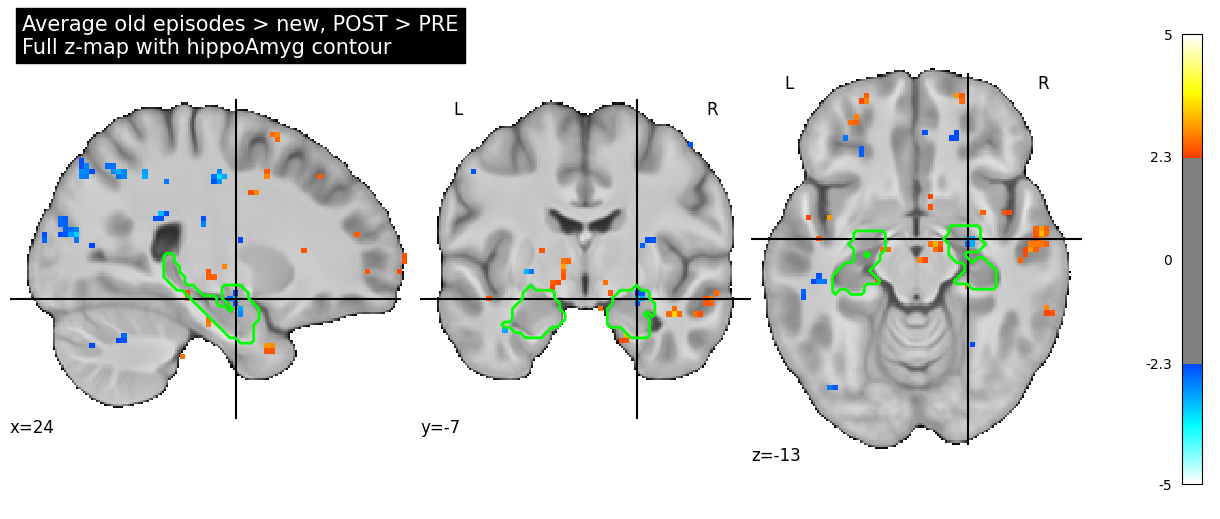

Contrast: episode_old_gt_new_post_gt_pre
Title: Average old episodes > new, POST > PRE
Saved ROI-masked interactive HTML: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/interactive_views/roi_masked_views/episode_old_gt_new_post_gt_pre_hippoAmyg_masked_interactive.html
Saved contour overlay PNG: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/figures/roi_mask_overlays/episode_old_gt_new_post_gt_pre_hippoAmyg_contour_overlay.png
ROI stats: {'roi_voxels': 1544, 'positive_suprathreshold_voxels_inside_roi': 7, 'negative_suprathreshold_voxels_inside_roi': 13, 'max_z_inside_roi': 2.9140052795410156, 'min_z_inside_roi': -3.338228464126587, 'contrast': 'episode_old_gt_new_post_gt_pre', 'display_title': 'Average old episodes > new, POST > PRE', 'z_map_path': '/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_

/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


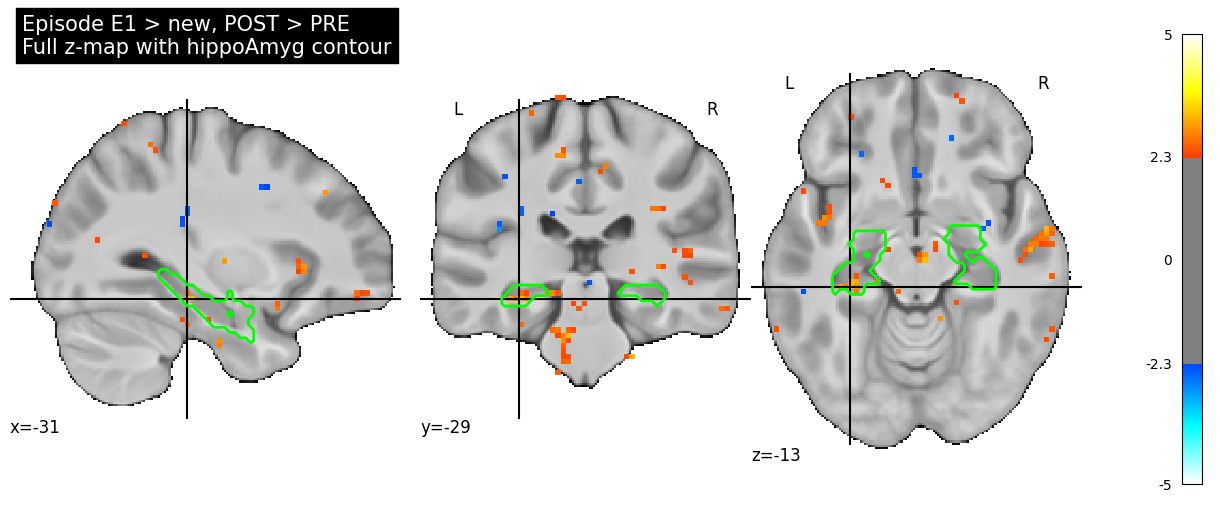

Contrast: e1_gt_new_post_gt_pre
Title: Episode E1 > new, POST > PRE
Saved ROI-masked interactive HTML: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/interactive_views/roi_masked_views/e1_gt_new_post_gt_pre_hippoAmyg_masked_interactive.html
Saved contour overlay PNG: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/figures/roi_mask_overlays/e1_gt_new_post_gt_pre_hippoAmyg_contour_overlay.png
ROI stats: {'roi_voxels': 1544, 'positive_suprathreshold_voxels_inside_roi': 30, 'negative_suprathreshold_voxels_inside_roi': 12, 'max_z_inside_roi': 3.208641767501831, 'min_z_inside_roi': -3.090221405029297, 'contrast': 'e1_gt_new_post_gt_pre', 'display_title': 'Episode E1 > new, POST > PRE', 'z_map_path': '/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoo

/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


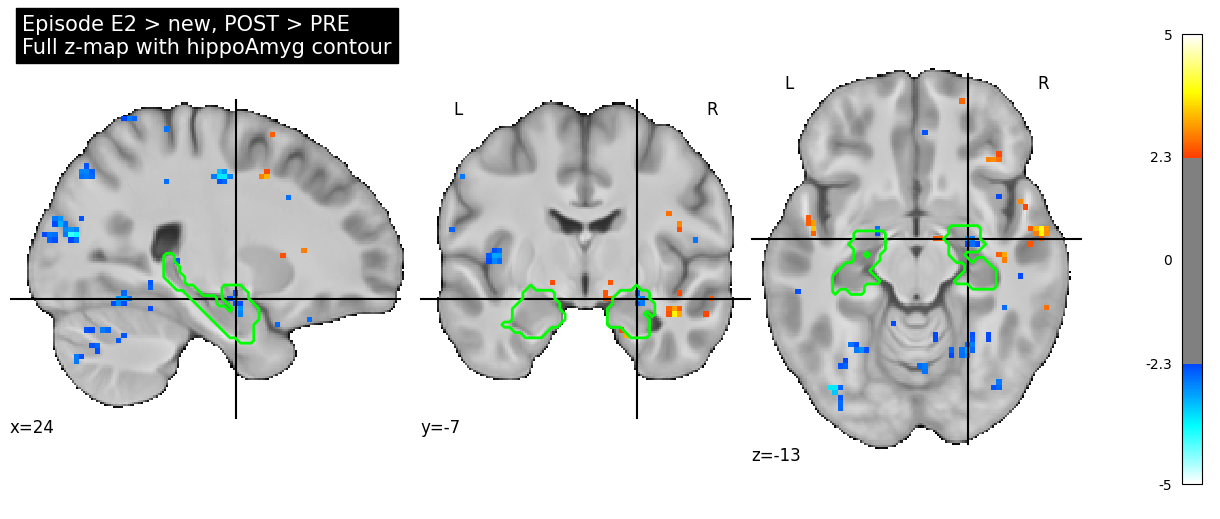

Contrast: e2_gt_new_post_gt_pre
Title: Episode E2 > new, POST > PRE
Saved ROI-masked interactive HTML: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/interactive_views/roi_masked_views/e2_gt_new_post_gt_pre_hippoAmyg_masked_interactive.html
Saved contour overlay PNG: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/figures/roi_mask_overlays/e2_gt_new_post_gt_pre_hippoAmyg_contour_overlay.png
ROI stats: {'roi_voxels': 1544, 'positive_suprathreshold_voxels_inside_roi': 4, 'negative_suprathreshold_voxels_inside_roi': 17, 'max_z_inside_roi': 2.812227249145508, 'min_z_inside_roi': -3.1802096366882324, 'contrast': 'e2_gt_new_post_gt_pre', 'display_title': 'Episode E2 > new, POST > PRE', 'z_map_path': '/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoo

/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


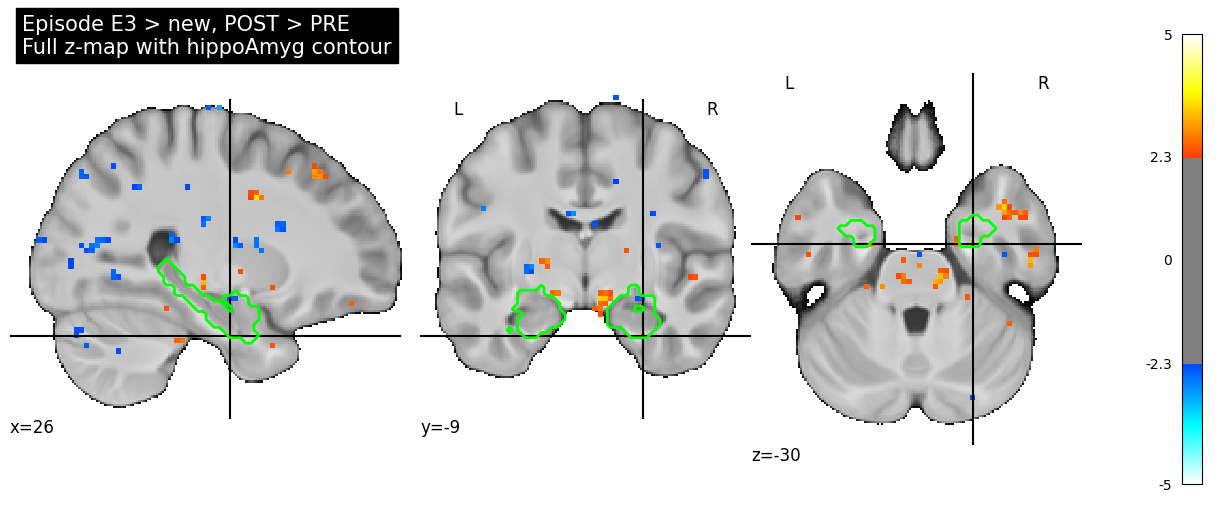

Contrast: e3_gt_new_post_gt_pre
Title: Episode E3 > new, POST > PRE
Saved ROI-masked interactive HTML: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/interactive_views/roi_masked_views/e3_gt_new_post_gt_pre_hippoAmyg_masked_interactive.html
Saved contour overlay PNG: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/figures/roi_mask_overlays/e3_gt_new_post_gt_pre_hippoAmyg_contour_overlay.png
ROI stats: {'roi_voxels': 1544, 'positive_suprathreshold_voxels_inside_roi': 11, 'negative_suprathreshold_voxels_inside_roi': 7, 'max_z_inside_roi': 3.1845922470092773, 'min_z_inside_roi': -3.017793655395508, 'contrast': 'e3_gt_new_post_gt_pre', 'display_title': 'Episode E3 > new, POST > PRE', 'z_map_path': '/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoo

/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


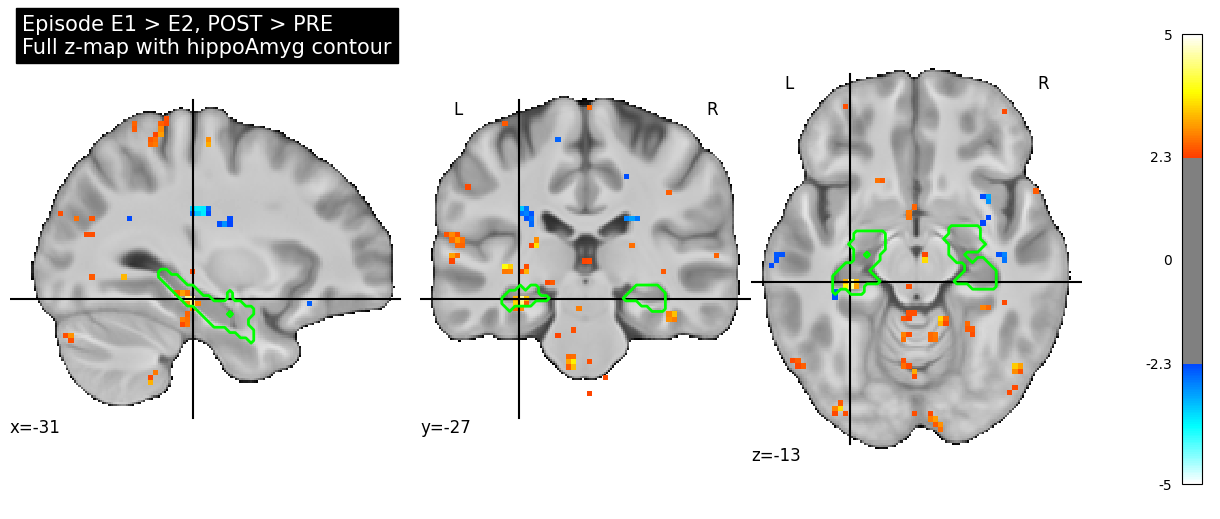

Contrast: e1_gt_e2_post_gt_pre
Title: Episode E1 > E2, POST > PRE
Saved ROI-masked interactive HTML: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/interactive_views/roi_masked_views/e1_gt_e2_post_gt_pre_hippoAmyg_masked_interactive.html
Saved contour overlay PNG: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/figures/roi_mask_overlays/e1_gt_e2_post_gt_pre_hippoAmyg_contour_overlay.png
ROI stats: {'roi_voxels': 1544, 'positive_suprathreshold_voxels_inside_roi': 22, 'negative_suprathreshold_voxels_inside_roi': 3, 'max_z_inside_roi': 4.549766540527344, 'min_z_inside_roi': -2.5293614864349365, 'contrast': 'e1_gt_e2_post_gt_pre', 'display_title': 'Episode E1 > E2, POST > PRE', 'z_map_path': '/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5m

/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


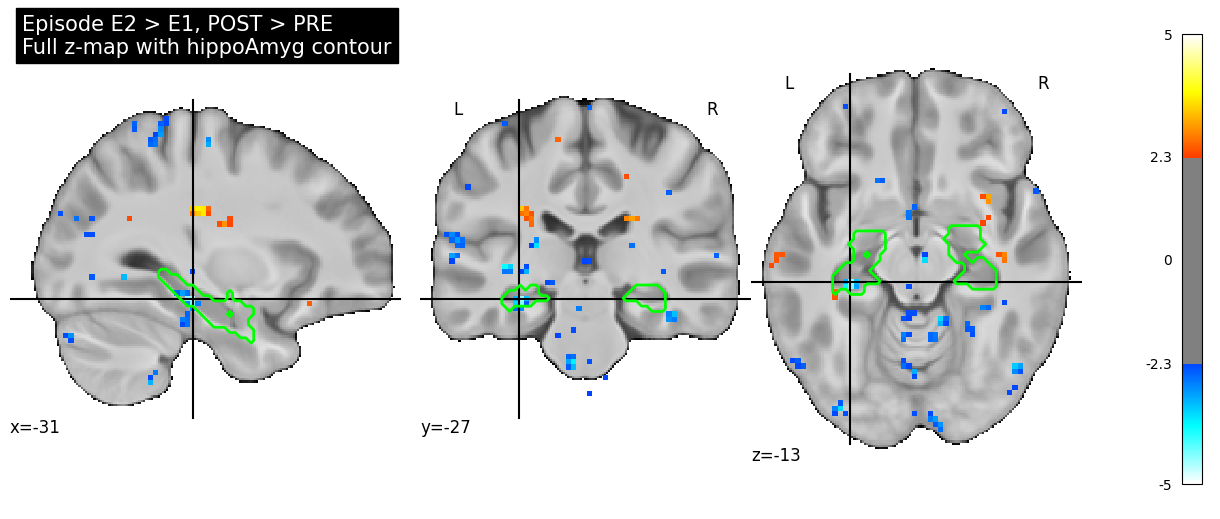

Contrast: e2_gt_e1_post_gt_pre
Title: Episode E2 > E1, POST > PRE
Saved ROI-masked interactive HTML: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/interactive_views/roi_masked_views/e2_gt_e1_post_gt_pre_hippoAmyg_masked_interactive.html
Saved contour overlay PNG: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/figures/roi_mask_overlays/e2_gt_e1_post_gt_pre_hippoAmyg_contour_overlay.png
ROI stats: {'roi_voxels': 1544, 'positive_suprathreshold_voxels_inside_roi': 3, 'negative_suprathreshold_voxels_inside_roi': 22, 'max_z_inside_roi': 2.5293614864349365, 'min_z_inside_roi': -4.549766540527344, 'contrast': 'e2_gt_e1_post_gt_pre', 'display_title': 'Episode E2 > E1, POST > PRE', 'z_map_path': '/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5m

/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


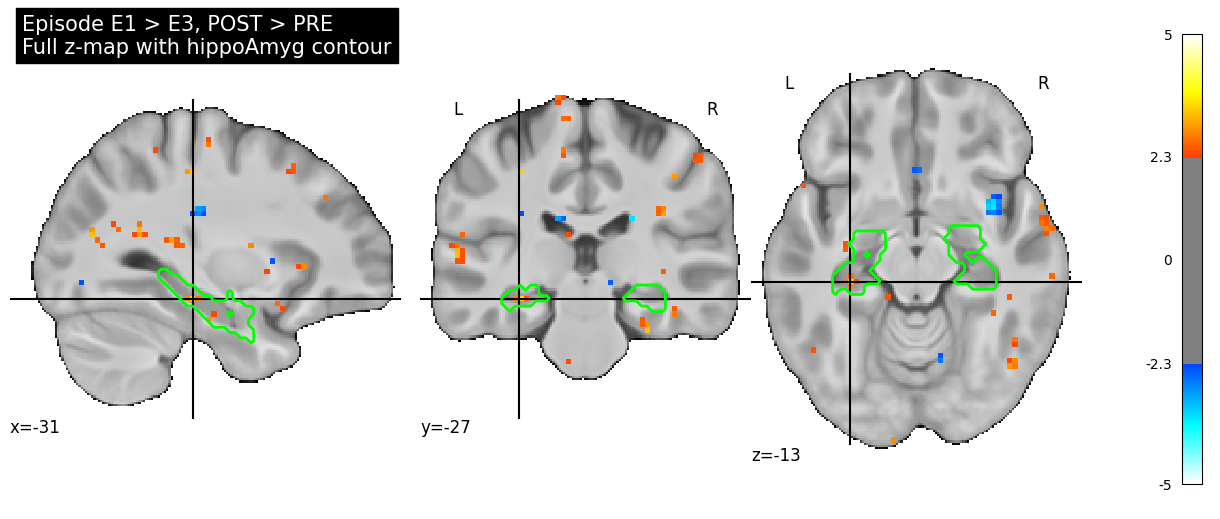

Contrast: e1_gt_e3_post_gt_pre
Title: Episode E1 > E3, POST > PRE
Saved ROI-masked interactive HTML: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/interactive_views/roi_masked_views/e1_gt_e3_post_gt_pre_hippoAmyg_masked_interactive.html
Saved contour overlay PNG: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/figures/roi_mask_overlays/e1_gt_e3_post_gt_pre_hippoAmyg_contour_overlay.png
ROI stats: {'roi_voxels': 1544, 'positive_suprathreshold_voxels_inside_roi': 22, 'negative_suprathreshold_voxels_inside_roi': 6, 'max_z_inside_roi': 3.5062479972839355, 'min_z_inside_roi': -3.0637428760528564, 'contrast': 'e1_gt_e3_post_gt_pre', 'display_title': 'Episode E1 > E3, POST > PRE', 'z_map_path': '/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5

/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


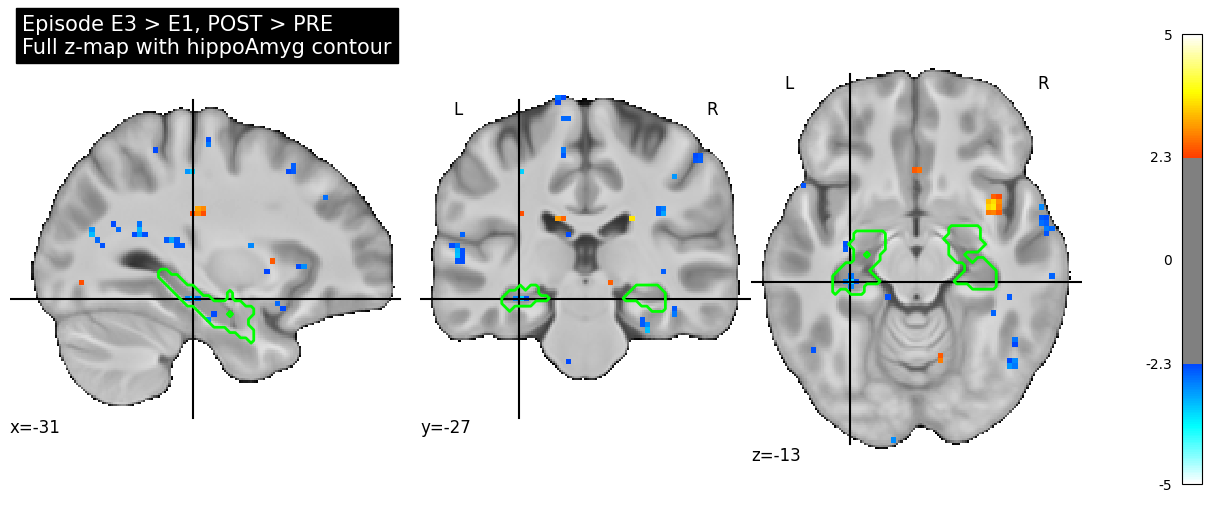

Contrast: e3_gt_e1_post_gt_pre
Title: Episode E3 > E1, POST > PRE
Saved ROI-masked interactive HTML: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/interactive_views/roi_masked_views/e3_gt_e1_post_gt_pre_hippoAmyg_masked_interactive.html
Saved contour overlay PNG: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/figures/roi_mask_overlays/e3_gt_e1_post_gt_pre_hippoAmyg_contour_overlay.png
ROI stats: {'roi_voxels': 1544, 'positive_suprathreshold_voxels_inside_roi': 6, 'negative_suprathreshold_voxels_inside_roi': 22, 'max_z_inside_roi': 3.0637428760528564, 'min_z_inside_roi': -3.5062479972839355, 'contrast': 'e3_gt_e1_post_gt_pre', 'display_title': 'Episode E3 > E1, POST > PRE', 'z_map_path': '/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5

/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


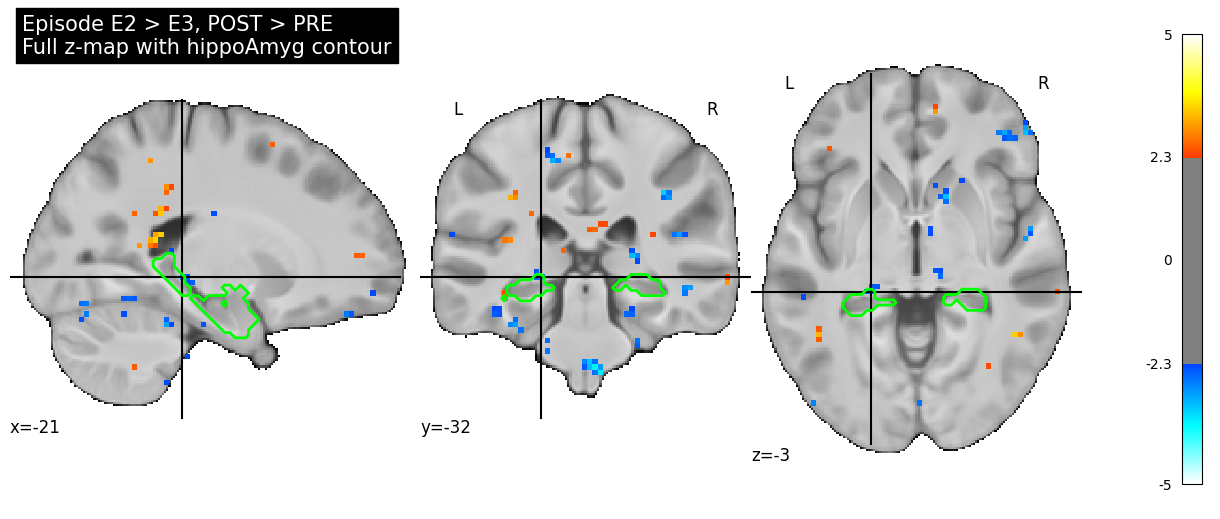

Contrast: e2_gt_e3_post_gt_pre
Title: Episode E2 > E3, POST > PRE
Saved ROI-masked interactive HTML: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/interactive_views/roi_masked_views/e2_gt_e3_post_gt_pre_hippoAmyg_masked_interactive.html
Saved contour overlay PNG: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/figures/roi_mask_overlays/e2_gt_e3_post_gt_pre_hippoAmyg_contour_overlay.png
ROI stats: {'roi_voxels': 1544, 'positive_suprathreshold_voxels_inside_roi': 6, 'negative_suprathreshold_voxels_inside_roi': 6, 'max_z_inside_roi': 2.7916460037231445, 'min_z_inside_roi': -2.8641533851623535, 'contrast': 'e2_gt_e3_post_gt_pre', 'display_title': 'Episode E2 > E3, POST > PRE', 'z_map_path': '/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5m

/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


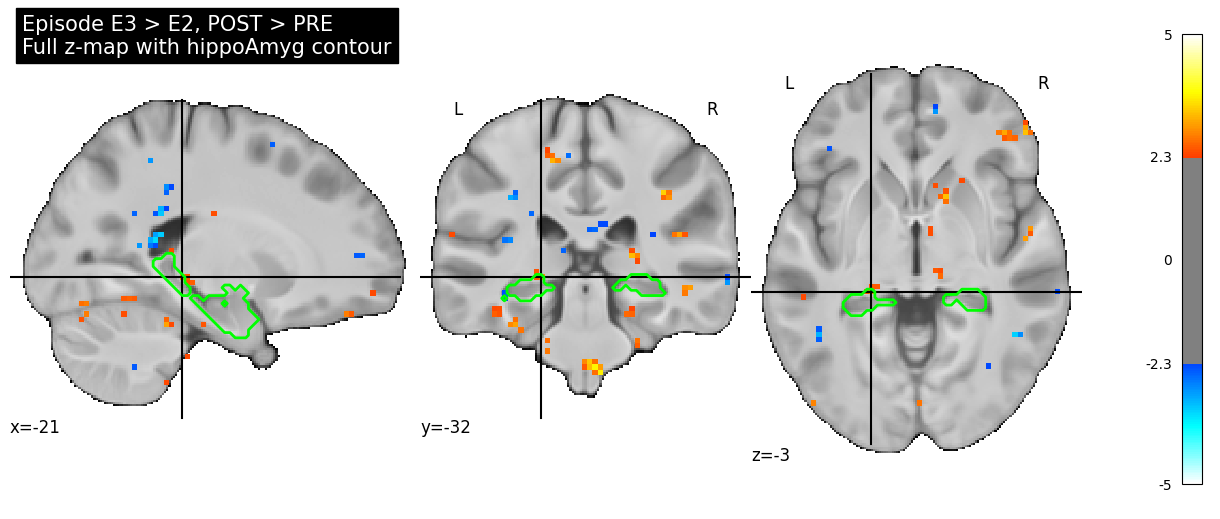

Contrast: e3_gt_e2_post_gt_pre
Title: Episode E3 > E2, POST > PRE
Saved ROI-masked interactive HTML: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/interactive_views/roi_masked_views/e3_gt_e2_post_gt_pre_hippoAmyg_masked_interactive.html
Saved contour overlay PNG: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/figures/roi_mask_overlays/e3_gt_e2_post_gt_pre_hippoAmyg_contour_overlay.png
ROI stats: {'roi_voxels': 1544, 'positive_suprathreshold_voxels_inside_roi': 6, 'negative_suprathreshold_voxels_inside_roi': 6, 'max_z_inside_roi': 2.8641533851623535, 'min_z_inside_roi': -2.7916460037231445, 'contrast': 'e3_gt_e2_post_gt_pre', 'display_title': 'Episode E3 > E2, POST > PRE', 'z_map_path': '/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5m

,roi_voxels,positive_suprathreshold_voxels_inside_roi,negative_suprathreshold_voxels_inside_roi,max_z_inside_roi,min_z_inside_roi,contrast,display_title,z_map_path,roi_masked_z_map_path
0,1544,7,13,2.914005,-3.338228,episode_old_gt_new_post_gt_pre,"Average old episodes > new, POST > PRE",/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_episode_old_...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_overlap/episode_old_gt_new_post_gt_pre_hip...
1,1544,30,12,3.208642,-3.090221,e1_gt_new_post_gt_pre,"Episode E1 > new, POST > PRE",/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e1_gt_new_po...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_overlap/e1_gt_new_post_gt_pre_hippoAmyg_ma...
2,1544,4,17,2.812227,-3.180210,e2_gt_new_post_gt_pre,"Episode E2 > new, POST > PRE",/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e2_gt_new_po...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_overlap/e2_gt_new_post_gt_pre_hippoAmyg_ma...
3,1544,11,7,3.184592,-3.017794,e3_gt_new_post_gt_pre,"Episode E3 > new, POST > PRE",/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e3_gt_new_po...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_overlap/e3_gt_new_post_gt_pre_hippoAmyg_ma...
4,1544,22,3,4.549767,-2.529361,e1_gt_e2_post_gt_pre,"Episode E1 > E2, POST > PRE",/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e1_gt_e2_pos...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_overlap/e1_gt_e2_post_gt_pre_hippoAmyg_mas...
5,1544,3,22,2.529361,-4.549767,e2_gt_e1_post_gt_pre,"Episode E2 > E1, POST > PRE",/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e2_gt_e1_pos...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_overlap/e2_gt_e1_post_gt_pre_hippoAmyg_mas...
6,1544,22,6,3.506248,-3.063743,e1_gt_e3_post_gt_pre,"Episode E1 > E3, POST > PRE",/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e1_gt_e3_pos...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_overlap/e1_gt_e3_post_gt_pre_hippoAmyg_mas...
7,1544,6,22,3.063743,-3.506248,e3_gt_e1_post_gt_pre,"Episode E3 > E1, POST > PRE",/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e3_gt_e1_pos...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_overlap/e3_gt_e1_post_gt_pre_hippoAmyg_mas...
8,1544,6,6,2.791646,-2.864153,e2_gt_e3_post_gt_pre,"Episode E2 > E3, POST > PRE",/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e2_gt

Saved ROI overlap table:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_overlap/pre_post_episode_e1_e2_e3_control_glm_hippoAmyg_overlap_stats_zgt2.33.csv


In [15]:
# ============================================================
# ROI visualization: hippocampus/amygdala mask overlays
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import nibabel as nib
from nilearn.image import load_img, resample_to_img, math_img, mean_img
from nilearn.plotting import plot_stat_map, view_img

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

ROI_NAME = "hippoAmyg"
ROI_ROOT = paths.data_dir / "rois" / "hippoAmyg_02022024"

ROI_THRESHOLD = 0.50      # group consensus mask: voxel must be in >=50% of subjects
STAT_THRESHOLD = 2.33     # exploratory display threshold
VMAX = 5.0

roi_fig_dir = dirs["figures"] / "roi_mask_overlays"
roi_fig_dir.mkdir(parents=True, exist_ok=True)

roi_html_dir = dirs["interactive"] / "roi_masked_views"
roi_html_dir.mkdir(parents=True, exist_ok=True)

roi_table_dir = dirs["tables"] / "roi_overlap"
roi_table_dir.mkdir(parents=True, exist_ok=True)

print("ROI root:", ROI_ROOT)
print("Saving ROI figures to:", roi_fig_dir)
print("Saving ROI interactive views to:", roi_html_dir)

# ------------------------------------------------------------
# Build group consensus bilateral hippoAmyg mask in MNI space
# ------------------------------------------------------------

roi_imgs = []
missing_roi_rows = []

for subject in subjects:
    left_mask = (
        ROI_ROOT
        / subject
        / "ses-01"
        / "anat"
        / f"{subject}_ses-01_space-MNI152NLin2009cAsym_hemi-L_label-hippoAmyg.nii.gz"
    )

    right_mask = (
        ROI_ROOT
        / subject
        / "ses-01"
        / "anat"
        / f"{subject}_ses-01_space-MNI152NLin2009cAsym_hemi-R_label-hippoAmyg.nii.gz"
    )

    if left_mask.exists():
        roi_imgs.append(load_img(str(left_mask)))
    else:
        missing_roi_rows.append({
            "subject": subject,
            "hemi": "L",
            "missing_mask_path": str(left_mask),
        })

    if right_mask.exists():
        roi_imgs.append(load_img(str(right_mask)))
    else:
        missing_roi_rows.append({
            "subject": subject,
            "hemi": "R",
            "missing_mask_path": str(right_mask),
        })

print(f"Loaded {len(roi_imgs)} unilateral ROI masks.")

if missing_roi_rows:
    missing_roi_table = pd.DataFrame(missing_roi_rows)
    display(missing_roi_table)

assert len(roi_imgs) > 0, "No ROI masks found. Check ROI_ROOT."

# Average all unilateral masks, then threshold to create group consensus mask
roi_mean_img = mean_img(roi_imgs)

roi_group_mask_img = math_img(
    f"img >= {ROI_THRESHOLD}",
    img=roi_mean_img,
)

roi_group_mask_path = (
    roi_table_dir
    / f"group_consensus_{ROI_NAME}_threshold-{ROI_THRESHOLD:.2f}_mask.nii.gz"
)

roi_group_mask_img.to_filename(str(roi_group_mask_path))

print("Saved group consensus ROI mask:")
print(roi_group_mask_path)

# ------------------------------------------------------------
# Helper: compute simple ROI overlap statistics
# ------------------------------------------------------------

def compute_roi_overlap_stats(z_img, roi_mask_img, threshold=2.33):
    """Compute how many suprathreshold voxels fall inside ROI."""

    roi_resampled = resample_to_img(
        roi_mask_img,
        z_img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )

    z_data = z_img.get_fdata()
    roi_data = roi_resampled.get_fdata() > 0

    pos_supra = z_data > threshold
    neg_supra = z_data < -threshold

    pos_inside = pos_supra & roi_data
    neg_inside = neg_supra & roi_data

    if roi_data.sum() == 0:
        max_z_inside = np.nan
        min_z_inside = np.nan
    else:
        max_z_inside = float(np.nanmax(np.where(roi_data, z_data, np.nan)))
        min_z_inside = float(np.nanmin(np.where(roi_data, z_data, np.nan)))

    return {
        "roi_voxels": int(roi_data.sum()),
        "positive_suprathreshold_voxels_inside_roi": int(pos_inside.sum()),
        "negative_suprathreshold_voxels_inside_roi": int(neg_inside.sum()),
        "max_z_inside_roi": max_z_inside,
        "min_z_inside_roi": min_z_inside,
    }


# ------------------------------------------------------------
# Choose contrasts to visualize
# ------------------------------------------------------------

available_contrasts = second_level_table["contrast"].tolist()

print("Available contrasts:")
for c in available_contrasts:
    print(" -", c)

# All main episode-related POST > PRE contrasts:
# - old/new episode controls
# - pairwise episode contrasts
contrasts_to_visualize = [
    "episode_old_gt_new_post_gt_pre",
    "e1_gt_new_post_gt_pre",
    "e2_gt_new_post_gt_pre",
    "e3_gt_new_post_gt_pre",
    "e1_gt_e2_post_gt_pre",
    "e2_gt_e1_post_gt_pre",
    "e1_gt_e3_post_gt_pre",
    "e3_gt_e1_post_gt_pre",
    "e2_gt_e3_post_gt_pre",
    "e3_gt_e2_post_gt_pre",
]

# Keep only contrasts that actually exist in the second-level table
available_contrast_set = set(available_contrasts)

contrasts_to_visualize = [
    c for c in contrasts_to_visualize
    if c in available_contrast_set
]

print("\nContrasts to visualize:")
for c in contrasts_to_visualize:
    print(" -", c)

missing_requested = [
    c for c in [
        "episode_old_gt_new_post_gt_pre",
        "e1_gt_new_post_gt_pre",
        "e2_gt_new_post_gt_pre",
        "e3_gt_new_post_gt_pre",
        "e1_gt_e2_post_gt_pre",
        "e2_gt_e1_post_gt_pre",
        "e1_gt_e3_post_gt_pre",
        "e3_gt_e1_post_gt_pre",
        "e2_gt_e3_post_gt_pre",
        "e3_gt_e2_post_gt_pre",
    ]
    if c not in available_contrast_set
]

if missing_requested:
    print("\nRequested contrasts missing from second_level_table:")
    for c in missing_requested:
        print(" -", c)

assert len(contrasts_to_visualize) > 0, (
    "No requested episode POST > PRE contrasts found in second_level_table."
)

plot_title_map = {
    "episode_old_gt_new_post_gt_pre": "Average old episodes > new, POST > PRE",
    "e1_gt_new_post_gt_pre": "Episode E1 > new, POST > PRE",
    "e2_gt_new_post_gt_pre": "Episode E2 > new, POST > PRE",
    "e3_gt_new_post_gt_pre": "Episode E3 > new, POST > PRE",
    "e1_gt_e2_post_gt_pre": "Episode E1 > E2, POST > PRE",
    "e2_gt_e1_post_gt_pre": "Episode E2 > E1, POST > PRE",
    "e1_gt_e3_post_gt_pre": "Episode E1 > E3, POST > PRE",
    "e3_gt_e1_post_gt_pre": "Episode E3 > E1, POST > PRE",
    "e2_gt_e3_post_gt_pre": "Episode E2 > E3, POST > PRE",
    "e3_gt_e2_post_gt_pre": "Episode E3 > E2, POST > PRE",
}

# ------------------------------------------------------------
# Generate ROI-masked HTML views and contour PNGs
# ------------------------------------------------------------

roi_overlap_rows = []

for contrast_name in contrasts_to_visualize:
    row = second_level_table.loc[
        second_level_table["contrast"] == contrast_name
    ].iloc[0]

    z_map_path = Path(row["z_map_path"])
    z_img = load_img(str(z_map_path))

    # Resample ROI mask to z-map space
    roi_resampled = resample_to_img(
        roi_group_mask_img,
        z_img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )

    # ROI-masked z-map: only activity inside hippocampus/amygdala consensus mask
    z_roi_img = math_img(
        "z * (roi > 0)",
        z=z_img,
        roi=roi_resampled,
    )

    z_roi_path = (
        roi_table_dir
        / f"{contrast_name}_{ROI_NAME}_masked_zmap.nii.gz"
    )

    z_roi_img.to_filename(str(z_roi_path))

    # Compute ROI overlap stats
    stats = compute_roi_overlap_stats(
        z_img=z_img,
        roi_mask_img=roi_group_mask_img,
        threshold=STAT_THRESHOLD,
    )

    stats["contrast"] = contrast_name
    stats["display_title"] = plot_title_map.get(contrast_name, contrast_name)
    stats["z_map_path"] = str(z_map_path)
    stats["roi_masked_z_map_path"] = str(z_roi_path)
    roi_overlap_rows.append(stats)

    # --------------------------------------------------------
    # Interactive HTML view: ROI-masked z-map
    # --------------------------------------------------------

    html_path = (
        roi_html_dir
        / f"{contrast_name}_{ROI_NAME}_masked_interactive.html"
    )

    view = view_img(
        z_roi_img,
        bg_img=mean_t1w_img if USE_MEAN_T1W_BACKGROUND else None,
        threshold=STAT_THRESHOLD,
        vmax=VMAX,
        cmap="cold_hot",
        title=(
            f"{plot_title_map.get(contrast_name, contrast_name)} — "
            f"activity inside {ROI_NAME} ROI"
        ),
    )

    view.save_as_html(str(html_path))

    # --------------------------------------------------------
    # Static contour plot: full z-map + ROI contour
    # --------------------------------------------------------

    z_roi_data = z_roi_img.get_fdata()

    if np.any(np.abs(z_roi_data) > STAT_THRESHOLD):
        max_idx = np.unravel_index(
            np.nanargmax(np.abs(z_roi_data)),
            z_roi_data.shape,
        )
        cut_coords = nib.affines.apply_affine(
            z_roi_img.affine,
            max_idx,
        )
    else:
        # fallback: center roughly on left hippocampus
        cut_coords = (-28, -24, -14)

    fig = plt.figure(figsize=(12, 5))

    display_obj = plot_stat_map(
        z_img,
        bg_img=mean_t1w_img if USE_MEAN_T1W_BACKGROUND else None,
        threshold=STAT_THRESHOLD,
        vmax=VMAX,
        cmap="cold_hot",
        display_mode="ortho",
        cut_coords=cut_coords,
        black_bg=False,
        title=(
            f"{plot_title_map.get(contrast_name, contrast_name)}\n"
            f"Full z-map with {ROI_NAME} contour"
        ),
        figure=fig,
        dim=-0.2,
    )

    display_obj.add_contours(
        roi_resampled,
        levels=[0.5],
        colors="lime",
        linewidths=2.0,
    )

    contour_fig_path = (
        roi_fig_dir
        / f"{contrast_name}_{ROI_NAME}_contour_overlay.png"
    )

    fig.savefig(contour_fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("=" * 80)
    print("Contrast:", contrast_name)
    print("Title:", plot_title_map.get(contrast_name, contrast_name))
    print("Saved ROI-masked interactive HTML:", html_path)
    print("Saved contour overlay PNG:", contour_fig_path)
    print("ROI stats:", stats)

# ------------------------------------------------------------
# Save ROI overlap table
# ------------------------------------------------------------

roi_overlap_table = pd.DataFrame(roi_overlap_rows)

roi_overlap_table_path = (
    roi_table_dir
    / f"{ANALYSIS_NAME}_{ROI_NAME}_overlap_stats_zgt{STAT_THRESHOLD:.2f}.csv"
)

roi_overlap_table.to_csv(roi_overlap_table_path, index=False)

display(roi_overlap_table)

print("Saved ROI overlap table:")
print(roi_overlap_table_path)

## Plot PRE/POST episode-control contrasts on the common mean T1w background

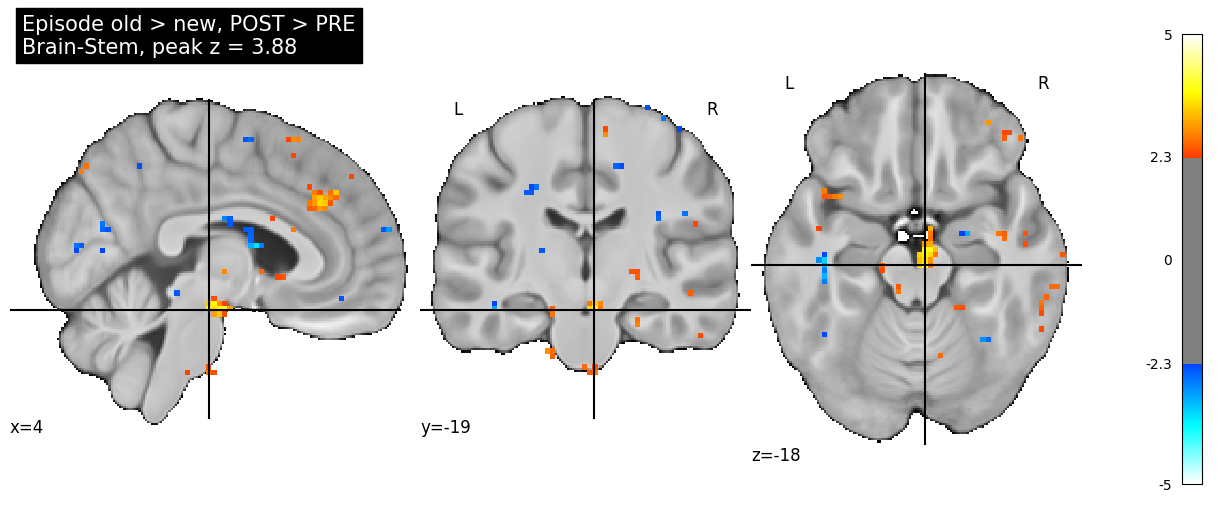

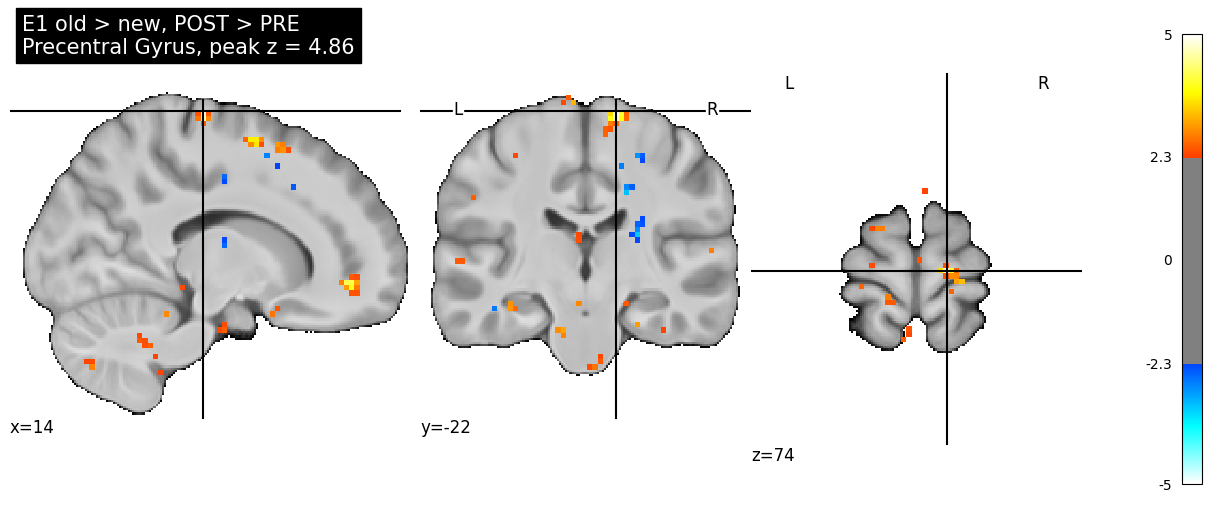

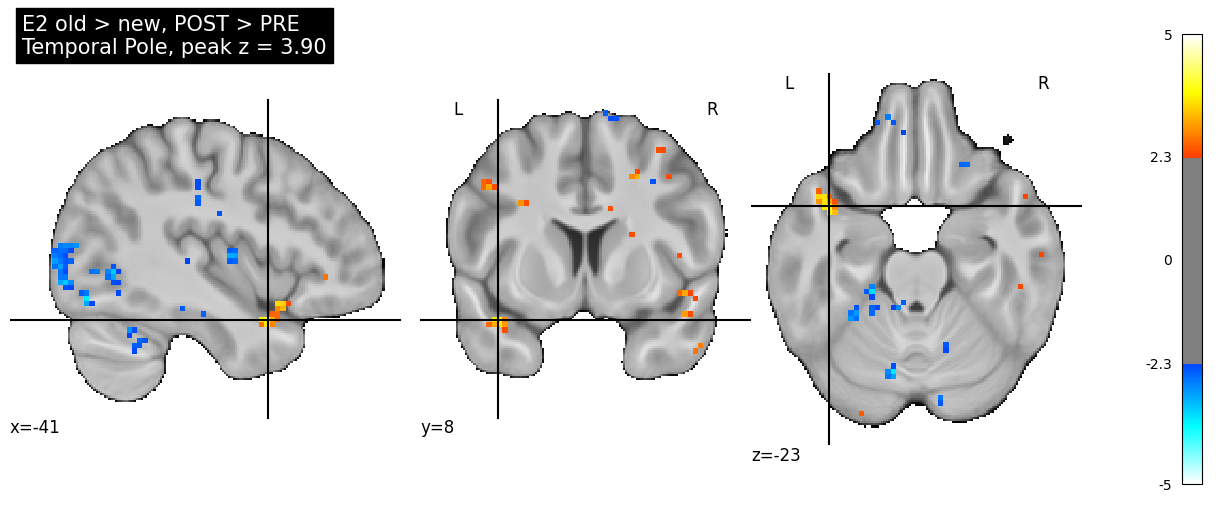

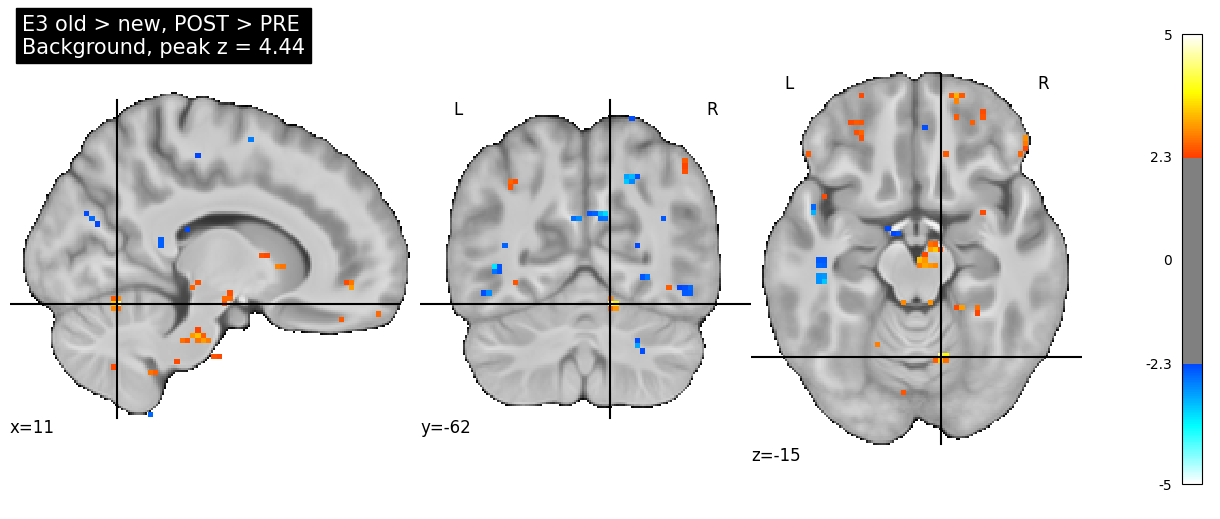

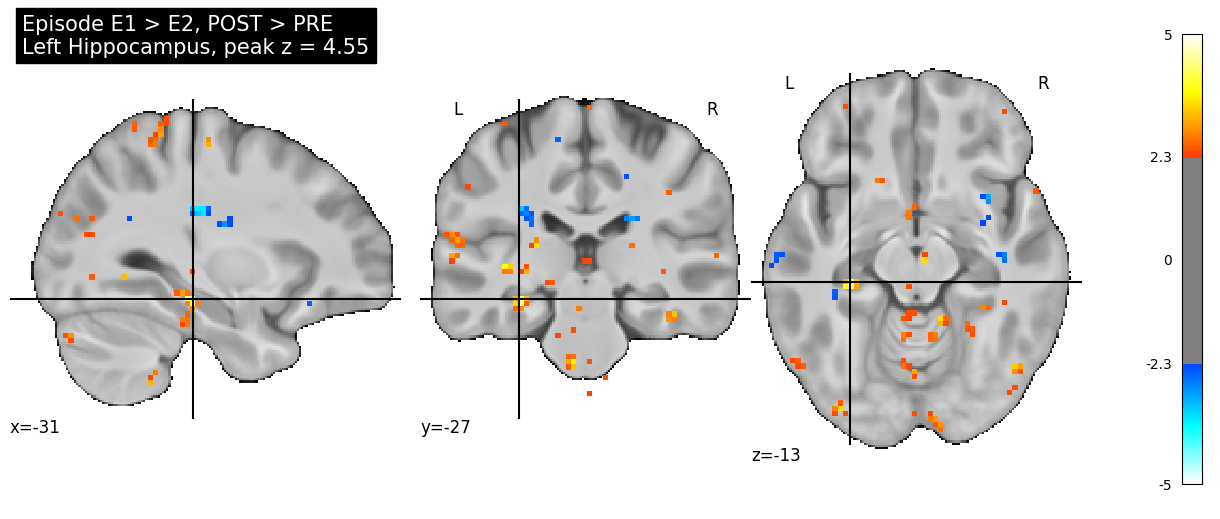

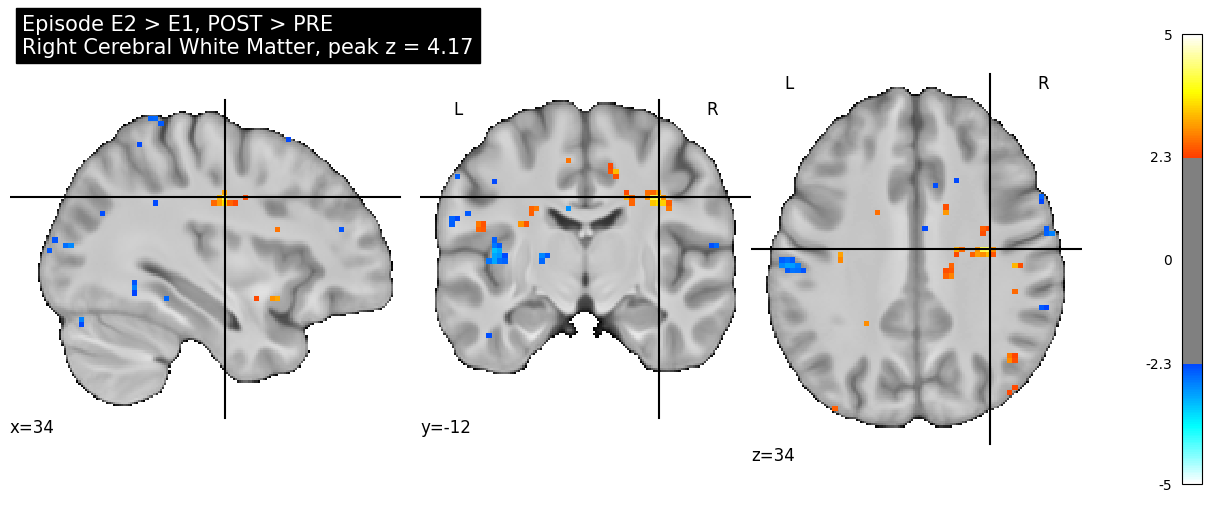

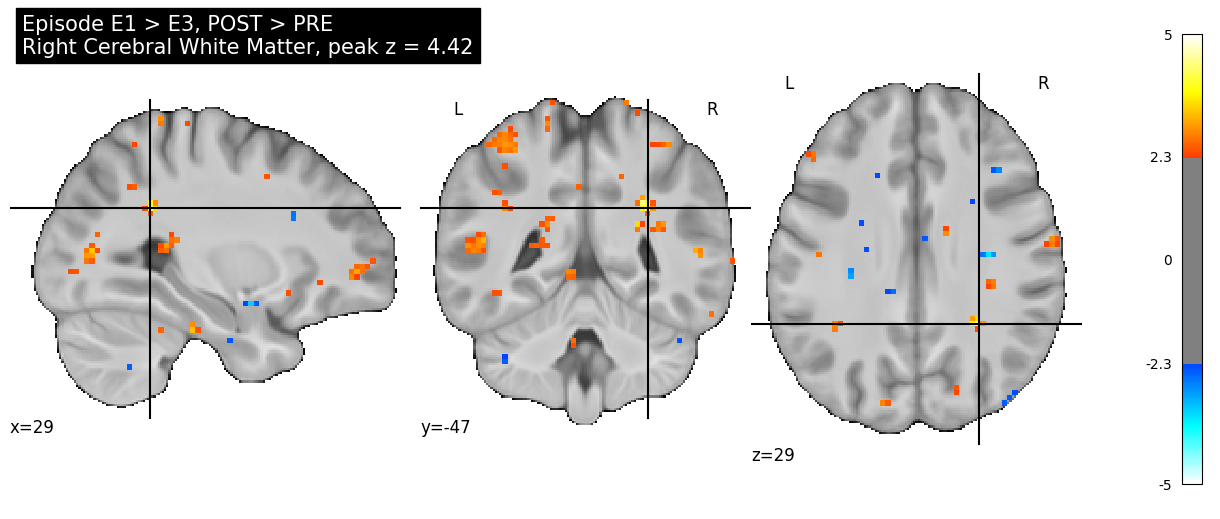

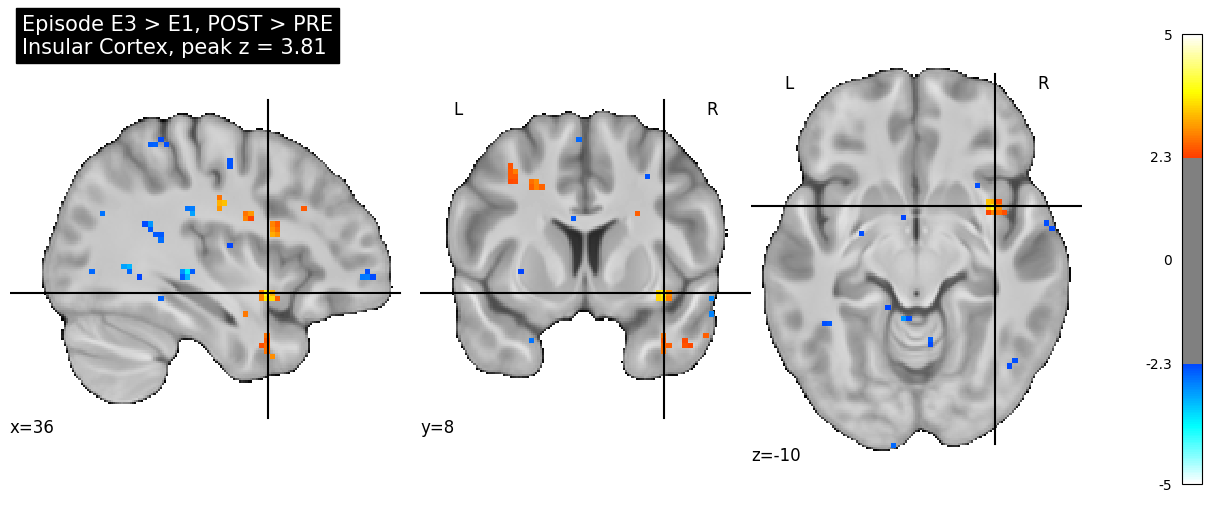

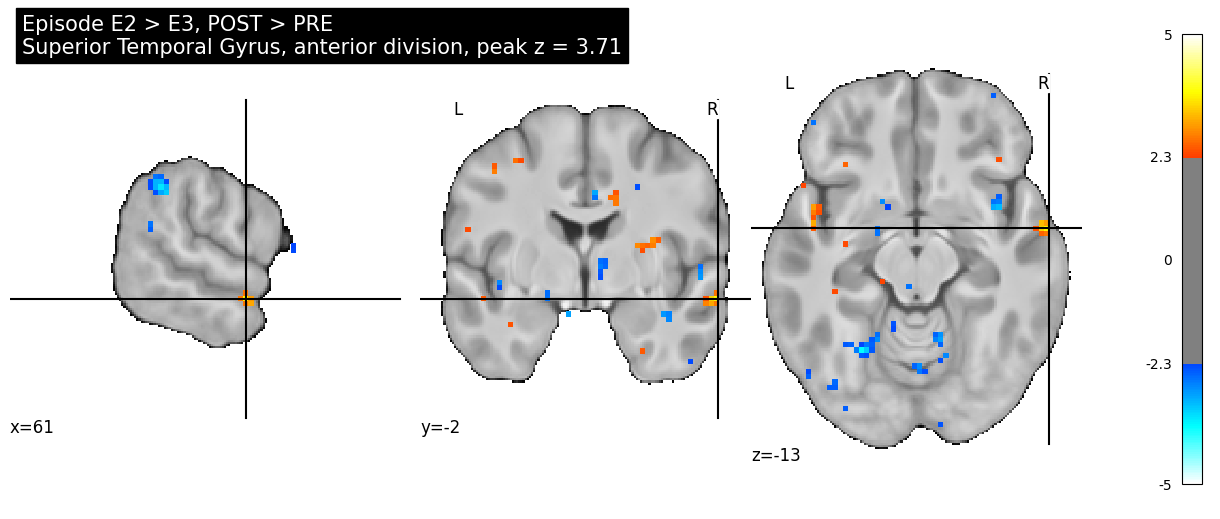

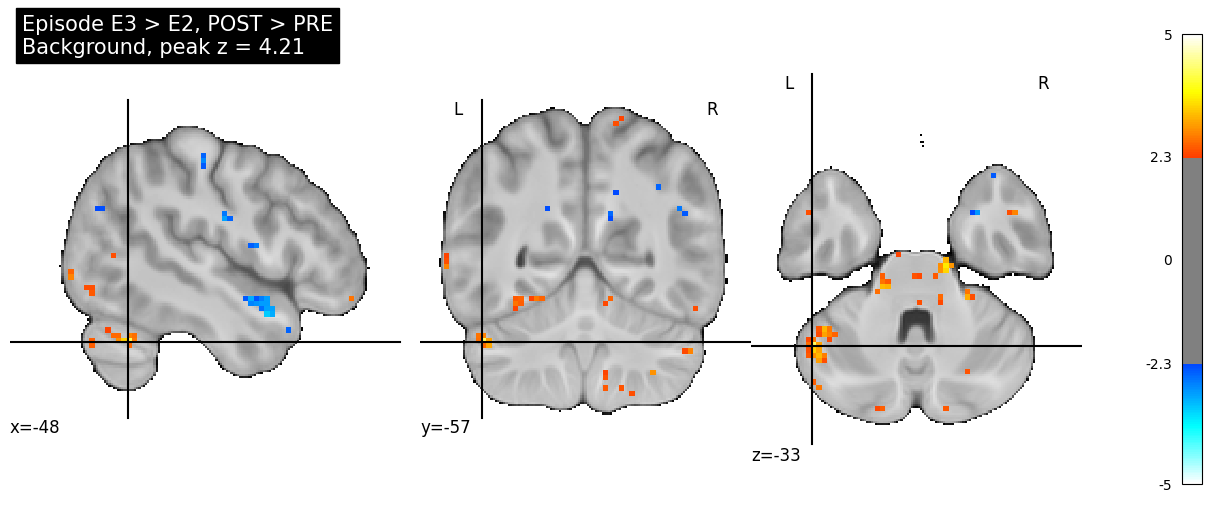

,contrast,figure_path,x,y,z,peak_z,atlas_label,background
0,episode_old_gt_new_post_gt_pre,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/figures/pre_post_episode_e1_e2_e3_control_glm_episode...,4.0,-19.5,-18.0,3.882043,Brain-Stem,mean_T1w
1,e1_gt_new_post_gt_pre,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/figures/pre_post_episode_e1_e2_e3_control_glm_e1_gt_n...,14.0,-22.0,74.5,4.861647,Precentral Gyrus,mean_T1w
2,e2_gt_new_post_gt_pre,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/figures/pre_post_episode_e1_e2_e3_control_glm_e2_gt_n...,-41.0,8.0,-23.0,3.896738,Temporal Pole,mean_T1w
3,e3_gt_new_post_gt_pre,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/figures/pre_post_episode_e1_e2_e3_control_glm_e3_gt_n...,11.5,-62.0,-15.5,4.438114,Background,mean_T1w
4,e1_gt_e2_post_gt_pre,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/figures/pre_post_episode_e1_e2_e3_control_glm_e1_gt_e...,-31.0,-27.0,-13.0,4.549767,Left Hippocampus,mean_T1w
5,e2_gt_e1_post_gt_pre,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/figures/pre_post_episode_e1_e2_e3_control_glm_e2_gt_e...,34.0,-12.0,34.5,4.171285,Right Cerebral White Matter,mean_T1w
6,e1_gt_e3_post_gt_pre,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/figures/pre_post_episode_e1_e2_e3_control_glm_e1_gt_e...,29.0,-47.0,29.5,4.421388,Right Cerebral White Matter,mean_T1w
7,e3_gt_e1_post_gt_pre,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/figures/pre_post_episode_e1_e2_e3_control_glm_e3_gt_e...,36.5,8.0,-10.5,3.810886,Insular Cortex,mean_T1w
8,e2_gt_e3_post_gt_pre,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/figures/pre_post_episode_e1_e2_e3_control_glm_e2_gt_e...,61.5,-2.0,-13.0,3.714171,"Superior Temporal Gyrus, anterior division",mean_T1w
9,e3_gt_e2_post_gt_pre,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/figures/pre_post_episode_e1_e2_e3_control_glm_e3_gt_e...,-48.5,-57.0,-33.0,4.209072,Background,mean_T1w


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/pre_post_episode_e1_e2_e3_control_glm_figure_index_smoothed5mm.csv


In [16]:
# ============================================================
# 11. Plot PRE/POST episode-control contrasts on mean T1w background
# ============================================================

main_contrasts = [
    "episode_old_gt_new_post_gt_pre",
    "e1_gt_new_post_gt_pre",
    "e2_gt_new_post_gt_pre",
    "e3_gt_new_post_gt_pre",
    "e1_gt_e2_post_gt_pre",
    "e2_gt_e1_post_gt_pre",
    "e1_gt_e3_post_gt_pre",
    "e3_gt_e1_post_gt_pre",
    "e2_gt_e3_post_gt_pre",
    "e3_gt_e2_post_gt_pre",
]

plot_title_map = {
    "episode_old_gt_new_post_gt_pre": "Episode old > new, POST > PRE",
    "e1_gt_new_post_gt_pre": "E1 old > new, POST > PRE",
    "e2_gt_new_post_gt_pre": "E2 old > new, POST > PRE",
    "e3_gt_new_post_gt_pre": "E3 old > new, POST > PRE",
    "e1_gt_e2_post_gt_pre": "Episode E1 > E2, POST > PRE",
    "e2_gt_e1_post_gt_pre": "Episode E2 > E1, POST > PRE",
    "e1_gt_e3_post_gt_pre": "Episode E1 > E3, POST > PRE",
    "e3_gt_e1_post_gt_pre": "Episode E3 > E1, POST > PRE",
    "e2_gt_e3_post_gt_pre": "Episode E2 > E3, POST > PRE",
    "e3_gt_e2_post_gt_pre": "Episode E3 > E2, POST > PRE",
}

plot_index_rows = []

for contrast_name in main_contrasts:
    subset = cluster_details_labeled.query(
        "contrast == @contrast_name and threshold_label == 'z_gt_2.33'"
    ).copy()

    if len(subset) == 0:
        print("No z > 2.33 clusters for", contrast_name)
        continue

    top = subset.sort_values("Peak Stat", ascending=False).iloc[0]
    z_map_path = second_level_table.set_index("contrast").loc[contrast_name, "z_map_path"]
    cut_coords = (float(top["X"]), float(top["Y"]), float(top["Z"]))

    atlas_label = top.get("harvard_oxford_cortical_label", "")
    if atlas_label == "Background":
        atlas_label = top.get("harvard_oxford_subcortical_label", "Background")

    title = (
        f"{plot_title_map[contrast_name]}\n"
        f"{atlas_label}, peak z = {float(top['Peak Stat']):.2f}"
    )
    fig_path = dirs["figures"] / f"{ANALYSIS_NAME}_{contrast_name}_top_peak_on_mean_T1w_{SMOOTHING_LABEL}.png"

    plot_group_stat_map(
        z_map_path=z_map_path,
        cut_coords=cut_coords,
        title=title,
        threshold=2.33,
        vmax=5.0,
        output_path=fig_path,
        bg_img=mean_t1w_img if USE_MEAN_T1W_BACKGROUND else None,
        dim=-0.2,
    )

    plot_index_rows.append({
        "contrast": contrast_name,
        "figure_path": str(fig_path),
        "x": cut_coords[0],
        "y": cut_coords[1],
        "z": cut_coords[2],
        "peak_z": float(top["Peak Stat"]),
        "atlas_label": atlas_label,
        "background": "mean_T1w" if USE_MEAN_T1W_BACKGROUND else "MNI_template",
    })

plot_index = pd.DataFrame(plot_index_rows)
plot_index_path = dirs["tables"] / f"{ANALYSIS_NAME}_figure_index_{SMOOTHING_LABEL}.csv"
plot_index.to_csv(plot_index_path, index=False)

display(plot_index)
print("Saved:", plot_index_path)

## Optional interactive views

In [14]:
# ============================================================
# 12. Save optional interactive views
# ============================================================

interactive_rows = []

for contrast_name in main_contrasts:
    z_map_path = second_level_table.set_index("contrast").loc[contrast_name, "z_map_path"]
    html_path = dirs["interactive"] / f"{ANALYSIS_NAME}_{contrast_name}_{SMOOTHING_LABEL}_interactive.html"
    view = make_interactive_view(z_map_path, threshold=2.33, title=plot_title_map[contrast_name])
    view.save_as_html(str(html_path))
    interactive_rows.append({"contrast": contrast_name, "interactive_html_path": str(html_path)})

interactive_index = pd.DataFrame(interactive_rows)
interactive_index_path = dirs["tables"] / f"{ANALYSIS_NAME}_interactive_index_{SMOOTHING_LABEL}.csv"
interactive_index.to_csv(interactive_index_path, index=False)

display(interactive_index)
print("Saved:", interactive_index_path)


/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWa

,contrast,interactive_html_path
0,episode_old_gt_new_post_gt_pre,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/interactive_views/pre_post_episode_e1_e2_e3_control_g...
1,e1_gt_new_post_gt_pre,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/interactive_views/pre_post_episode_e1_e2_e3_control_g...
2,e2_gt_new_post_gt_pre,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/interactive_views/pre_post_episode_e1_e2_e3_control_g...
3,e3_gt_new_post_gt_pre,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/interactive_views/pre_post_episode_e1_e2_e3_control_g...
4,e1_gt_e2_post_gt_pre,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/interactive_views/pre_post_episode_e1_e2_e3_control_g...
5,e2_gt_e1_post_gt_pre,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/interactive_views/pre_post_episode_e1_e2_e3_control_g...
6,e1_gt_e3_post_gt_pre,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/interactive_views/pre_post_episode_e1_e2_e3_control_g...
7,e3_gt_e1_post_gt_pre,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/interactive_views/pre_post_episode_e1_e2_e3_control_g...
8,e2_gt_e3_post_gt_pre,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/interactive_views/pre_post_episode_e1_e2_e3_control_g...
9,e3_gt_e2_post_gt_pre,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/interactive_views/pre_post_episode_e1_e2_e3_control_g...


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/pre_post_episode_e1_e2_e3_control_glm_interactive_index_smoothed5mm.csv


In [17]:
# ============================================================
# Hippocampus/amygdala ROI peak extraction for episode contrasts
# ============================================================

import re
import numpy as np
import pandas as pd
from pathlib import Path

import nibabel as nib
from nilearn.image import load_img, resample_to_img, math_img, mean_img
from nilearn.reporting import get_clusters_table

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

ROI_NAME = "hippoAmyg"
ROI_ROOT = paths.data_dir / "rois" / "hippoAmyg_02022024"

ROI_THRESHOLD = 0.50
STAT_THRESHOLDS = [2.33, 3.0]   # exploratory + stricter uncorrected threshold
CLUSTER_THRESHOLD_VOXELS = 1    # keep small hippocampal clusters for inspection

roi_peak_dir = dirs["tables"] / "roi_peaks"
roi_peak_dir.mkdir(parents=True, exist_ok=True)

roi_mask_dir = dirs["tables"] / "roi_overlap"
roi_mask_dir.mkdir(parents=True, exist_ok=True)

print("ROI root:", ROI_ROOT)
print("Saving ROI peak tables to:", roi_peak_dir)

# ------------------------------------------------------------
# Helper: build group consensus ROI masks
# ------------------------------------------------------------

def build_group_consensus_roi_mask(subjects, roi_root, hemi=None, threshold=0.50):
    """Build a group consensus mask from subject-level hippocampus/amygdala masks.

    hemi can be:
    - None: bilateral
    - "L": left only
    - "R": right only
    """

    roi_imgs = []
    missing_rows = []

    hemis = ["L", "R"] if hemi is None else [hemi]

    for subject in subjects:
        for h in hemis:
            mask_path = (
                roi_root
                / subject
                / "ses-01"
                / "anat"
                / f"{subject}_ses-01_space-MNI152NLin2009cAsym_hemi-{h}_label-hippoAmyg.nii.gz"
            )

            if mask_path.exists():
                roi_imgs.append(load_img(str(mask_path)))
            else:
                missing_rows.append({
                    "subject": subject,
                    "hemi": h,
                    "missing_mask_path": str(mask_path),
                })

    print(
        f"Loaded {len(roi_imgs)} unilateral masks "
        f"for hemi={hemi if hemi is not None else 'bilateral'}."
    )

    if missing_rows:
        print("Missing ROI masks:")
        display(pd.DataFrame(missing_rows))

    assert len(roi_imgs) > 0, (
        f"No ROI masks found for hemi={hemi}. Check ROI_ROOT."
    )

    roi_mean = mean_img(roi_imgs)

    roi_mask = math_img(
        f"img >= {threshold}",
        img=roi_mean,
    )

    return roi_mask


roi_masks = {
    "bilateral": build_group_consensus_roi_mask(
        subjects=subjects,
        roi_root=ROI_ROOT,
        hemi=None,
        threshold=ROI_THRESHOLD,
    ),
    "left": build_group_consensus_roi_mask(
        subjects=subjects,
        roi_root=ROI_ROOT,
        hemi="L",
        threshold=ROI_THRESHOLD,
    ),
    "right": build_group_consensus_roi_mask(
        subjects=subjects,
        roi_root=ROI_ROOT,
        hemi="R",
        threshold=ROI_THRESHOLD,
    ),
}

for roi_label, roi_img in roi_masks.items():
    roi_path = (
        roi_mask_dir
        / f"group_consensus_{ROI_NAME}_{roi_label}_threshold-{ROI_THRESHOLD:.2f}_mask.nii.gz"
    )
    roi_img.to_filename(str(roi_path))
    print(f"Saved {roi_label} ROI mask:", roi_path)


# ------------------------------------------------------------
# Helper: interpret contrast names
# ------------------------------------------------------------

def parse_episode_contrast_name(contrast_name):
    """Extract simple design interpretation from a contrast name."""

    out = {
        "contrast_family": "",
        "episode_a": "",
        "episode_b": "",
        "temporal_distance_steps": np.nan,
        "temporal_distance_label": "",
        "contrast_direction": "",
    }

    # Pairwise episode contrasts: e1_gt_e2_post_gt_pre
    match_pair = re.match(r"e([123])_gt_e([123])_post_gt_pre", contrast_name)

    if match_pair:
        e_a = int(match_pair.group(1))
        e_b = int(match_pair.group(2))
        distance = abs(e_a - e_b)

        out.update({
            "contrast_family": "episode_pairwise_post_gt_pre",
            "episode_a": f"E{e_a}",
            "episode_b": f"E{e_b}",
            "temporal_distance_steps": distance,
            "temporal_distance_label": "large" if distance == 2 else "small",
            "contrast_direction": f"E{e_a} > E{e_b}",
        })

        return out

    # Episode old/new controls: e1_gt_new_post_gt_pre
    match_new = re.match(r"e([123])_gt_new_post_gt_pre", contrast_name)

    if match_new:
        e_a = int(match_new.group(1))

        out.update({
            "contrast_family": "episode_old_gt_new_post_gt_pre",
            "episode_a": f"E{e_a}",
            "episode_b": "new",
            "contrast_direction": f"E{e_a} > new",
        })

        return out

    if contrast_name == "episode_old_gt_new_post_gt_pre":
        out.update({
            "contrast_family": "average_episode_old_gt_new_post_gt_pre",
            "contrast_direction": "average old episodes > new",
        })

        return out

    out["contrast_family"] = "other"
    out["contrast_direction"] = contrast_name

    return out


def classify_hippocampal_long_axis(y_coord):
    """Approximate anterior/posterior hippocampus classification.

    Poppenk et al. use approximately y = -21 in MNI space as the
    anterior/posterior boundary. More positive y is more anterior.
    """

    if pd.isna(y_coord):
        return ""

    if y_coord >= -21:
        return "anterior hippocampus"
    else:
        return "posterior hippocampus"


def classify_hemisphere(x_coord):
    if pd.isna(x_coord):
        return ""

    if x_coord < 0:
        return "left"
    elif x_coord > 0:
        return "right"
    else:
        return "midline"


def signed_cluster_table(img, stat_threshold, cluster_threshold_voxels, sign_label):
    """Return cluster table for positive or negative peaks.

    For negative peaks, multiply image by -1 and then restore signed z-values.
    """

    if sign_label == "positive":
        table = get_clusters_table(
            img,
            stat_threshold=stat_threshold,
            cluster_threshold=cluster_threshold_voxels,
            two_sided=False,
        )

        if len(table) > 0:
            table = table.copy()
            table["signed_peak_stat"] = pd.to_numeric(
                table["Peak Stat"],
                errors="coerce",
            )

        return table

    if sign_label == "negative":
        neg_img = math_img("-img", img=img)

        table = get_clusters_table(
            neg_img,
            stat_threshold=stat_threshold,
            cluster_threshold=cluster_threshold_voxels,
            two_sided=False,
        )

        if len(table) > 0:
            table = table.copy()
            table["signed_peak_stat"] = -pd.to_numeric(
                table["Peak Stat"],
                errors="coerce",
            )

        return table

    raise ValueError("sign_label must be 'positive' or 'negative'.")


# ------------------------------------------------------------
# Select contrasts to analyze
# ------------------------------------------------------------

requested_contrasts = [
    "episode_old_gt_new_post_gt_pre",
    "e1_gt_new_post_gt_pre",
    "e2_gt_new_post_gt_pre",
    "e3_gt_new_post_gt_pre",
    "e1_gt_e2_post_gt_pre",
    "e2_gt_e1_post_gt_pre",
    "e1_gt_e3_post_gt_pre",
    "e3_gt_e1_post_gt_pre",
    "e2_gt_e3_post_gt_pre",
    "e3_gt_e2_post_gt_pre",
]

available_contrasts = set(second_level_table["contrast"])

contrasts_to_analyze = [
    c for c in requested_contrasts
    if c in available_contrasts
]

missing_contrasts = [
    c for c in requested_contrasts
    if c not in available_contrasts
]

print("Contrasts to analyze:")
for c in contrasts_to_analyze:
    print(" -", c)

if missing_contrasts:
    print("\nRequested contrasts missing from second_level_table:")
    for c in missing_contrasts:
        print(" -", c)

assert len(contrasts_to_analyze) > 0, (
    "No requested contrasts found in second_level_table."
)


# ------------------------------------------------------------
# Extract ROI peaks
# ------------------------------------------------------------

peak_rows = []
summary_rows = []

for contrast_name in contrasts_to_analyze:
    contrast_info = parse_episode_contrast_name(contrast_name)

    row = second_level_table.loc[
        second_level_table["contrast"] == contrast_name
    ].iloc[0]

    z_map_path = Path(row["z_map_path"])
    z_img = load_img(str(z_map_path))

    for roi_label, roi_mask_img in roi_masks.items():

        # Resample ROI to z-map grid
        roi_resampled = resample_to_img(
            roi_mask_img,
            z_img,
            interpolation="nearest",
            force_resample=True,
            copy_header=True,
        )

        # Mask z-map to ROI
        z_roi_img = math_img(
            "z * (roi > 0)",
            z=z_img,
            roi=roi_resampled,
        )

        z_roi_path = (
            roi_peak_dir
            / f"{contrast_name}_{ROI_NAME}_{roi_label}_masked_zmap.nii.gz"
        )
        z_roi_img.to_filename(str(z_roi_path))

        z_data = z_img.get_fdata()
        roi_data = roi_resampled.get_fdata() > 0

        if roi_data.sum() > 0:
            z_inside = np.where(roi_data, z_data, np.nan)
            max_z_inside = float(np.nanmax(z_inside))
            min_z_inside = float(np.nanmin(z_inside))
            n_pos_233 = int(np.sum((z_data > 2.33) & roi_data))
            n_neg_233 = int(np.sum((z_data < -2.33) & roi_data))
            n_pos_300 = int(np.sum((z_data > 3.0) & roi_data))
            n_neg_300 = int(np.sum((z_data < -3.0) & roi_data))
        else:
            max_z_inside = np.nan
            min_z_inside = np.nan
            n_pos_233 = 0
            n_neg_233 = 0
            n_pos_300 = 0
            n_neg_300 = 0

        summary_rows.append({
            "contrast": contrast_name,
            **contrast_info,
            "roi": roi_label,
            "roi_voxels": int(roi_data.sum()),
            "max_z_inside_roi": max_z_inside,
            "min_z_inside_roi": min_z_inside,
            "n_positive_voxels_z_gt_2_33": n_pos_233,
            "n_negative_voxels_z_lt_minus_2_33": n_neg_233,
            "n_positive_voxels_z_gt_3_00": n_pos_300,
            "n_negative_voxels_z_lt_minus_3_00": n_neg_300,
            "z_map_path": str(z_map_path),
            "roi_masked_z_map_path": str(z_roi_path),
        })

        for stat_threshold in STAT_THRESHOLDS:
            for sign_label in ["positive", "negative"]:

                table = signed_cluster_table(
                    z_roi_img,
                    stat_threshold=stat_threshold,
                    cluster_threshold_voxels=CLUSTER_THRESHOLD_VOXELS,
                    sign_label=sign_label,
                )

                if len(table) == 0:
                    continue

                table = table.copy()

                for col in ["X", "Y", "Z", "Peak Stat", "Cluster Size (mm3)", "signed_peak_stat"]:
                    if col in table.columns:
                        table[col] = pd.to_numeric(table[col], errors="coerce")

                # Keep only main cluster rows, not subpeak rows, for clean peak summary
                if "Cluster ID" in table.columns:
                    main_peak_table = table[
                        table["Cluster ID"].astype(str).str.match(r"^\d+$")
                    ].copy()
                else:
                    main_peak_table = table.copy()

                for _, peak in main_peak_table.iterrows():
                    x = peak.get("X", np.nan)
                    y = peak.get("Y", np.nan)
                    z = peak.get("Z", np.nan)

                    peak_rows.append({
                        "contrast": contrast_name,
                        **contrast_info,
                        "roi": roi_label,
                        "sign": sign_label,
                        "stat_threshold": stat_threshold,
                        "cluster_threshold_voxels": CLUSTER_THRESHOLD_VOXELS,
                        "cluster_id": peak.get("Cluster ID", ""),
                        "x": x,
                        "y": y,
                        "z": z,
                        "hemisphere_from_x": classify_hemisphere(x),
                        "long_axis_zone": classify_hippocampal_long_axis(y),
                        "peak_z_signed": peak.get("signed_peak_stat", np.nan),
                        "peak_z_abs": abs(peak.get("signed_peak_stat", np.nan)),
                        "cluster_size_mm3": peak.get("Cluster Size (mm3)", np.nan),
                        "z_map_path": str(z_map_path),
                        "roi_masked_z_map_path": str(z_roi_path),
                    })


# ------------------------------------------------------------
# Save and display results
# ------------------------------------------------------------

roi_peak_table = pd.DataFrame(peak_rows)
roi_summary_table = pd.DataFrame(summary_rows)

if len(roi_peak_table) > 0:
    roi_peak_table = roi_peak_table.sort_values(
        by=["stat_threshold", "peak_z_abs"],
        ascending=[False, False],
    ).reset_index(drop=True)

roi_summary_table = roi_summary_table.sort_values(
    by=["roi", "max_z_inside_roi"],
    ascending=[True, False],
).reset_index(drop=True)

roi_peak_table_path = (
    roi_peak_dir
    / f"{ANALYSIS_NAME}_{ROI_NAME}_episode_roi_peak_table.csv"
)

roi_summary_table_path = (
    roi_peak_dir
    / f"{ANALYSIS_NAME}_{ROI_NAME}_episode_roi_summary_table.csv"
)

roi_peak_table.to_csv(roi_peak_table_path, index=False)
roi_summary_table.to_csv(roi_summary_table_path, index=False)

print("Saved ROI peak table:")
print(roi_peak_table_path)

print("\nSaved ROI summary table:")
print(roi_summary_table_path)

print("\nROI summary table:")
display(roi_summary_table)

print("\nROI peak table:")
display(roi_peak_table)

# ------------------------------------------------------------
# Convenience views: strongest positive hippocampal peaks
# ------------------------------------------------------------

if len(roi_peak_table) > 0:
    strongest_positive = roi_peak_table[
        (roi_peak_table["sign"] == "positive")
        & (roi_peak_table["roi"].isin(["left", "right"]))
    ].copy()

    strongest_positive = strongest_positive.sort_values(
        by="peak_z_signed",
        ascending=False,
    ).head(20)

    print("\nTop positive left/right hippocampal peaks:")
    display(strongest_positive)

    strongest_positive_path = (
        roi_peak_dir
        / f"{ANALYSIS_NAME}_{ROI_NAME}_top_positive_left_right_peaks.csv"
    )

    strongest_positive.to_csv(strongest_positive_path, index=False)

    print("Saved top positive left/right peaks:")
    print(strongest_positive_path)
else:
    print("No suprathreshold ROI peaks found at the requested thresholds.")

ROI root: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024
Saving ROI peak tables to: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_peaks


Loaded 54 unilateral masks for hemi=bilateral.
Loaded 27 unilateral masks for hemi=L.
Loaded 27 unilateral masks for hemi=R.
Saved bilateral ROI mask: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_overlap/group_consensus_hippoAmyg_bilateral_threshold-0.50_mask.nii.gz
Saved left ROI mask: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_overlap/group_consensus_hippoAmyg_left_threshold-0.50_mask.nii.gz
Saved right ROI mask: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_overlap/group_consensus_hippoAmyg_right_threshold-0.50_mask.nii.gz
Contrasts to analyze:
 - episode_old_gt_new_post_gt_pre
 - e1_gt_new_post_gt_pre
 - e2_gt_new_post_gt_pre
 - e3_gt_new_post_gt_pre
 - e1_gt_e2_post_gt_pre
 - e2_gt_e1_post_gt_pre
 - e1_gt_e3_post_gt_p

/tmp/ipykernel_3787709/671183789.py:223: UserWarning: The given float value must not exceed 2.9140052795410156. But, you have given threshold=3.0.
  table = get_clusters_table(
/tmp/ipykernel_3787709/671183789.py:223: UserWarning: No clusters found with stat higher than 3.0
  table = get_clusters_table(
/tmp/ipykernel_3787709/671183789.py:242: UserWarning: The given float value must not exceed 2.2872562408447266. But, you have given threshold=2.33.
  table = get_clusters_table(
/tmp/ipykernel_3787709/671183789.py:242: UserWarning: No clusters found with stat higher than 2.33
  table = get_clusters_table(
/tmp/ipykernel_3787709/671183789.py:223: UserWarning: The given float value must not exceed 2.587167739868164. But, you have given threshold=3.0.
  table = get_clusters_table(
/tmp/ipykernel_3787709/671183789.py:223: UserWarning: No clusters found with stat higher than 3.0
  table = get_clusters_table(
/tmp/ipykernel_3787709/671183789.py:242: UserWarning: The given float value must not

Saved ROI peak table:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_peaks/pre_post_episode_e1_e2_e3_control_glm_hippoAmyg_episode_roi_peak_table.csv

Saved ROI summary table:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_peaks/pre_post_episode_e1_e2_e3_control_glm_hippoAmyg_episode_roi_summary_table.csv

ROI summary table:


,contrast,contrast_family,episode_a,episode_b,temporal_distance_steps,temporal_distance_label,contrast_direction,roi,roi_voxels,max_z_inside_roi,min_z_inside_roi,n_positive_voxels_z_gt_2_33,n_negative_voxels_z_lt_minus_2_33,n_positive_voxels_z_gt_3_00,n_negative_voxels_z_lt_minus_3_00,z_map_path,roi_masked_z_map_path
0,e1_gt_e2_post_gt_pre,episode_pairwise_post_gt_pre,E1,E2,1.0,small,E1 > E2,bilateral,1544,4.549767,-2.529361,22,3,9,0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e1_gt_e2_pos...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_peaks/e1_gt_e2_post_gt_pre_hippoAmyg_bilat...
1,e1_gt_e3_post_gt_pre,episode_pairwise_post_gt_pre,E1,E3,2.0,large,E1 > E3,bilateral,1544,3.506248,-3.063743,22,6,2,1,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e1_gt_e3_pos...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_peaks/e1_gt_e3_post_gt_pre_hippoAmyg_bilat...
2,e1_gt_new_post_gt_pre,episode_old_gt_new_post_gt_pre,E1,new,NaN,,E1 > new,bilateral,1544,3.208642,-3.090221,30,12,4,1,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e1_gt_new_po...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_peaks/e1_gt_new_post_gt_pre_hippoAmyg_bila...
3,e3_gt_new_post_gt_pre,episode_old_gt_new_post_gt_pre,E3,new,NaN,,E3 > new,bilateral,1544,3.184592,-3.017794,11,7,1,1,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e3_gt_new_po...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_peaks/e3_gt_new_post_gt_pre_hippoAmyg_bila...
4,e3_gt_e1_post_gt_pre,episode_pairwise_post_gt_pre,E3,E1,2.0,large,E3 > E1,bilateral,1544,3.063743,-3.506248,6,22,1,2,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e3_gt_e1_pos...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_peaks/e3_gt_e1_post_gt_pre_hippoAmyg_bilat...
5,episode_old_gt_new_post_gt_pre,average_episode_old_gt_new_post_gt_pre,,,NaN,,average old episodes > new,bilateral,1544,2.914005,-3.338228,7,13,0,4,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_episode_old_...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_peaks/episode_old_gt_new_post_gt_pre_hippo...
6,e3_gt_e2_post_gt_pre,episode_pairwise_post_gt_pre,E3,E2,1.0,small,E3 > E2,bilateral,1544,2.864153,-2.791646,6,6,0,0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e3_gt_e2_pos...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_peaks/e3_gt_e2_post_gt_pre_hippoAmyg_bilat...
7,e2_gt_new_post_gt_pre,episode_old_gt_new_post_gt_pre,E2,new,NaN,,E2 > new,bilateral,1544,2.812227,-3.180210,4,17,0,1,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e2_gt_new_po...


ROI peak table:


,contrast,contrast_family,episode_a,episode_b,temporal_distance_steps,temporal_distance_label,contrast_direction,roi,sign,stat_threshold,cluster_threshold_voxels,cluster_id,x,y,z,hemisphere_from_x,long_axis_zone,peak_z_signed,peak_z_abs,cluster_size_mm3,z_map_path,roi_masked_z_map_path
0,e1_gt_e2_post_gt_pre,episode_pairwise_post_gt_pre,E1,E2,1.0,small,E1 > E2,bilateral,positive,3.00,1,1.0,-31.0,-27.0,-13.0,left,posterior hippocampus,4.549767,4.549767,125.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e1_gt_e2_pos...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_peaks/e1_gt_e2_post_gt_pre_hippoAmyg_bilat...
1,e1_gt_e2_post_gt_pre,episode_pairwise_post_gt_pre,E1,E2,1.0,small,E1 > E2,left,positive,3.00,1,1.0,-31.0,-27.0,-13.0,left,posterior hippocampus,4.549767,4.549767,125.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e1_gt_e2_pos...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_peaks/e1_gt_e2_post_gt_pre_hippoAmyg_left_...
2,e2_gt_e1_post_gt_pre,episode_pairwise_post_gt_pre,E2,E1,1.0,small,E2 > E1,bilateral,negative,3.00,1,1.0,-31.0,-27.0,-13.0,left,posterior hippocampus,-4.549767,4.549767,125.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e2_gt_e1_pos...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_peaks/e2_gt_e1_post_gt_pre_hippoAmyg_bilat...
3,e2_gt_e1_post_gt_pre,episode_pairwise_post_gt_pre,E2,E1,1.0,small,E2 > E1,left,negative,3.00,1,1.0,-31.0,-27.0,-13.0,left,posterior hippocampus,-4.549767,4.549767,125.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e2_gt_e1_pos...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_peaks/e2_gt_e1_post_gt_pre_hippoAmyg_left_...
4,e1_gt_e3_post_gt_pre,episode_pairwise_post_gt_pre,E1,E3,2.0,large,E1 > E3,bilateral,positive,3.00,1,1.0,-31.0,-27.0,-13.0,left,posterior hippocampus,3.506248,3.506248,15.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e1_gt_e3_pos...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_peaks/e1_gt_e3_post_gt_pre_hippoAmyg_bilat...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
227,e2_gt_new_post_gt_pre,episode_old_gt_new_post_gt_pre,E2,new,NaN,,E2 > new,left,negative,2.33,1,2.0,-23.5,-14.5,-18.0,left,anterior hippocampus,-2.335007,2.335007,15.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e2_gt_new_po...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_peaks/e2_gt_new_post_gt_pre_hippoAmyg_left...
228,e2_gt_e3_post_gt_pre,episode_pairwise_post_gt_pre,E2,E3,1.0,small,E2 > E3,bilateral,negative,2.33,1,5.0,24.0,-12.0,-8.0,right,anterior hippocampus,-2.333694,2.333694,15.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e2_gt_e3_pos...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/dat


Top positive left/right hippocampal peaks:


,contrast,contrast_family,episode_a,episode_b,temporal_distance_steps,temporal_distance_label,contrast_direction,roi,sign,stat_threshold,cluster_threshold_voxels,cluster_id,x,y,z,hemisphere_from_x,long_axis_zone,peak_z_signed,peak_z_abs,cluster_size_mm3,z_map_path,roi_masked_z_map_path
1,e1_gt_e2_post_gt_pre,episode_pairwise_post_gt_pre,E1,E2,1.0,small,E1 > E2,left,positive,3.00,1,1.0,-31.0,-27.0,-13.0,left,posterior hippocampus,4.549767,4.549767,125.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e1_gt_e2_pos...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_peaks/e1_gt_e2_post_gt_pre_hippoAmyg_left_...
37,e1_gt_e2_post_gt_pre,episode_pairwise_post_gt_pre,E1,E2,1.0,small,E1 > E2,left,positive,2.33,1,1.0,-31.0,-27.0,-13.0,left,posterior hippocampus,4.549767,4.549767,265.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e1_gt_e2_pos...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_peaks/e1_gt_e2_post_gt_pre_hippoAmyg_left_...
5,e1_gt_e3_post_gt_pre,episode_pairwise_post_gt_pre,E1,E3,2.0,large,E1 > E3,left,positive,3.00,1,1.0,-31.0,-27.0,-13.0,left,posterior hippocampus,3.506248,3.506248,15.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e1_gt_e3_pos...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_peaks/e1_gt_e3_post_gt_pre_hippoAmyg_left_...
41,e1_gt_e3_post_gt_pre,episode_pairwise_post_gt_pre,E1,E3,2.0,large,E1 > E3,left,positive,2.33,1,1.0,-31.0,-27.0,-13.0,left,posterior hippocampus,3.506248,3.506248,78.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e1_gt_e3_pos...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_peaks/e1_gt_e3_post_gt_pre_hippoAmyg_left_...
11,e1_gt_e3_post_gt_pre,episode_pairwise_post_gt_pre,E1,E3,2.0,large,E1 > E3,left,positive,3.00,1,2.0,-36.0,-17.0,-15.5,left,anterior hippocampus,3.275020,3.275020,15.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e1_gt_e3_pos...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_peaks/e1_gt_e3_post_gt_pre_hippoAmyg_left_...
47,e1_gt_e3_post_gt_pre,episode_pairwise_post_gt_pre,E1,E3,2.0,large,E1 > E3,left,positive,2.33,1,2.0,-36.0,-17.0,-15.5,left,anterior hippocampus,3.275020,3.275020,46.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e1_gt_e3_pos...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_peaks/e1_gt_e3_post_gt_pre_hippoAmyg_left_...
51,e1_gt_new_post_gt_pre,episode_old_gt_new_post_gt_pre,E1,new,NaN,,E1 > new,left,positive,2.33,1,1.0,-31.0,-29.5,-13.0,left,posterior hippocampus,3.208642,3.208642,203.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e1_gt_new_po...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_peaks/e1_gt_new_post_gt_pre_hippoAmyg_left...
15,e

Saved top positive left/right peaks:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_peaks/pre_post_episode_e1_e2_e3_control_glm_hippoAmyg_top_positive_left_right_peaks.csv


In [18]:
svc_candidates = roi_peak_table[
    (roi_peak_table["sign"] == "positive")
    & (roi_peak_table["stat_threshold"] == 3.0)
    & (roi_peak_table["roi"].isin(["left", "right"]))
].copy()

svc_candidates = svc_candidates.sort_values(
    by="peak_z_signed",
    ascending=False,
)

display(svc_candidates[
    [
        "contrast",
        "contrast_direction",
        "temporal_distance_label",
        "roi",
        "x", "y", "z",
        "long_axis_zone",
        "peak_z_signed",
        "cluster_size_mm3",
    ]
])

,contrast,contrast_direction,temporal_distance_label,roi,x,y,z,long_axis_zone,peak_z_signed,cluster_size_mm3
1,e1_gt_e2_post_gt_pre,E1 > E2,small,left,-31.0,-27.0,-13.0,posterior hippocampus,4.549767,125.0
5,e1_gt_e3_post_gt_pre,E1 > E3,large,left,-31.0,-27.0,-13.0,posterior hippocampus,3.506248,15.0
11,e1_gt_e3_post_gt_pre,E1 > E3,large,left,-36.0,-17.0,-15.5,anterior hippocampus,3.275020,15.0
15,e1_gt_new_post_gt_pre,E1 > new,,left,-31.0,-29.5,-13.0,posterior hippocampus,3.208642,46.0
17,e3_gt_new_post_gt_pre,E3 > new,,right,26.5,-9.5,-30.5,anterior hippocampus,3.184592,15.0
27,e3_gt_e1_post_gt_pre,E3 > E1,large,right,26.5,-2.0,-15.5,anterior hippocampus,3.063743,15.0
29,e1_gt_new_post_gt_pre,E1 > new,,left,-36.0,-29.5,-13.0,posterior hippocampus,3.053278,15.0
31,e1_gt_e2_post_gt_pre,E1 > E2,small,left,-31.0,-32.0,-10.5,posterior hippocampus,3.023588,15.0


prendre le peak du paper de Mars, independant, un peak posterior et anterior a gauche. Aussi celui de Deuker

In [19]:
# ============================================================
# Find previously saved ROI / SVC / peak tables in Notebook 10
# ============================================================

from pathlib import Path
import pandas as pd

search_roots = [
    dirs["tables"],
    dirs["figures"],
    paths.data_dir / "processed" / "glm" / ANALYSIS_NAME,
]

candidate_csvs = []

for root in search_roots:
    root = Path(root)
    if root.exists():
        candidate_csvs.extend(list(root.rglob("*.csv")))

candidate_csvs = sorted(set(candidate_csvs))

keywords = [
    "svc",
    "peak",
    "roi",
    "hippo",
    "literature",
    "sphere",
    "summary",
]

interesting_csvs = [
    p for p in candidate_csvs
    if any(k in p.name.lower() for k in keywords)
]

print(f"Found {len(interesting_csvs)} potentially relevant CSV files:\n")

for p in interesting_csvs:
    print(p)

Found 25 potentially relevant CSV files:

/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/figures/paper_time_results/tables/pre_post_episode_e1_e2_e3_control_glm_main_anatomical_roi_svc_table.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/figures/paper_time_results/tables/pre_post_episode_e1_e2_e3_control_glm_main_anatomical_roi_svc_table_clean.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/final_episode_time_result_clean/pre_post_episode_e1_e2_e3_control_glm_FINAL_literature_sphere_result_table.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/final_episode_time_result_literature_sphere/pre_post_episode_e1_e2_e3_control_glm_FINAL_literature_sphere_only_result_table

In [20]:
# ============================================================
# Reload key ROI/SVC tables from Notebook 10
# ============================================================

from pathlib import Path
import pandas as pd

base_glm_dir = (
    paths.data_dir
    / "processed"
    / "glm"
    / ANALYSIS_NAME
)

roi_peak_dir = base_glm_dir / "tables" / "roi_peaks"
svc_dir = base_glm_dir / "tables" / "svc"

top_peaks_path = (
    roi_peak_dir
    / f"{ANALYSIS_NAME}_hippoAmyg_top_positive_left_right_peaks.csv"
)

roi_peak_table_path = (
    roi_peak_dir
    / f"{ANALYSIS_NAME}_hippoAmyg_episode_roi_peak_table.csv"
)

roi_summary_table_path = (
    roi_peak_dir
    / f"{ANALYSIS_NAME}_hippoAmyg_episode_roi_summary_table.csv"
)

anatomical_svc_path = (
    svc_dir
    / f"{ANALYSIS_NAME}_hippoAmyg_voxelwise_svc_results.csv"
)

print("Top peaks:", top_peaks_path.exists(), top_peaks_path)
print("Full ROI peak table:", roi_peak_table_path.exists(), roi_peak_table_path)
print("ROI summary table:", roi_summary_table_path.exists(), roi_summary_table_path)
print("Anatomical SVC:", anatomical_svc_path.exists(), anatomical_svc_path)

top_peaks = pd.read_csv(top_peaks_path)
roi_peak_table = pd.read_csv(roi_peak_table_path)
roi_summary_table = pd.read_csv(roi_summary_table_path)
anatomical_svc_table = pd.read_csv(anatomical_svc_path)

print("\nTop peaks:")
display(top_peaks)

print("\nAnatomical SVC:")
display(anatomical_svc_table)

print("\nROI summary:")
display(roi_summary_table)

Top peaks: True /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_peaks/pre_post_episode_e1_e2_e3_control_glm_hippoAmyg_top_positive_left_right_peaks.csv
Full ROI peak table: True /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_peaks/pre_post_episode_e1_e2_e3_control_glm_hippoAmyg_episode_roi_peak_table.csv
ROI summary table: True /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_peaks/pre_post_episode_e1_e2_e3_control_glm_hippoAmyg_episode_roi_summary_table.csv
Anatomical SVC: True /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/svc/pre_post_episode_e1_e2_e3_control_glm_hippoAmyg_voxelwise_svc_results.csv

Top peaks:


,contrast,contrast_family,episode_a,episode_b,temporal_distance_steps,temporal_distance_label,contrast_direction,roi,sign,stat_threshold,cluster_threshold_voxels,cluster_id,x,y,z,hemisphere_from_x,long_axis_zone,peak_z_signed,peak_z_abs,cluster_size_mm3,z_map_path,roi_masked_z_map_path
0,e1_gt_e2_post_gt_pre,episode_pairwise_post_gt_pre,E1,E2,1.0,small,E1 > E2,left,positive,3.00,1,1.0,-31.0,-27.0,-13.0,left,posterior hippocampus,4.549767,4.549767,125.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e1_gt_e2_pos...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_peaks/e1_gt_e2_post_gt_pre_hippoAmyg_left_...
1,e1_gt_e2_post_gt_pre,episode_pairwise_post_gt_pre,E1,E2,1.0,small,E1 > E2,left,positive,2.33,1,1.0,-31.0,-27.0,-13.0,left,posterior hippocampus,4.549767,4.549767,265.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e1_gt_e2_pos...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_peaks/e1_gt_e2_post_gt_pre_hippoAmyg_left_...
2,e1_gt_e3_post_gt_pre,episode_pairwise_post_gt_pre,E1,E3,2.0,large,E1 > E3,left,positive,3.00,1,1.0,-31.0,-27.0,-13.0,left,posterior hippocampus,3.506248,3.506248,15.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e1_gt_e3_pos...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_peaks/e1_gt_e3_post_gt_pre_hippoAmyg_left_...
3,e1_gt_e3_post_gt_pre,episode_pairwise_post_gt_pre,E1,E3,2.0,large,E1 > E3,left,positive,2.33,1,1.0,-31.0,-27.0,-13.0,left,posterior hippocampus,3.506248,3.506248,78.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e1_gt_e3_pos...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_peaks/e1_gt_e3_post_gt_pre_hippoAmyg_left_...
4,e1_gt_e3_post_gt_pre,episode_pairwise_post_gt_pre,E1,E3,2.0,large,E1 > E3,left,positive,3.00,1,2.0,-36.0,-17.0,-15.5,left,anterior hippocampus,3.275020,3.275020,15.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e1_gt_e3_pos...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_peaks/e1_gt_e3_post_gt_pre_hippoAmyg_left_...
5,e1_gt_e3_post_gt_pre,episode_pairwise_post_gt_pre,E1,E3,2.0,large,E1 > E3,left,positive,2.33,1,2.0,-36.0,-17.0,-15.5,left,anterior hippocampus,3.275020,3.275020,46.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e1_gt_e3_pos...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_peaks/e1_gt_e3_post_gt_pre_hippoAmyg_left_...
6,e1_gt_new_post_gt_pre,episode_old_gt_new_post_gt_pre,E1,new,NaN,NaN,E1 > new,left,positive,2.33,1,1.0,-31.0,-29.5,-13.0,left,posterior hippocampus,3.208642,3.208642,203.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e1_gt_new_po...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_peaks/e1_gt_new_post_gt_pre_hippoAmyg_left...
7,e1_g


Anatomical SVC:


,n_voxels_in_roi,peak_x,peak_y,peak_z_coord,peak_z_stat,peak_p_uncorrected,peak_p_bonferroni_within_roi,peak_q_fdr_within_roi,n_voxels_p_unc_lt_0_001,n_voxels_fdr_q_lt_0_05,n_voxels_bonf_p_lt_0_05,contrast,roi,direction,hypothesis,z_map_path,peak_hemisphere_from_x,peak_long_axis_zone,peak_p_bonferroni_roi_and_tests,q_fdr_across_svc_tests_on_roi_corrected_p
0,770,-31.0,-27.0,-13.0,4.549767,0.000003,0.002068,0.001726,7,4,3,e1_gt_e2_post_gt_pre,left,positive,Primary E1 > E2 left posterior hippocampus effect,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e1_gt_e2_pos...,left,posterior hippocampus,0.010338,0.010338
1,770,-31.0,-27.0,-13.0,3.506248,0.000227,0.174972,0.174972,2,0,0,e1_gt_e3_post_gt_pre,left,positive,"E1 > E3 left hippocampus effect, including anterior/posterior components",/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e1_gt_e3_pos...,left,posterior hippocampus,0.874858,0.437429
2,770,-31.0,-29.5,-13.0,3.208642,0.000667,0.513450,0.200828,2,0,0,e1_gt_new_post_gt_pre,left,positive,E1 old > new left hippocampus memory-related effect,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e1_gt_new_po...,left,posterior hippocampus,1.000000,0.701235
3,774,26.5,-9.5,-30.5,3.184592,0.000725,0.560988,0.560988,1,0,0,e3_gt_new_post_gt_pre,right,positive,Secondary E3 > new right anterior hippocampus effect,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e3_gt_new_po...,right,anterior hippocampus,1.000000,0.701235
4,774,26.5,-2.0,-15.5,3.063743,0.001093,0.845930,0.845930,0,0,0,e3_gt_e1_post_gt_pre,right,positive,Secondary E3 > E1 right anterior hippocampus effect,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e3_gt_e1_pos...,right,anterior hippocampus,1.000000,0.845930



ROI summary:


,contrast,contrast_family,episode_a,episode_b,temporal_distance_steps,temporal_distance_label,contrast_direction,roi,roi_voxels,max_z_inside_roi,min_z_inside_roi,n_positive_voxels_z_gt_2_33,n_negative_voxels_z_lt_minus_2_33,n_positive_voxels_z_gt_3_00,n_negative_voxels_z_lt_minus_3_00,z_map_path,roi_masked_z_map_path
0,e1_gt_e2_post_gt_pre,episode_pairwise_post_gt_pre,E1,E2,1.0,small,E1 > E2,bilateral,1544,4.549767,-2.529361,22,3,9,0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e1_gt_e2_pos...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_peaks/e1_gt_e2_post_gt_pre_hippoAmyg_bilat...
1,e1_gt_e3_post_gt_pre,episode_pairwise_post_gt_pre,E1,E3,2.0,large,E1 > E3,bilateral,1544,3.506248,-3.063743,22,6,2,1,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e1_gt_e3_pos...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_peaks/e1_gt_e3_post_gt_pre_hippoAmyg_bilat...
2,e1_gt_new_post_gt_pre,episode_old_gt_new_post_gt_pre,E1,new,NaN,NaN,E1 > new,bilateral,1544,3.208642,-3.090221,30,12,4,1,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e1_gt_new_po...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_peaks/e1_gt_new_post_gt_pre_hippoAmyg_bila...
3,e3_gt_new_post_gt_pre,episode_old_gt_new_post_gt_pre,E3,new,NaN,NaN,E3 > new,bilateral,1544,3.184592,-3.017794,11,7,1,1,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e3_gt_new_po...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_peaks/e3_gt_new_post_gt_pre_hippoAmyg_bila...
4,e3_gt_e1_post_gt_pre,episode_pairwise_post_gt_pre,E3,E1,2.0,large,E3 > E1,bilateral,1544,3.063743,-3.506248,6,22,1,2,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e3_gt_e1_pos...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_peaks/e3_gt_e1_post_gt_pre_hippoAmyg_bilat...
5,episode_old_gt_new_post_gt_pre,average_episode_old_gt_new_post_gt_pre,NaN,NaN,NaN,NaN,average old episodes > new,bilateral,1544,2.914005,-3.338228,7,13,0,4,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_episode_old_...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_peaks/episode_old_gt_new_post_gt_pre_hippo...
6,e3_gt_e2_post_gt_pre,episode_pairwise_post_gt_pre,E3,E2,1.0,small,E3 > E2,bilateral,1544,2.864153,-2.791646,6,6,0,0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e3_gt_e2_pos...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/roi_peaks/e3_gt_e2_post_gt_pre_hippoAmyg_bilat...
7,e2_gt_new_post_gt_pre,episode_old_gt_new_post_gt_pre,E2,new,NaN,NaN,E2 > new,bilateral,1544,2.812227,-3.180210,4,17,0,1,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/gro

In [21]:
# ============================================================
# Deduplicate observed top peaks
# Keep unique contrast / ROI / coordinate combinations
# ============================================================

observed_top_peaks = top_peaks.copy()

# Keep only positive peaks, because this table is top positive left/right peaks
observed_top_peaks = observed_top_peaks.query("sign == 'positive'").copy()

# Deduplicate same peak appearing at z>2.33 and z>3.00
observed_top_peaks_unique = (
    observed_top_peaks
    .sort_values(["peak_z_abs", "stat_threshold"], ascending=[False, False])
    .drop_duplicates(
        subset=["contrast", "roi", "x", "y", "z"],
        keep="first"
    )
    .reset_index(drop=True)
)

print("Original top_peaks rows:", len(top_peaks))
print("Unique observed peaks:", len(observed_top_peaks_unique))

display(observed_top_peaks_unique[
    [
        "contrast",
        "contrast_direction",
        "roi",
        "x", "y", "z",
        "long_axis_zone",
        "peak_z_signed",
        "cluster_size_mm3",
    ]
])

Original top_peaks rows: 20
Unique observed peaks: 14


,contrast,contrast_direction,roi,x,y,z,long_axis_zone,peak_z_signed,cluster_size_mm3
0,e1_gt_e2_post_gt_pre,E1 > E2,left,-31.0,-27.0,-13.0,posterior hippocampus,4.549767,125.0
1,e1_gt_e3_post_gt_pre,E1 > E3,left,-31.0,-27.0,-13.0,posterior hippocampus,3.506248,15.0
2,e1_gt_e3_post_gt_pre,E1 > E3,left,-36.0,-17.0,-15.5,anterior hippocampus,3.275020,15.0
3,e1_gt_new_post_gt_pre,E1 > new,left,-31.0,-29.5,-13.0,posterior hippocampus,3.208642,46.0
4,e3_gt_new_post_gt_pre,E3 > new,right,26.5,-9.5,-30.5,anterior hippocampus,3.184592,15.0
5,e3_gt_e1_post_gt_pre,E3 > E1,right,26.5,-2.0,-15.5,anterior hippocampus,3.063743,15.0
6,e1_gt_new_post_gt_pre,E1 > new,left,-36.0,-29.5,-13.0,posterior hippocampus,3.053278,15.0
7,e1_gt_e2_post_gt_pre,E1 > E2,left,-31.0,-32.0,-10.5,posterior hippocampus,3.023588,15.0
8,e1_gt_new_post_gt_pre,E1 > new,left,-36.0,-22.0,-18.0,posterior hippocampus,2.951456,62.0
9,episode_old_gt_new_post_gt_pre,average old episodes > new,right,19.0,-9.5,-28.0,anterior hippocampus,2.914005,15.0


In [22]:
# ============================================================
# Literature-based 6 mm hippocampal sphere SVC
# Test ALL available contrasts in Notebook 10
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

import nibabel as nib
from nilearn.image import load_img, new_img_like, resample_to_img
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

LITERATURE_SPHERE_RADIUS_MM = 6.0

literature_svc_dir = (
    dirs["tables"]
    / "svc"
    / "literature_6mm_spheres_all_contrasts"
)
literature_svc_dir.mkdir(parents=True, exist_ok=True)

print("Saving literature-based 6 mm sphere SVC results to:")
print(literature_svc_dir)

# ------------------------------------------------------------
# Literature coordinates
# ------------------------------------------------------------

LITERATURE_CENTERS = [
    # Deuker et al.
    {
        "paper": "Deuker et al.",
        "roi_name": "Deuker_temporal_right_medial_anterior_HPC",
        "concept": "Temporal distance / close temporal relationships",
        "x": 26.0,
        "y": -18.0,
        "z": -22.0,
    },
    {
        "paper": "Deuker et al.",
        "roi_name": "Deuker_spatial_right_medial_anterior_HPC",
        "concept": "Spatial distance / close spatial relationships",
        "x": 34.0,
        "y": -17.0,
        "z": -22.0,
    },
    {
        "paper": "Deuker et al.",
        "roi_name": "Deuker_combined_space_time_right_medial_anterior_HPC",
        "concept": "Combined spatial and temporal proximity",
        "x": 32.0,
        "y": -17.0,
        "z": -22.0,
    },

    # Montagrin et al.
    {
        "paper": "Montagrin et al.",
        "roi_name": "Montagrin_current_gt_remote_left_posterior_HPC",
        "concept": "Current > remote goals",
        "x": -30.0,
        "y": -31.0,
        "z": -14.5,
    },
    {
        "paper": "Montagrin et al.",
        "roi_name": "Montagrin_current_gt_remote_left_posterior_HPC_secondary",
        "concept": "Current > remote goals, secondary posterior peak",
        "x": -30.0,
        "y": -36.0,
        "z": -12.0,
    },
    {
        "paper": "Montagrin et al.",
        "roi_name": "Montagrin_remote_gt_current_left_anterior_HPC",
        "concept": "Remote > current goals",
        "x": -15.0,
        "y": -8.5,
        "z": -14.5,
    },
    {
        "paper": "Montagrin et al.",
        "roi_name": "Montagrin_remote_gt_current_right_anterior_HPC",
        "concept": "Remote > current goals",
        "x": 17.5,
        "y": -21.0,
        "z": -14.5,
    },

    # Bellmund et al. 2022
    {
        "paper": "Bellmund et al. 2022",
        "roi_name": "Bellmund_same_sequence_left_anterior_HPC",
        "concept": "Constructed event-time relations, same sequence",
        "x": -24.0,
        "y": -13.0,
        "z": -20.0,
    },
    {
        "paper": "Bellmund et al. 2022",
        "roi_name": "Bellmund_interaction_right_anterior_HPC",
        "concept": "Temporal-distance representation differs for same vs different sequences",
        "x": 31.0,
        "y": -16.0,
        "z": -21.0,
    },
    {
        "paper": "Bellmund et al. 2022",
        "roi_name": "Bellmund_across_sequence_left_anterior_HPC_exploratory",
        "concept": "Across-sequence temporal relation, exploratory",
        "x": -26.0,
        "y": -19.0,
        "z": -15.0,
    },

    # Viard et al.
    {
        "paper": "Viard et al.",
        "roi_name": "Viard_left_posterior_HPC_autobiographical_period",
        "concept": "Autobiographical memory period, left posterior hippocampus",
        "x": -30.0,
        "y": -26.0,
        "z": -12.0,
    },
    {
        "paper": "Viard et al.",
        "roi_name": "Viard_right_posterior_HPC_autobiographical_period",
        "concept": "Autobiographical memory period, right posterior hippocampus",
        "x": 34.0,
        "y": -38.0,
        "z": -6.0,
    },
    {
        "paper": "Viard et al.",
        "roi_name": "Viard_right_posterior_HPC_autobiographical_period_secondary",
        "concept": "Autobiographical memory period, right posterior hippocampus secondary",
        "x": 14.0,
        "y": -38.0,
        "z": 2.0,
    },
]

literature_centers_df = pd.DataFrame(LITERATURE_CENTERS)
display(literature_centers_df)

# ------------------------------------------------------------
# Use ALL contrasts available in this notebook
# ------------------------------------------------------------

all_contrasts_to_test = (
    second_level_table["contrast"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

print(f"Testing {len(all_contrasts_to_test)} contrasts in literature spheres:")
for c in all_contrasts_to_test:
    print(" -", c)

assert len(all_contrasts_to_test) > 0, "No contrasts found in second_level_table."

Saving literature-based 6 mm sphere SVC results to:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/svc/literature_6mm_spheres_all_contrasts


,paper,roi_name,concept,x,y,z
0,Deuker et al.,Deuker_temporal_right_medial_anterior_HPC,Temporal distance / close temporal relationships,26.0,-18.0,-22.0
1,Deuker et al.,Deuker_spatial_right_medial_anterior_HPC,Spatial distance / close spatial relationships,34.0,-17.0,-22.0
2,Deuker et al.,Deuker_combined_space_time_right_medial_anterior_HPC,Combined spatial and temporal proximity,32.0,-17.0,-22.0
3,Montagrin et al.,Montagrin_current_gt_remote_left_posterior_HPC,Current > remote goals,-30.0,-31.0,-14.5
4,Montagrin et al.,Montagrin_current_gt_remote_left_posterior_HPC_secondary,"Current > remote goals, secondary posterior peak",-30.0,-36.0,-12.0
5,Montagrin et al.,Montagrin_remote_gt_current_left_anterior_HPC,Remote > current goals,-15.0,-8.5,-14.5
6,Montagrin et al.,Montagrin_remote_gt_current_right_anterior_HPC,Remote > current goals,17.5,-21.0,-14.5
7,Bellmund et al. 2022,Bellmund_same_sequence_left_anterior_HPC,"Constructed event-time relations, same sequence",-24.0,-13.0,-20.0
8,Bellmund et al. 2022,Bellmund_interaction_right_anterior_HPC,Temporal-distance representation differs for same vs different sequences,31.0,-16.0,-21.0
9,Bellmund et al. 2022,Bellmund_across_sequence_left_anterior_HPC_exploratory,"Across-sequence temporal relation, exploratory",-26.0,-19.0,-15.0


Testing 22 contrasts in literature spheres:
 - e1_gt_new_post_gt_pre
 - e2_gt_new_post_gt_pre
 - e3_gt_new_post_gt_pre
 - episode_old_gt_new_post_gt_pre
 - e1_gt_e2_post_gt_pre
 - e2_gt_e1_post_gt_pre
 - e1_gt_e3_post_gt_pre
 - e3_gt_e1_post_gt_pre
 - e2_gt_e3_post_gt_pre
 - e3_gt_e2_post_gt_pre
 - pre_e1_gt_e2
 - pre_e2_gt_e1
 - pre_e1_gt_e3
 - pre_e3_gt_e1
 - pre_e2_gt_e3
 - pre_e3_gt_e2
 - post_e1_gt_e2
 - post_e2_gt_e1
 - post_e1_gt_e3
 - post_e3_gt_e1
 - post_e2_gt_e3
 - post_e3_gt_e2


In [23]:
# ============================================================
# Distance from all observed hippocampal peaks to literature centers
# ============================================================

import numpy as np
import pandas as pd

LITERATURE_SPHERE_RADIUS_MM = 6.0

distance_rows = []

for _, obs in observed_top_peaks_unique.iterrows():

    obs_coord = np.array([
        float(obs["x"]),
        float(obs["y"]),
        float(obs["z"]),
    ])

    for center in LITERATURE_CENTERS:

        center_coord = np.array([
            float(center["x"]),
            float(center["y"]),
            float(center["z"]),
        ])

        dist = float(np.linalg.norm(obs_coord - center_coord))

        distance_rows.append({
            "Observed contrast": obs["contrast"],
            "Observed direction": obs.get("contrast_direction", obs["contrast"]),
            "Observed ROI": obs["roi"],
            "Observed MNI": (
                f"({obs_coord[0]:.1f}, {obs_coord[1]:.1f}, {obs_coord[2]:.1f})"
            ),
            "Observed z": float(obs["peak_z_signed"]),
            "Observed long-axis zone": obs["long_axis_zone"],
            "Observed cluster size mm3": obs.get("cluster_size_mm3", np.nan),
            "Literature paper": center["paper"],
            "Literature ROI": center["roi_name"],
            "Literature concept": center["concept"],
            "Literature MNI": (
                f"({center['x']:.1f}, {center['y']:.1f}, {center['z']:.1f})"
            ),
            "Distance mm": round(dist, 1),
            "Within 6 mm sphere": dist <= LITERATURE_SPHERE_RADIUS_MM,
        })

all_observed_peak_to_lit_distance = pd.DataFrame(distance_rows)

all_observed_peak_to_lit_distance = all_observed_peak_to_lit_distance.sort_values(
    ["Within 6 mm sphere", "Distance mm", "Observed z"],
    ascending=[False, True, False],
).reset_index(drop=True)

display(all_observed_peak_to_lit_distance.head(100))

all_observed_peak_distance_path = (
    literature_svc_dir
    / f"{ANALYSIS_NAME}_ALL_observed_top_peaks_to_literature_centers_distances.csv"
)

all_observed_peak_to_lit_distance.to_csv(all_observed_peak_distance_path, index=False)

print("Saved all observed peak-to-literature distance table:")
print(all_observed_peak_distance_path)

,Observed contrast,Observed direction,Observed ROI,Observed MNI,Observed z,Observed long-axis zone,Observed cluster size mm3,Literature paper,Literature ROI,Literature concept,Literature MNI,Distance mm,Within 6 mm sphere
0,e1_gt_e2_post_gt_pre,E1 > E2,left,"(-31.0, -27.0, -13.0)",4.549767,posterior hippocampus,125.0,Viard et al.,Viard_left_posterior_HPC_autobiographical_period,"Autobiographical memory period, left posterior hippocampus","(-30.0, -26.0, -12.0)",1.7,True
1,e1_gt_e3_post_gt_pre,E1 > E3,left,"(-31.0, -27.0, -13.0)",3.506248,posterior hippocampus,15.0,Viard et al.,Viard_left_posterior_HPC_autobiographical_period,"Autobiographical memory period, left posterior hippocampus","(-30.0, -26.0, -12.0)",1.7,True
2,e1_gt_new_post_gt_pre,E1 > new,left,"(-31.0, -29.5, -13.0)",3.208642,posterior hippocampus,46.0,Montagrin et al.,Montagrin_current_gt_remote_left_posterior_HPC,Current > remote goals,"(-30.0, -31.0, -14.5)",2.3,True
3,e1_gt_new_post_gt_pre,E1 > new,left,"(-31.0, -29.5, -13.0)",3.208642,posterior hippocampus,46.0,Viard et al.,Viard_left_posterior_HPC_autobiographical_period,"Autobiographical memory period, left posterior hippocampus","(-30.0, -26.0, -12.0)",3.8,True
4,e1_gt_e2_post_gt_pre,E1 > E2,left,"(-31.0, -32.0, -10.5)",3.023588,posterior hippocampus,15.0,Montagrin et al.,Montagrin_current_gt_remote_left_posterior_HPC,Current > remote goals,"(-30.0, -31.0, -14.5)",4.2,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,e3_gt_new_post_gt_pre,E3 > new,right,"(26.5, -9.5, -30.5)",3.184592,anterior hippocampus,15.0,Viard et al.,Viard_right_posterior_HPC_autobiographical_period_secondary,"Autobiographical memory period, right posterior hippocampus secondary","(14.0, -38.0, 2.0)",45.0,False
96,e1_gt_e3_post_gt_pre,E1 > E3,right,"(21.5, -34.5, -5.5)",2.889870,posterior hippocampus,31.0,Montagrin et al.,Montagrin_remote_gt_current_left_anterior_HPC,Remote > current goals,"(-15.0, -8.5, -14.5)",45.7,False
97,e1_gt_e2_post_gt_pre,E1 > E2,left,"(-31.0, -32.0, -10.5)",3.023588,posterior hippocampus,15.0,Viard et al.,Viard_right_posterior_HPC_autobiographical_period_secondary,"Autobiographical memory period, right posterior hippocampus secondary","(14.0, -38.0, 2.0)",47.1,False
98,episode_old_gt_new_post_gt_pre,average old episodes > new,right,"(19.0, -9.5, -28.0)",2.914005,anterior hippocampus,15.0,Bellmund et al. 2022,Bellmund_across_sequence_left_anterior_HPC_exploratory,"Across-sequence temporal relation, exploratory","(-26.0, -19.0, -15.0)",47.8,False


Saved all observed peak-to-literature distance table:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/svc/literature_6mm_spheres_all_contrasts/pre_post_episode_e1_e2_e3_control_glm_ALL_observed_top_peaks_to_literature_centers_distances.csv


In [24]:
# ============================================================
# Close matches only: observed peaks within 6 mm of literature centers
# ============================================================

close_observed_peak_matches = (
    all_observed_peak_to_lit_distance
    .query("`Within 6 mm sphere` == True")
    .copy()
    .sort_values(["Distance mm", "Observed z"], ascending=[True, False])
    .reset_index(drop=True)
)

display(close_observed_peak_matches)

close_observed_peak_matches_path = (
    literature_svc_dir
    / f"{ANALYSIS_NAME}_CLOSE_observed_top_peaks_within_6mm_literature_centers.csv"
)

close_observed_peak_matches.to_csv(close_observed_peak_matches_path, index=False)

print("Saved close observed peak matches:")
print(close_observed_peak_matches_path)

,Observed contrast,Observed direction,Observed ROI,Observed MNI,Observed z,Observed long-axis zone,Observed cluster size mm3,Literature paper,Literature ROI,Literature concept,Literature MNI,Distance mm,Within 6 mm sphere
0,e1_gt_e2_post_gt_pre,E1 > E2,left,"(-31.0, -27.0, -13.0)",4.549767,posterior hippocampus,125.0,Viard et al.,Viard_left_posterior_HPC_autobiographical_period,"Autobiographical memory period, left posterior hippocampus","(-30.0, -26.0, -12.0)",1.7,True
1,e1_gt_e3_post_gt_pre,E1 > E3,left,"(-31.0, -27.0, -13.0)",3.506248,posterior hippocampus,15.0,Viard et al.,Viard_left_posterior_HPC_autobiographical_period,"Autobiographical memory period, left posterior hippocampus","(-30.0, -26.0, -12.0)",1.7,True
2,e1_gt_new_post_gt_pre,E1 > new,left,"(-31.0, -29.5, -13.0)",3.208642,posterior hippocampus,46.0,Montagrin et al.,Montagrin_current_gt_remote_left_posterior_HPC,Current > remote goals,"(-30.0, -31.0, -14.5)",2.3,True
3,e1_gt_new_post_gt_pre,E1 > new,left,"(-31.0, -29.5, -13.0)",3.208642,posterior hippocampus,46.0,Viard et al.,Viard_left_posterior_HPC_autobiographical_period,"Autobiographical memory period, left posterior hippocampus","(-30.0, -26.0, -12.0)",3.8,True
4,e1_gt_e2_post_gt_pre,E1 > E2,left,"(-31.0, -32.0, -10.5)",3.023588,posterior hippocampus,15.0,Montagrin et al.,Montagrin_current_gt_remote_left_posterior_HPC,Current > remote goals,"(-30.0, -31.0, -14.5)",4.2,True
5,e1_gt_e2_post_gt_pre,E1 > E2,left,"(-31.0, -27.0, -13.0)",4.549767,posterior hippocampus,125.0,Montagrin et al.,Montagrin_current_gt_remote_left_posterior_HPC,Current > remote goals,"(-30.0, -31.0, -14.5)",4.4,True
6,e1_gt_e3_post_gt_pre,E1 > E3,left,"(-31.0, -27.0, -13.0)",3.506248,posterior hippocampus,15.0,Montagrin et al.,Montagrin_current_gt_remote_left_posterior_HPC,Current > remote goals,"(-30.0, -31.0, -14.5)",4.4,True
7,e1_gt_e2_post_gt_pre,E1 > E2,left,"(-31.0, -32.0, -10.5)",3.023588,posterior hippocampus,15.0,Montagrin et al.,Montagrin_current_gt_remote_left_posterior_HPC_secondary,"Current > remote goals, secondary posterior peak","(-30.0, -36.0, -12.0)",4.4,True


Saved close observed peak matches:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/svc/literature_6mm_spheres_all_contrasts/pre_post_episode_e1_e2_e3_control_glm_CLOSE_observed_top_peaks_within_6mm_literature_centers.csv


In [25]:
# ============================================================
# Literature-defined 6 mm sphere SVC across ALL Notebook 10 contrasts
# Run after observed peak-to-literature distance check
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

import nibabel as nib
from nilearn.image import load_img, new_img_like, resample_to_img
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

LITERATURE_SPHERE_RADIUS_MM = 6.0

literature_svc_dir = (
    dirs["tables"]
    / "svc"
    / "literature_6mm_spheres_all_contrasts"
)
literature_svc_dir.mkdir(parents=True, exist_ok=True)

print("Saving literature-defined 6 mm SVC results to:")
print(literature_svc_dir)

# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------

assert "second_level_table" in globals(), "second_level_table not found."
assert "LITERATURE_CENTERS" in globals(), "LITERATURE_CENTERS not found. Run your literature-center cell first."

required_second_level_cols = {"contrast", "z_map_path"}
missing_cols = required_second_level_cols - set(second_level_table.columns)
assert not missing_cols, f"second_level_table missing columns: {missing_cols}"

# ------------------------------------------------------------
# Use ALL contrasts available in this notebook
# ------------------------------------------------------------

all_contrasts_to_test = (
    second_level_table["contrast"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

print(f"\nTesting {len(all_contrasts_to_test)} contrasts in {len(LITERATURE_CENTERS)} literature spheres:")
for c in all_contrasts_to_test:
    print(" -", c)

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def make_sphere_mask_img(reference_img, center_mni, radius_mm):
    """Create a binary MNI sphere mask on the grid of reference_img."""

    ref_img = load_img(reference_img) if isinstance(reference_img, (str, Path)) else reference_img

    shape = ref_img.shape[:3]
    affine = ref_img.affine

    ijk = np.array(np.meshgrid(
        np.arange(shape[0]),
        np.arange(shape[1]),
        np.arange(shape[2]),
        indexing="ij",
    )).reshape(3, -1).T

    xyz = nib.affines.apply_affine(affine, ijk)
    center = np.array(center_mni, dtype=float)

    distances = np.linalg.norm(xyz - center, axis=1)
    sphere_data = (distances <= radius_mm).reshape(shape).astype(np.uint8)

    return new_img_like(ref_img, sphere_data)


def classify_hemisphere(x_coord):
    if x_coord < 0:
        return "left"
    elif x_coord > 0:
        return "right"
    return "midline"


def classify_long_axis(y_coord):
    # Same rule used earlier in the notebook
    if y_coord < -21:
        return "posterior hippocampus"
    return "anterior hippocampus"


def contrast_label(contrast):
    label = str(contrast)
    label = label.replace("_post_gt_pre", "")
    label = label.replace("_gt_", " > ")
    label = label.replace("_", " ")
    label = label.replace("e1", "E1")
    label = label.replace("e2", "E2")
    label = label.replace("e3", "E3")
    label = label.replace("episode old", "Old episodes")
    return label


def fmt_p(x):
    if pd.isna(x):
        return "—"
    x = float(x)
    if x < 0.001:
        return "< .001"
    return f"{x:.3f}".replace("0.", ".")


def fmt_z(x):
    if pd.isna(x):
        return "—"
    return f"{float(x):.2f}"


def fmt_coord_from_cols(row, x_col, y_col, z_col, decimals=0):
    if decimals == 0:
        return f"({row[x_col]:.0f}, {row[y_col]:.0f}, {row[z_col]:.0f})"
    return f"({row[x_col]:.{decimals}f}, {row[y_col]:.{decimals}f}, {row[z_col]:.{decimals}f})"


def run_literature_sphere_svc(z_map_path, sphere_img, center_mni, direction="positive"):
    """
    Run voxelwise SVC inside a literature-defined 6 mm sphere.
    Reports:
    - peak inside sphere
    - Bonferroni/FDR inside sphere
    - nearest-voxel value to the literature coordinate
    """

    z_img = load_img(str(z_map_path))

    sphere_resampled = resample_to_img(
        sphere_img,
        z_img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )

    z_data = z_img.get_fdata()
    sphere_data = sphere_resampled.get_fdata() > 0

    n_voxels = int(sphere_data.sum())
    assert n_voxels > 0, "Sphere mask has zero voxels after resampling."

    z_inside = z_data[sphere_data]

    if direction == "positive":
        peak_index = int(np.nanargmax(z_inside))
        peak_z = float(z_inside[peak_index])
        p_values = norm.sf(z_inside)
        peak_p_unc = float(norm.sf(peak_z))
    elif direction == "negative":
        peak_index = int(np.nanargmin(z_inside))
        peak_z = float(z_inside[peak_index])
        p_values = norm.sf(-z_inside)
        peak_p_unc = float(norm.sf(-peak_z))
    else:
        raise ValueError("direction must be 'positive' or 'negative'.")

    _, q_values, _, _ = multipletests(
        p_values,
        alpha=0.05,
        method="fdr_bh",
    )

    peak_p_bonf = float(min(peak_p_unc * n_voxels, 1.0))
    peak_q_fdr = float(q_values[peak_index])

    sphere_indices = np.array(np.where(sphere_data)).T
    sphere_xyz = nib.affines.apply_affine(z_img.affine, sphere_indices)

    peak_ijk = sphere_indices[peak_index]
    peak_mni = nib.affines.apply_affine(z_img.affine, peak_ijk)

    center = np.array(center_mni, dtype=float)

    # nearest voxel to the exact literature coordinate
    distances_to_center = np.linalg.norm(sphere_xyz - center, axis=1)
    nearest_index = int(np.argmin(distances_to_center))
    nearest_ijk = sphere_indices[nearest_index]
    nearest_mni = sphere_xyz[nearest_index]
    nearest_z = float(z_data[tuple(nearest_ijk)])

    if direction == "positive":
        nearest_p_unc = float(norm.sf(nearest_z))
    else:
        nearest_p_unc = float(norm.sf(-nearest_z))

    distance_peak_to_center = float(np.linalg.norm(np.array(peak_mni) - center))

    return {
        "n_voxels_in_sphere": n_voxels,

        "peak_x": float(peak_mni[0]),
        "peak_y": float(peak_mni[1]),
        "peak_z_coord": float(peak_mni[2]),
        "peak_z_stat": peak_z,
        "peak_distance_from_literature_center_mm": distance_peak_to_center,

        "peak_p_uncorrected": peak_p_unc,
        "peak_p_bonferroni_within_sphere": peak_p_bonf,
        "peak_q_fdr_within_sphere": peak_q_fdr,

        "n_voxels_p_unc_lt_0_001": int(np.sum(p_values < 0.001)),
        "n_voxels_fdr_q_lt_0_05": int(np.sum(q_values < 0.05)),
        "n_voxels_bonf_p_lt_0_05": int(np.sum((p_values * n_voxels) < 0.05)),

        "nearest_center_x": float(nearest_mni[0]),
        "nearest_center_y": float(nearest_mni[1]),
        "nearest_center_z_coord": float(nearest_mni[2]),
        "nearest_center_z_stat": nearest_z,
        "nearest_center_p_uncorrected": nearest_p_unc,
    }


def literature_svc_status(row):
    p_sphere = float(row["peak_p_bonferroni_within_sphere"])
    q_sphere = float(row["peak_q_fdr_within_sphere"])
    p_roi_tests = float(row["p_bonf_sphere_x_contrasts_within_literature_roi"])
    q_roi_tests = float(row["q_fdr_across_contrasts_within_literature_roi"])
    p_all = float(row["p_bonf_all_literature_sphere_tests"])
    q_all = float(row["q_fdr_all_literature_sphere_tests"])

    if p_all < 0.05 and q_all < 0.05:
        return "Passes all literature-sphere corrections"
    elif p_roi_tests < 0.05 and q_roi_tests < 0.05:
        return "Passes sphere + within-ROI contrast correction"
    elif p_sphere < 0.05 and q_roi_tests < 0.05:
        return "Passes sphere correction + within-ROI FDR only"
    elif p_sphere < 0.05:
        return "Passes sphere correction only"
    elif q_sphere < 0.05:
        return "Passes sphere FDR only"
    else:
        return "Does not pass literature-sphere correction"


# ------------------------------------------------------------
# Build spheres and run tests
# ------------------------------------------------------------

literature_svc_rows = []

reference_z_map_path = Path(
    second_level_table.loc[
        second_level_table["contrast"] == all_contrasts_to_test[0],
        "z_map_path",
    ].iloc[0]
)
reference_img = load_img(str(reference_z_map_path))

for center in LITERATURE_CENTERS:

    center_mni = (
        float(center["x"]),
        float(center["y"]),
        float(center["z"]),
    )

    sphere_img = make_sphere_mask_img(
        reference_img=reference_img,
        center_mni=center_mni,
        radius_mm=LITERATURE_SPHERE_RADIUS_MM,
    )

    sphere_mask_path = (
        literature_svc_dir
        / f"{center['roi_name']}_radius-{LITERATURE_SPHERE_RADIUS_MM:.1f}mm_mask.nii.gz"
    )

    sphere_img.to_filename(str(sphere_mask_path))

    print(f"\nSphere: {center['paper']} | {center['roi_name']} | center={center_mni}")
    print("Mask:", sphere_mask_path)

    for contrast_name in all_contrasts_to_test:

        z_map_path = Path(
            second_level_table.loc[
                second_level_table["contrast"] == contrast_name,
                "z_map_path",
            ].iloc[0]
        )

        result = run_literature_sphere_svc(
            z_map_path=z_map_path,
            sphere_img=sphere_img,
            center_mni=center_mni,
            direction="positive",
        )

        result.update({
            "paper": center["paper"],
            "literature_roi": center["roi_name"],
            "concept": center["concept"],
            "contrast": contrast_name,
            "contrast_label": contrast_label(contrast_name),
            "sphere_center_x": float(center["x"]),
            "sphere_center_y": float(center["y"]),
            "sphere_center_z": float(center["z"]),
            "sphere_radius_mm": LITERATURE_SPHERE_RADIUS_MM,
            "sphere_mask_path": str(sphere_mask_path),
            "z_map_path": str(z_map_path),
            "analysis_status": "literature-defined 6 mm sphere SVC, all Notebook 10 contrasts",
        })

        result["peak_hemisphere_from_x"] = classify_hemisphere(result["peak_x"])
        result["peak_long_axis_zone"] = classify_long_axis(result["peak_y"])

        literature_svc_rows.append(result)

literature_svc_all_table = pd.DataFrame(literature_svc_rows)

# ------------------------------------------------------------
# Correction across contrasts within each literature sphere
# ------------------------------------------------------------

literature_svc_all_table["p_bonf_sphere_x_contrasts_within_literature_roi"] = np.nan
literature_svc_all_table["q_fdr_across_contrasts_within_literature_roi"] = np.nan

for roi_name, group_idx in literature_svc_all_table.groupby("literature_roi").groups.items():
    idx = list(group_idx)
    n_tests_this_roi = len(idx)

    literature_svc_all_table.loc[idx, "p_bonf_sphere_x_contrasts_within_literature_roi"] = (
        literature_svc_all_table.loc[idx, "peak_p_uncorrected"]
        * literature_svc_all_table.loc[idx, "n_voxels_in_sphere"]
        * n_tests_this_roi
    ).clip(upper=1.0)

    _, q_values_roi, _, _ = multipletests(
        literature_svc_all_table.loc[idx, "peak_p_bonferroni_within_sphere"].values,
        alpha=0.05,
        method="fdr_bh",
    )

    literature_svc_all_table.loc[idx, "q_fdr_across_contrasts_within_literature_roi"] = q_values_roi

# ------------------------------------------------------------
# Correction across all literature-sphere tests
# ------------------------------------------------------------

n_all_tests = len(literature_svc_all_table)

literature_svc_all_table["p_bonf_all_literature_sphere_tests"] = (
    literature_svc_all_table["peak_p_uncorrected"]
    * literature_svc_all_table["n_voxels_in_sphere"]
    * n_all_tests
).clip(upper=1.0)

_, q_all, _, _ = multipletests(
    literature_svc_all_table["peak_p_bonferroni_within_sphere"].values,
    alpha=0.05,
    method="fdr_bh",
)

literature_svc_all_table["q_fdr_all_literature_sphere_tests"] = q_all

literature_svc_all_table = literature_svc_all_table.sort_values(
    [
        "peak_p_bonferroni_within_sphere",
        "q_fdr_across_contrasts_within_literature_roi",
        "peak_z_stat",
    ],
    ascending=[True, True, False],
).reset_index(drop=True)

# ------------------------------------------------------------
# Save full table
# ------------------------------------------------------------

literature_svc_all_table_path = (
    literature_svc_dir
    / f"{ANALYSIS_NAME}_literature_defined_6mm_sphere_svc_ALL_contrasts.csv"
)

literature_svc_all_table.to_csv(literature_svc_all_table_path, index=False)

print("\nSaved full all-contrast literature sphere SVC table:")
print(literature_svc_all_table_path)

display(literature_svc_all_table)

# ------------------------------------------------------------
# Clean filtered summary table
# ------------------------------------------------------------

literature_clean_source = literature_svc_all_table[
    (
        literature_svc_all_table["peak_p_bonferroni_within_sphere"] < 0.10
    )
    | (
        literature_svc_all_table["peak_q_fdr_within_sphere"] < 0.10
    )
    | (
        literature_svc_all_table["peak_z_stat"] >= 3.0
    )
].copy()

literature_clean_source = literature_clean_source.sort_values(
    [
        "p_bonf_sphere_x_contrasts_within_literature_roi",
        "peak_p_bonferroni_within_sphere",
        "peak_z_stat",
    ],
    ascending=[True, True, False],
).reset_index(drop=True)

literature_svc_all_clean = pd.DataFrame({
    "Paper": literature_clean_source["paper"],
    "Literature ROI": literature_clean_source["literature_roi"],
    "Concept": literature_clean_source["concept"],
    "Sphere center": literature_clean_source.apply(
        lambda row: fmt_coord_from_cols(row, "sphere_center_x", "sphere_center_y", "sphere_center_z", decimals=0),
        axis=1,
    ),
    "Contrast": literature_clean_source["contrast_label"],
    "Peak MNI in sphere": literature_clean_source.apply(
        lambda row: fmt_coord_from_cols(row, "peak_x", "peak_y", "peak_z_coord", decimals=0),
        axis=1,
    ),
    "Dist. to center mm": literature_clean_source["peak_distance_from_literature_center_mm"].round(1),
    "Region": literature_clean_source["peak_long_axis_zone"],
    "z": literature_clean_source["peak_z_stat"].apply(fmt_z),
    "pBonf sphere": literature_clean_source["peak_p_bonferroni_within_sphere"].apply(fmt_p),
    "qFDR sphere": literature_clean_source["peak_q_fdr_within_sphere"].apply(fmt_p),
    "pBonf sphere+contrasts": literature_clean_source[
        "p_bonf_sphere_x_contrasts_within_literature_roi"
    ].apply(fmt_p),
    "qFDR sphere+contrasts": literature_clean_source[
        "q_fdr_across_contrasts_within_literature_roi"
    ].apply(fmt_p),
    "pBonf all lit. tests": literature_clean_source[
        "p_bonf_all_literature_sphere_tests"
    ].apply(fmt_p),
    "qFDR all lit. tests": literature_clean_source[
        "q_fdr_all_literature_sphere_tests"
    ].apply(fmt_p),
    "Interpretation": literature_clean_source.apply(literature_svc_status, axis=1),
})

literature_svc_all_clean_path = (
    literature_svc_dir
    / f"{ANALYSIS_NAME}_literature_defined_6mm_sphere_svc_ALL_contrasts_clean_summary.csv"
)

literature_svc_all_clean.to_csv(literature_svc_all_clean_path, index=False)

print("\nSaved clean all-contrast literature sphere SVC summary:")
print(literature_svc_all_clean_path)

display(literature_svc_all_clean)

# ------------------------------------------------------------
# Strong result subset
# ------------------------------------------------------------

strong_literature_results = literature_svc_all_table[
    (
        literature_svc_all_table["peak_p_bonferroni_within_sphere"] < 0.05
    )
    | (
        literature_svc_all_table["peak_q_fdr_within_sphere"] < 0.05
    )
    | (
        literature_svc_all_table["p_bonf_sphere_x_contrasts_within_literature_roi"] < 0.05
    )
    | (
        literature_svc_all_table["q_fdr_across_contrasts_within_literature_roi"] < 0.05
    )
    | (
        literature_svc_all_table["p_bonf_all_literature_sphere_tests"] < 0.05
    )
    | (
        literature_svc_all_table["q_fdr_all_literature_sphere_tests"] < 0.05
    )
].copy()

strong_literature_results = strong_literature_results.sort_values(
    [
        "p_bonf_all_literature_sphere_tests",
        "p_bonf_sphere_x_contrasts_within_literature_roi",
        "peak_p_bonferroni_within_sphere",
        "peak_z_stat",
    ],
    ascending=[True, True, True, False],
).reset_index(drop=True)

strong_literature_results_path = (
    literature_svc_dir
    / f"{ANALYSIS_NAME}_STRONG_literature_defined_6mm_sphere_svc_ALL_contrasts.csv"
)

strong_literature_results.to_csv(strong_literature_results_path, index=False)

print("\nSaved strong literature-sphere results:")
print(strong_literature_results_path)

display(strong_literature_results[
    [
        "paper",
        "literature_roi",
        "concept",
        "contrast_label",
        "sphere_center_x",
        "sphere_center_y",
        "sphere_center_z",
        "peak_x",
        "peak_y",
        "peak_z_coord",
        "peak_z_stat",
        "peak_distance_from_literature_center_mm",
        "peak_p_bonferroni_within_sphere",
        "peak_q_fdr_within_sphere",
        "p_bonf_sphere_x_contrasts_within_literature_roi",
        "q_fdr_across_contrasts_within_literature_roi",
        "p_bonf_all_literature_sphere_tests",
        "q_fdr_all_literature_sphere_tests",
    ]
])

Saving literature-defined 6 mm SVC results to:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/svc/literature_6mm_spheres_all_contrasts

Testing 22 contrasts in 13 literature spheres:
 - e1_gt_new_post_gt_pre
 - e2_gt_new_post_gt_pre
 - e3_gt_new_post_gt_pre
 - episode_old_gt_new_post_gt_pre
 - e1_gt_e2_post_gt_pre
 - e2_gt_e1_post_gt_pre
 - e1_gt_e3_post_gt_pre
 - e3_gt_e1_post_gt_pre
 - e2_gt_e3_post_gt_pre
 - e3_gt_e2_post_gt_pre
 - pre_e1_gt_e2
 - pre_e2_gt_e1
 - pre_e1_gt_e3
 - pre_e3_gt_e1
 - pre_e2_gt_e3
 - pre_e3_gt_e2
 - post_e1_gt_e2
 - post_e2_gt_e1
 - post_e1_gt_e3
 - post_e3_gt_e1
 - post_e2_gt_e3
 - post_e3_gt_e2

Sphere: Deuker et al. | Deuker_temporal_right_medial_anterior_HPC | center=(26.0, -18.0, -22.0)
Mask: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/svc/literature_6mm_spheres_all_contrasts/Deuker_te

,n_voxels_in_sphere,peak_x,peak_y,peak_z_coord,peak_z_stat,peak_distance_from_literature_center_mm,peak_p_uncorrected,peak_p_bonferroni_within_sphere,peak_q_fdr_within_sphere,n_voxels_p_unc_lt_0_001,n_voxels_fdr_q_lt_0_05,n_voxels_bonf_p_lt_0_05,nearest_center_x,nearest_center_y,nearest_center_z_coord,nearest_center_z_stat,nearest_center_p_uncorrected,paper,literature_roi,concept,contrast,contrast_label,sphere_center_x,sphere_center_y,sphere_center_z,sphere_radius_mm,sphere_mask_path,z_map_path,analysis_status,peak_hemisphere_from_x,peak_long_axis_zone,p_bonf_sphere_x_contrasts_within_literature_roi,q_fdr_across_contrasts_within_literature_roi,p_bonf_all_literature_sphere_tests,q_fdr_all_literature_sphere_tests
0,56,-31.0,-27.0,-13.0,4.549767,4.387482,0.000003,0.000150,0.000126,7,17,7,-31.0,-32.0,-15.5,-0.065837,0.526246,Montagrin et al.,Montagrin_current_gt_remote_left_posterior_HPC,Current > remote goals,e1_gt_e2_post_gt_pre,E1 > E2,-30.0,-31.0,-14.5,6.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/svc/literature_6mm_spheres_all_contrasts/Monta...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e1_gt_e2_pos...,"literature-defined 6 mm sphere SVC, all Notebook 10 contrasts",left,posterior hippocampus,0.003308,0.003308,0.043007,0.021504
1,56,-31.0,-27.0,-13.0,4.549767,1.732051,0.000003,0.000150,0.000126,7,12,7,-31.0,-27.0,-13.0,4.549767,0.000003,Viard et al.,Viard_left_posterior_HPC_autobiographical_period,"Autobiographical memory period, left posterior hippocampus",e1_gt_e2_post_gt_pre,E1 > E2,-30.0,-26.0,-12.0,6.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/svc/literature_6mm_spheres_all_contrasts/Viard...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e1_gt_e2_pos...,"literature-defined 6 mm sphere SVC, all Notebook 10 contrasts",left,posterior hippocampus,0.003308,0.003308,0.043007,0.021504
2,56,-31.0,-27.0,-13.0,3.506248,4.387482,0.000227,0.012725,0.012725,1,3,1,-31.0,-32.0,-15.5,-0.286541,0.612768,Montagrin et al.,Montagrin_current_gt_remote_left_posterior_HPC,Current > remote goals,e1_gt_e3_post_gt_pre,E1 > E3,-30.0,-31.0,-14.5,6.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/svc/literature_6mm_spheres_all_contrasts/Monta...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e1_gt_e3_pos...,"literature-defined 6 mm sphere SVC, all Notebook 10 contrasts",left,posterior hippocampus,0.279954,0.139977,1.000000,0.909852
3,56,-31.0,-27.0,-13.0,3.506248,1.732051,0.000227,0.012725,0.012725,1,3,1,-31.0,-27.0,-13.0,3.506248,0.000227,Viard et al.,Viard_left_posterior_HPC_autobiographical_period,"Autobiographical memory period, left posterior hippocampus",e1_gt_e3_post_gt_pre,E1 > E3,-30.0,-26.0,-12.0,6.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/svc/literature_6mm_spheres_all_contrasts/Viard...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e1_gt_e3_pos...,"literature-defined 6 mm sphere SVC, all Notebook 10 contrasts",left,posterior hippocampus,0.279954,0.139977,1.000000,0.909852
4,57,21.5,-17.0,-25.5,3.417949,5.787918,0.000315,0.017982,0.017982,2,6,2,26.5,-17.0,-23.0,0.897478,0.184732,Deuker et al.,Deuker_temporal_right_medial_anterior_HPC,Temporal distance / close temporal relationships,e1_gt_new_post_gt_pre,E1 > new,26.0,-18.0,-22.0,6.


Saved clean all-contrast literature sphere SVC summary:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/svc/literature_6mm_spheres_all_contrasts/pre_post_episode_e1_e2_e3_control_glm_literature_defined_6mm_sphere_svc_ALL_contrasts_clean_summary.csv


,Paper,Literature ROI,Concept,Sphere center,Contrast,Peak MNI in sphere,Dist. to center mm,Region,z,pBonf sphere,qFDR sphere,pBonf sphere+contrasts,qFDR sphere+contrasts,pBonf all lit. tests,qFDR all lit. tests,Interpretation
0,Montagrin et al.,Montagrin_current_gt_remote_left_posterior_HPC,Current > remote goals,"(-30, -31, -14)",E1 > E2,"(-31, -27, -13)",4.4,posterior hippocampus,4.55,< .001,< .001,.003,.003,.043,.022,Passes all literature-sphere corrections
1,Viard et al.,Viard_left_posterior_HPC_autobiographical_period,"Autobiographical memory period, left posterior hippocampus","(-30, -26, -12)",E1 > E2,"(-31, -27, -13)",1.7,posterior hippocampus,4.55,< .001,< .001,.003,.003,.043,.022,Passes all literature-sphere corrections
2,Montagrin et al.,Montagrin_current_gt_remote_left_posterior_HPC,Current > remote goals,"(-30, -31, -14)",E1 > E3,"(-31, -27, -13)",4.4,posterior hippocampus,3.51,.013,.013,.280,.140,1.000,.910,Passes sphere correction only
3,Viard et al.,Viard_left_posterior_HPC_autobiographical_period,"Autobiographical memory period, left posterior hippocampus","(-30, -26, -12)",E1 > E3,"(-31, -27, -13)",1.7,posterior hippocampus,3.51,.013,.013,.280,.140,1.000,.910,Passes sphere correction only
4,Deuker et al.,Deuker_temporal_right_medial_anterior_HPC,Temporal distance / close temporal relationships,"(26, -18, -22)",E1 > new,"(22, -17, -26)",5.8,anterior hippocampus,3.42,.018,.018,.396,.396,1.000,.961,Passes sphere correction only
5,Montagrin et al.,Montagrin_remote_gt_current_left_anterior_HPC,Remote > current goals,"(-15, -8, -14)",post E1 > E3,"(-11, -4, -16)",5.7,anterior hippocampus,3.32,.025,.025,.549,.549,1.000,.961,Passes sphere correction only
6,Montagrin et al.,Montagrin_remote_gt_current_right_anterior_HPC,Remote > current goals,"(18, -21, -14)",post E1 > E2,"(14, -22, -10)",5.4,posterior hippocampus,3.32,.025,.025,.554,.554,1.000,.961,Passes sphere correction only
7,Montagrin et al.,Montagrin_current_gt_remote_left_posterior_HPC,Current > remote goals,"(-30, -31, -14)",post E1 > E2,"(-34, -27, -13)",5.5,posterior hippocampus,3.27,.030,.030,.665,.205,1.000,.961,Passes sphere correction only
8,Viard et al.,Viard_left_posterior_HPC_autobiographical_period,"Autobiographical memory period, left posterior hippocampus","(-30, -26, -12)",post E1 > E2,"(-34, -27, -13)",3.8,posterior hippocampus,3.27,.030,.030,.665,.205,1.000,.961,Passes sphere correction only
9,Montagrin et al.,Montagrin_current_gt_remote_left_posterior_HPC,Current > remote goals,"(-30, -31, -14)",E1 > new,"(-31, -30, -13)",2.3,posterior hippocampus,3.21,.037,.019,.822,.205,1.000,.971,Passes sphere correction only



Saved strong literature-sphere results:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/svc/literature_6mm_spheres_all_contrasts/pre_post_episode_e1_e2_e3_control_glm_STRONG_literature_defined_6mm_sphere_svc_ALL_contrasts.csv


,paper,literature_roi,concept,contrast_label,sphere_center_x,sphere_center_y,sphere_center_z,peak_x,peak_y,peak_z_coord,peak_z_stat,peak_distance_from_literature_center_mm,peak_p_bonferroni_within_sphere,peak_q_fdr_within_sphere,p_bonf_sphere_x_contrasts_within_literature_roi,q_fdr_across_contrasts_within_literature_roi,p_bonf_all_literature_sphere_tests,q_fdr_all_literature_sphere_tests
0,Montagrin et al.,Montagrin_current_gt_remote_left_posterior_HPC,Current > remote goals,E1 > E2,-30.0,-31.0,-14.5,-31.0,-27.0,-13.0,4.549767,4.387482,0.000150,0.000126,0.003308,0.003308,0.043007,0.021504
1,Viard et al.,Viard_left_posterior_HPC_autobiographical_period,"Autobiographical memory period, left posterior hippocampus",E1 > E2,-30.0,-26.0,-12.0,-31.0,-27.0,-13.0,4.549767,1.732051,0.000150,0.000126,0.003308,0.003308,0.043007,0.021504
2,Montagrin et al.,Montagrin_current_gt_remote_left_posterior_HPC,Current > remote goals,E1 > E3,-30.0,-31.0,-14.5,-31.0,-27.0,-13.0,3.506248,4.387482,0.012725,0.012725,0.279954,0.139977,1.000000,0.909852
3,Viard et al.,Viard_left_posterior_HPC_autobiographical_period,"Autobiographical memory period, left posterior hippocampus",E1 > E3,-30.0,-26.0,-12.0,-31.0,-27.0,-13.0,3.506248,1.732051,0.012725,0.012725,0.279954,0.139977,1.000000,0.909852
4,Deuker et al.,Deuker_temporal_right_medial_anterior_HPC,Temporal distance / close temporal relationships,E1 > new,26.0,-18.0,-22.0,21.5,-17.0,-25.5,3.417949,5.787918,0.017982,0.017982,0.395606,0.395606,1.000000,0.961073
5,Montagrin et al.,Montagrin_remote_gt_current_left_anterior_HPC,Remote > current goals,post E1 > E3,-15.0,-8.5,-14.5,-11.0,-4.5,-15.5,3.322820,5.744563,0.024951,0.024951,0.548932,0.548932,1.000000,0.961073
6,Montagrin et al.,Montagrin_remote_gt_current_right_anterior_HPC,Remote > current goals,post E1 > E2,17.5,-21.0,-14.5,14.0,-22.0,-10.5,3.320322,5.408327,0.025176,0.025176,0.553868,0.553868,1.000000,0.961073
7,Montagrin et al.,Montagrin_current_gt_remote_left_posterior_HPC,Current > remote goals,post E1 > E2,-30.0,-31.0,-14.5,-33.5,-27.0,-13.0,3.268779,5.522681,0.030244,0.030244,0.665358,0.205380,1.000000,0.961073
8,Viard et al.,Viard_left_posterior_HPC_autobiographical_period,"Autobiographical memory period, left posterior hippocampus",post E1 > E2,-30.0,-26.0,-12.0,-33.5,-27.0,-13.0,3.268779,3.774917,0.030244,0.030244,0.665358,0.205380,1.000000,0.961073
9,Montagrin et al.,Montagrin_current_gt_remote_left_posterior_HPC,Current > remote goals,E1 > new,-30.0,-31.0,-14.5,-31.0,-29.5,-13.0,3.208642,2.345208,0.037342,0.019095,0.821519,0.205380,1.000000,0.970887


Saving figures to: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/figures/final_episode_time_result_clean
Saving tables to: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/final_episode_time_result_clean

Main z-map:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/second_level_from_smoothed5mm/maps/group_e1_gt_e2_post_gt_pre_smoothed5mm_zmap.nii.gz

SVC result in true 6 mm literature sphere:
n_voxels_in_sphere: 56
peak_x: -31.0
peak_y: -27.0
peak_z_coord: -13.0
peak_z_stat: 4.549766540527344
peak_p_uncorrected: 2.68527334627355e-06
peak_p_bonferroni_within_sphere: 0.00015037530739131882
peak_q_fdr_within_sphere: 0.00012556304039246593
n_voxels_p_unc_lt_0_001: 7
n_voxels_bonf_p_lt_0_05: 7
n_voxels_fdr_q_lt_0_05: 12

Saved masked z-map:
/media/RCPNAS/Data3/Al

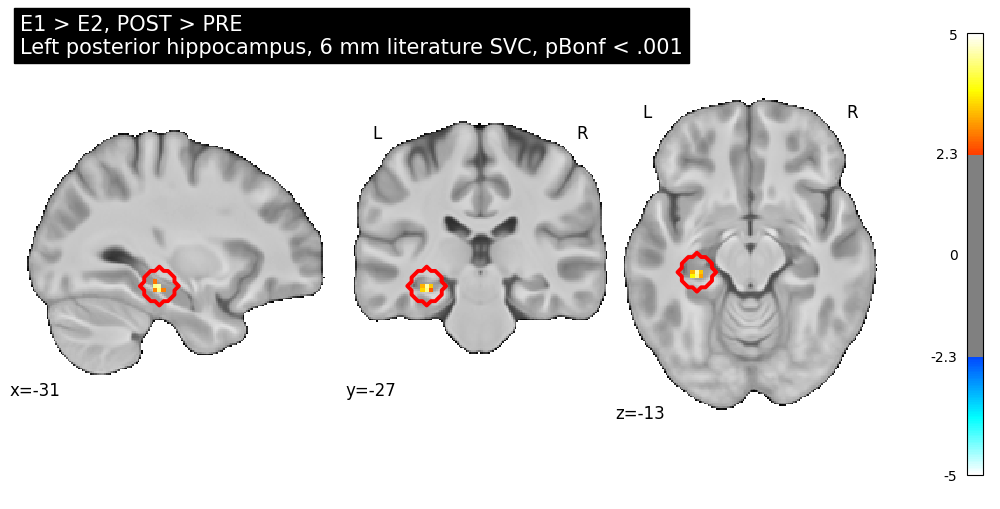


Saved report figure:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/figures/final_episode_time_result_clean/pre_post_episode_e1_e2_e3_control_glm_REPORT_E1_gt_E2_literature_SVC_clean.png
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/figures/final_episode_time_result_clean/pre_post_episode_e1_e2_e3_control_glm_REPORT_E1_gt_E2_literature_SVC_clean.pdf


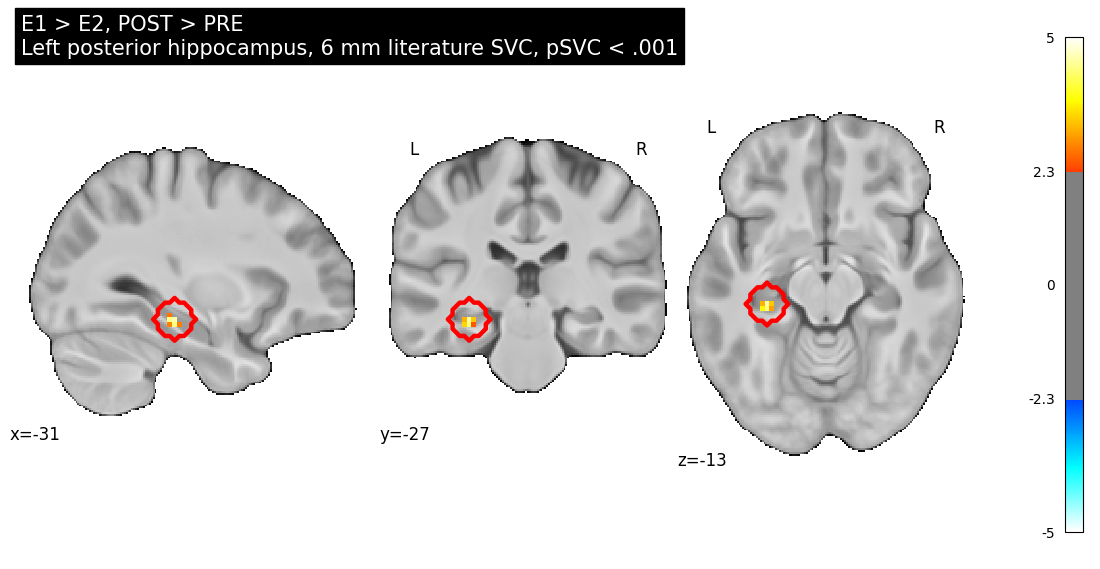


Saved slide figure:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/figures/final_episode_time_result_clean/pre_post_episode_e1_e2_e3_control_glm_SLIDE_E1_gt_E2_literature_SVC_clean.png

Clean literature-sphere table:


,Contrast,Literature sphere,Sphere center,Peak in sphere,z,pBonf sphere,qFDR sphere,Interpretation
0,E1 > E2,Viard posterior HPC,"(-30, -26, -12)","(-31, -27, -13)",4.55,< .001,< .001,Main effect
1,E1 > E2,Montagrin posterior HPC,"(-30, -31, -14)","(-31, -27, -13)",4.55,< .001,< .001,Main effect
2,E1 > E3,Viard posterior HPC,"(-30, -26, -12)","(-31, -27, -13)",3.51,.013,.013,Supportive effect
3,E1 > E3,Montagrin posterior HPC,"(-30, -31, -14)","(-31, -27, -13)",3.51,.013,.013,Supportive effect
4,E1 > new,Viard posterior HPC,"(-30, -26, -12)","(-31, -30, -13)",3.21,.037,.019,Supportive effect
5,E1 > new,Montagrin posterior HPC,"(-30, -31, -14)","(-31, -30, -13)",3.21,.037,.019,Supportive effect


Saved table CSV:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/final_episode_time_result_clean/pre_post_episode_e1_e2_e3_control_glm_FINAL_literature_sphere_result_table.csv


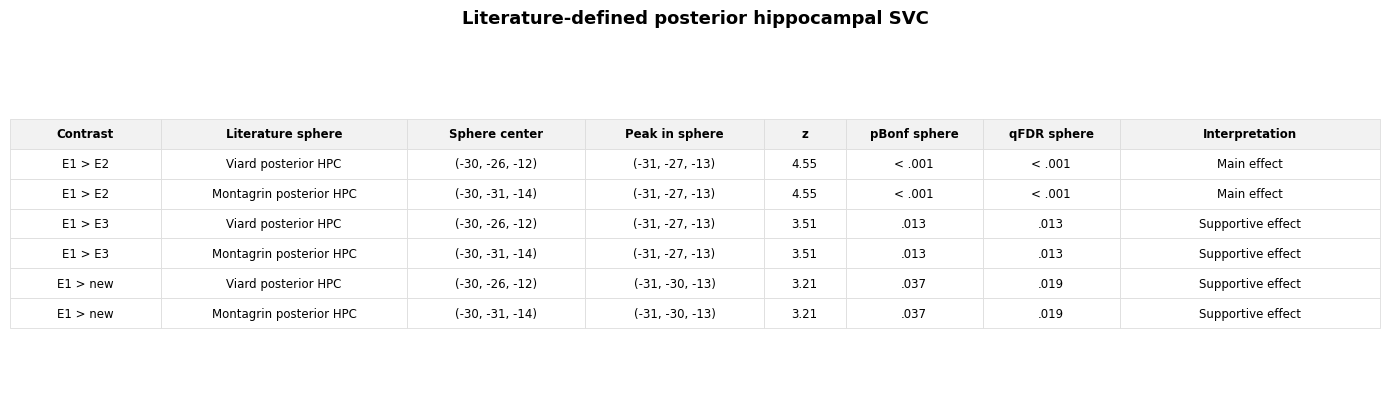

Saved table PNG:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/figures/final_episode_time_result_clean/pre_post_episode_e1_e2_e3_control_glm_FINAL_literature_sphere_result_table.png

Saved caption:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/final_episode_time_result_clean/pre_post_episode_e1_e2_e3_control_glm_FINAL_literature_SVC_caption.txt

Recommended outputs:
Report figure: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/figures/final_episode_time_result_clean/pre_post_episode_e1_e2_e3_control_glm_REPORT_E1_gt_E2_literature_SVC_clean.png
Slide figure: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/figures/final_episode_time_result_clean/pre_post_episode_e1_e2_e3_control_gl

In [26]:
# ============================================================
# FINAL clean report/slide figure + table
# E1 > E2, POST > PRE
# Literature-defined 6 mm SVC, with clean visual red highlight
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import nibabel as nib
from nilearn import plotting
from nilearn.image import load_img, new_img_like, resample_to_img, math_img
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests
from IPython.display import display

# ------------------------------------------------------------
# Output folders
# ------------------------------------------------------------

final_fig_dir = dirs["figures"] / "final_episode_time_result_clean"
final_table_dir = dirs["tables"] / "final_episode_time_result_clean"

final_fig_dir.mkdir(parents=True, exist_ok=True)
final_table_dir.mkdir(parents=True, exist_ok=True)

print("Saving figures to:", final_fig_dir)
print("Saving tables to:", final_table_dir)

# ------------------------------------------------------------
# Main result settings
# ------------------------------------------------------------

MAIN_CONTRAST = "e1_gt_e2_post_gt_pre"
MAIN_CONTRAST_LABEL = "E1 > E2, POST > PRE"

# Observed peak from your analysis
OBSERVED_PEAK = (-31.0, -27.0, -13.0)

# Primary literature-defined SVC sphere
# Viard et al. left posterior hippocampal coordinate
SVC_SPHERE_LABEL = "Viard left posterior hippocampus"
SVC_SPHERE_CENTER = (-30.0, -26.0, -12.0)
SVC_SPHERE_RADIUS_MM = 6.0

# Visual-only circle around the activation.
# This is NOT used for statistics.
VISUAL_RING_RADIUS_MM = 10.0

DISPLAY_THRESHOLD_Z = 2.33
VMAX = 5.0

# ------------------------------------------------------------
# Load main z-map
# ------------------------------------------------------------

main_z_map_path = Path(
    second_level_table.loc[
        second_level_table["contrast"] == MAIN_CONTRAST,
        "z_map_path",
    ].iloc[0]
)

main_z_img = load_img(str(main_z_map_path))

print("\nMain z-map:")
print(main_z_map_path)

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def make_sphere_mask_img(reference_img, center_mni, radius_mm):
    """Create a binary MNI sphere mask on the grid of reference_img."""

    ref_img = load_img(reference_img) if isinstance(reference_img, (str, Path)) else reference_img

    shape = ref_img.shape[:3]
    affine = ref_img.affine

    ijk = np.array(
        np.meshgrid(
            np.arange(shape[0]),
            np.arange(shape[1]),
            np.arange(shape[2]),
            indexing="ij",
        )
    ).reshape(3, -1).T

    xyz = nib.affines.apply_affine(affine, ijk)
    center = np.array(center_mni, dtype=float)

    distances = np.linalg.norm(xyz - center, axis=1)
    sphere_data = (distances <= radius_mm).reshape(shape).astype(np.uint8)

    return new_img_like(ref_img, sphere_data)


def run_sphere_svc(z_img, sphere_img, direction="positive"):
    """Voxelwise Bonferroni/FDR SVC inside a fixed sphere."""

    sphere_resampled = resample_to_img(
        sphere_img,
        z_img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )

    z_data = z_img.get_fdata()
    sphere_data = sphere_resampled.get_fdata() > 0

    n_voxels = int(sphere_data.sum())
    assert n_voxels > 0, "Sphere mask has zero voxels."

    z_inside = z_data[sphere_data]

    if direction == "positive":
        peak_index = int(np.nanargmax(z_inside))
        peak_z = float(z_inside[peak_index])
        p_values = norm.sf(z_inside)
        peak_p_unc = float(norm.sf(peak_z))
    elif direction == "negative":
        peak_index = int(np.nanargmin(z_inside))
        peak_z = float(z_inside[peak_index])
        p_values = norm.sf(-z_inside)
        peak_p_unc = float(norm.sf(-peak_z))
    else:
        raise ValueError("direction must be 'positive' or 'negative'.")

    _, q_values, _, _ = multipletests(
        p_values,
        alpha=0.05,
        method="fdr_bh",
    )

    peak_p_bonf = float(min(peak_p_unc * n_voxels, 1.0))
    peak_q_fdr = float(q_values[peak_index])

    sphere_indices = np.array(np.where(sphere_data)).T
    peak_ijk = sphere_indices[peak_index]
    peak_mni = nib.affines.apply_affine(z_img.affine, peak_ijk)

    return {
        "n_voxels_in_sphere": n_voxels,
        "peak_x": float(peak_mni[0]),
        "peak_y": float(peak_mni[1]),
        "peak_z_coord": float(peak_mni[2]),
        "peak_z_stat": peak_z,
        "peak_p_uncorrected": peak_p_unc,
        "peak_p_bonferroni_within_sphere": peak_p_bonf,
        "peak_q_fdr_within_sphere": peak_q_fdr,
        "n_voxels_p_unc_lt_0_001": int(np.sum(p_values < 0.001)),
        "n_voxels_bonf_p_lt_0_05": int(np.sum((p_values * n_voxels) < 0.05)),
        "n_voxels_fdr_q_lt_0_05": int(np.sum(q_values < 0.05)),
    }


def fmt_p(x):
    x = float(x)
    if x < 0.001:
        return "< .001"
    return f"{x:.3f}".replace("0.", ".")


def fmt_coord(x, y, z):
    return f"({x:.0f}, {y:.0f}, {z:.0f})"


def save_clean_table_png(
    df,
    out_path,
    title=None,
    fontsize=9,
    header_fontsize=9,
    scale_y=1.6,
    col_widths=None,
    figsize=None,
):
    """Save a clean matplotlib table as PNG."""

    n_rows, n_cols = df.shape

    if figsize is None:
        figsize = (max(10, n_cols * 1.5), max(2.8, n_rows * 0.55 + 1.2))

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("white")
    ax.axis("off")

    if col_widths is None:
        col_widths = [1 / n_cols] * n_cols

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        colLoc="center",
        loc="center",
        colWidths=col_widths,
    )

    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    table.scale(1, scale_y)

    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("#DDDDDD")
        cell.set_linewidth(0.6)

        if row == 0:
            cell.set_text_props(weight="bold", fontsize=header_fontsize)
            cell.set_facecolor("#F2F2F2")
        else:
            cell.set_facecolor("white")

    if title:
        ax.set_title(title, fontsize=13, weight="bold", pad=18)

    plt.tight_layout()
    fig.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

    print("Saved table PNG:")
    print(out_path)

# ------------------------------------------------------------
# Build true 6 mm SVC sphere and compute SVC
# ------------------------------------------------------------

svc_sphere_img = make_sphere_mask_img(
    reference_img=main_z_img,
    center_mni=SVC_SPHERE_CENTER,
    radius_mm=SVC_SPHERE_RADIUS_MM,
)

svc_sphere_resampled = resample_to_img(
    svc_sphere_img,
    main_z_img,
    interpolation="nearest",
    force_resample=True,
    copy_header=True,
)

svc_sphere_path = (
    final_table_dir
    / f"{ANALYSIS_NAME}_Viard_left_posterior_HPC_6mm_SVC_sphere_mask.nii.gz"
)

svc_sphere_resampled.to_filename(str(svc_sphere_path))

svc_result = run_sphere_svc(
    z_img=main_z_img,
    sphere_img=svc_sphere_resampled,
    direction="positive",
)

p_bonf_label = fmt_p(svc_result["peak_p_bonferroni_within_sphere"])
q_fdr_label = fmt_p(svc_result["peak_q_fdr_within_sphere"])

print("\nSVC result in true 6 mm literature sphere:")
for k, v in svc_result.items():
    print(f"{k}: {v}")

# ------------------------------------------------------------
# Mask activation to true 6 mm SVC sphere only
# ------------------------------------------------------------

masked_z_img = math_img(
    "zmap * (sphere > 0)",
    zmap=main_z_img,
    sphere=svc_sphere_resampled,
)

masked_z_path = (
    final_table_dir
    / f"{ANALYSIS_NAME}_E1_gt_E2_zmap_masked_to_Viard_6mm_SVC_sphere.nii.gz"
)

masked_z_img.to_filename(str(masked_z_path))

print("\nSaved masked z-map:")
print(masked_z_path)

# ------------------------------------------------------------
# Build visual-only larger red ring around observed peak
# ------------------------------------------------------------

visual_ring_img = make_sphere_mask_img(
    reference_img=main_z_img,
    center_mni=OBSERVED_PEAK,
    radius_mm=VISUAL_RING_RADIUS_MM,
)

visual_ring_resampled = resample_to_img(
    visual_ring_img,
    main_z_img,
    interpolation="nearest",
    force_resample=True,
    copy_header=True,
)

visual_ring_path = (
    final_table_dir
    / f"{ANALYSIS_NAME}_visual_only_10mm_peak_ring_mask.nii.gz"
)

visual_ring_resampled.to_filename(str(visual_ring_path))

print("\nSaved visual-only ring mask:")
print(visual_ring_path)

# ============================================================
# FIGURE 1: Report version
# ============================================================

report_fig_path_png = (
    final_fig_dir
    / f"{ANALYSIS_NAME}_REPORT_E1_gt_E2_literature_SVC_clean.png"
)

report_fig_path_pdf = (
    final_fig_dir
    / f"{ANALYSIS_NAME}_REPORT_E1_gt_E2_literature_SVC_clean.pdf"
)

fig = plt.figure(figsize=(9.8, 4.9), facecolor="white")

stat_display = plotting.plot_stat_map(
    masked_z_img,
    bg_img=mean_t1w_img if globals().get("USE_MEAN_T1W_BACKGROUND", True) else None,
    threshold=DISPLAY_THRESHOLD_Z,
    vmax=VMAX,
    cmap="cold_hot",
    symmetric_cbar=True,
    display_mode="ortho",
    cut_coords=OBSERVED_PEAK,
    black_bg=False,
    colorbar=True,
    annotate=True,
    draw_cross=False,
    dim=-0.2,
    figure=fig,
    title=(
        "E1 > E2, POST > PRE\n"
        f"Left posterior hippocampus, 6 mm literature SVC, pBonf {p_bonf_label}"
    ),
)

# Visual-only larger red contour around the activation.
# Statistics are still computed in the true 6 mm Viard sphere.
stat_display.add_contours(
    visual_ring_resampled,
    levels=[0.5],
    colors=["red"],
    linewidths=2.8,
)

fig.savefig(report_fig_path_png, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(report_fig_path_pdf, bbox_inches="tight", facecolor="white")
plt.show()

print("\nSaved report figure:")
print(report_fig_path_png)
print(report_fig_path_pdf)

# ============================================================
# FIGURE 2: Slide version
# ============================================================

slide_fig_path_png = (
    final_fig_dir
    / f"{ANALYSIS_NAME}_SLIDE_E1_gt_E2_literature_SVC_clean.png"
)

fig = plt.figure(figsize=(10.8, 5.5), facecolor="white")

stat_display = plotting.plot_stat_map(
    masked_z_img,
    bg_img=mean_t1w_img if globals().get("USE_MEAN_T1W_BACKGROUND", True) else None,
    threshold=DISPLAY_THRESHOLD_Z,
    vmax=VMAX,
    cmap="cold_hot",
    symmetric_cbar=True,
    display_mode="ortho",
    cut_coords=OBSERVED_PEAK,
    black_bg=False,
    colorbar=True,
    annotate=True,
    draw_cross=False,
    dim=-0.2,
    figure=fig,
    title=(
        "E1 > E2, POST > PRE\n"
        f"Left posterior hippocampus, 6 mm literature SVC, pSVC {p_bonf_label}"
    ),
)

stat_display.add_contours(
    visual_ring_resampled,
    levels=[0.5],
    colors=["red"],
    linewidths=3.2,
)

fig.savefig(slide_fig_path_png, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print("\nSaved slide figure:")
print(slide_fig_path_png)

# ============================================================
# Clean support table
# ============================================================

# Load literature SVC all-contrast table if needed
if "literature_svc_all_table" not in globals():
    literature_svc_all_path = (
        dirs["tables"]
        / "svc"
        / "literature_6mm_spheres_all_contrasts"
        / f"{ANALYSIS_NAME}_literature_defined_6mm_sphere_svc_ALL_contrasts.csv"
    )
    literature_svc_all_table = pd.read_csv(literature_svc_all_path)

posterior_lit_rois = [
    "Viard_left_posterior_HPC_autobiographical_period",
    "Montagrin_current_gt_remote_left_posterior_HPC",
]

support_contrasts = [
    "e1_gt_e2_post_gt_pre",
    "e1_gt_e3_post_gt_pre",
    "e1_gt_new_post_gt_pre",
]

support_df = literature_svc_all_table[
    literature_svc_all_table["literature_roi"].isin(posterior_lit_rois)
    & literature_svc_all_table["contrast"].isin(support_contrasts)
].copy()

contrast_order = {
    "e1_gt_e2_post_gt_pre": 0,
    "e1_gt_e3_post_gt_pre": 1,
    "e1_gt_new_post_gt_pre": 2,
}

roi_order = {
    "Viard_left_posterior_HPC_autobiographical_period": 0,
    "Montagrin_current_gt_remote_left_posterior_HPC": 1,
}

support_df["contrast_order"] = support_df["contrast"].map(contrast_order)
support_df["roi_order"] = support_df["literature_roi"].map(roi_order)

support_df = support_df.sort_values(
    ["contrast_order", "roi_order"]
).reset_index(drop=True)

def short_sphere_name(roi):
    if roi == "Viard_left_posterior_HPC_autobiographical_period":
        return "Viard posterior HPC"
    if roi == "Montagrin_current_gt_remote_left_posterior_HPC":
        return "Montagrin posterior HPC"
    return roi

minimal_rows = []

for _, row in support_df.iterrows():
    minimal_rows.append({
        "Contrast": row["contrast_label"],
        "Literature sphere": short_sphere_name(row["literature_roi"]),
        "Sphere center": fmt_coord(
            row["sphere_center_x"],
            row["sphere_center_y"],
            row["sphere_center_z"],
        ),
        "Peak in sphere": fmt_coord(
            row["peak_x"],
            row["peak_y"],
            row["peak_z_coord"],
        ),
        "z": f"{row['peak_z_stat']:.2f}",
        "pBonf sphere": fmt_p(row["peak_p_bonferroni_within_sphere"]),
        "qFDR sphere": fmt_p(row["peak_q_fdr_within_sphere"]),
        "Interpretation": (
            "Main effect"
            if row["contrast"] == "e1_gt_e2_post_gt_pre"
            else "Supportive effect"
        ),
    })

minimal_sphere_table = pd.DataFrame(minimal_rows)

minimal_table_csv = (
    final_table_dir
    / f"{ANALYSIS_NAME}_FINAL_literature_sphere_result_table.csv"
)

minimal_sphere_table.to_csv(minimal_table_csv, index=False)

print("\nClean literature-sphere table:")
display(minimal_sphere_table)

print("Saved table CSV:")
print(minimal_table_csv)

minimal_table_png = (
    final_fig_dir
    / f"{ANALYSIS_NAME}_FINAL_literature_sphere_result_table.png"
)

save_clean_table_png(
    minimal_sphere_table,
    minimal_table_png,
    title="Literature-defined posterior hippocampal SVC",
    fontsize=8.5,
    header_fontsize=8.5,
    scale_y=1.65,
    col_widths=[0.11, 0.18, 0.13, 0.13, 0.06, 0.10, 0.10, 0.19],
    figsize=(14, 4.2),
)

# ============================================================
# Caption
# ============================================================

caption_text = f"""
Figure caption:
Group-level E1 > E2, POST > PRE contrast. Activation is displayed only within the 6 mm literature-defined left posterior hippocampal SVC sphere centered on Viard et al. (-30, -26, -12). The red contour is a visual guide around the observed peak. The observed peak was located at (-31, -27, -13), z = {svc_result['peak_z_stat']:.2f}, and survived voxelwise correction within the literature-defined sphere, pBonf {p_bonf_label}, qFDR {q_fdr_label}.

Interpretation:
The result supports an E1-selective posterior hippocampal effect after Island encoding. Supporting contrasts E1 > E3 and E1 > new also survived within posterior literature-defined hippocampal spheres, suggesting that the first encoded episode acquired a distinctive hippocampal representation.
""".strip()

caption_path = (
    final_table_dir
    / f"{ANALYSIS_NAME}_FINAL_literature_SVC_caption.txt"
)

caption_path.write_text(caption_text)

print("\nSaved caption:")
print(caption_path)

print("\nRecommended outputs:")
print("Report figure:", report_fig_path_png)
print("Slide figure:", slide_fig_path_png)
print("Table PNG:", minimal_table_png)
print("Caption:", caption_path)

Saving polished figures to: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/figures/final_episode_time_result_polished
Saving polished tables to: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/final_episode_time_result_polished


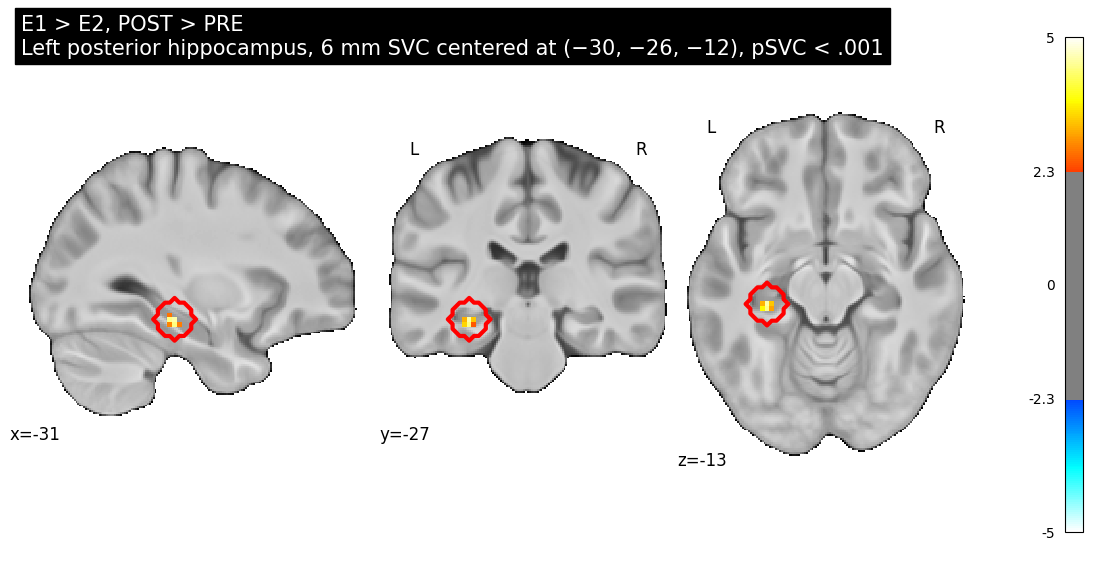

Saved figure WITH red circle:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/figures/final_episode_time_result_polished/pre_post_episode_e1_e2_e3_control_glm_FINAL_E1_gt_E2_with_red_circle.png
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/figures/final_episode_time_result_polished/pre_post_episode_e1_e2_e3_control_glm_FINAL_E1_gt_E2_with_red_circle.pdf


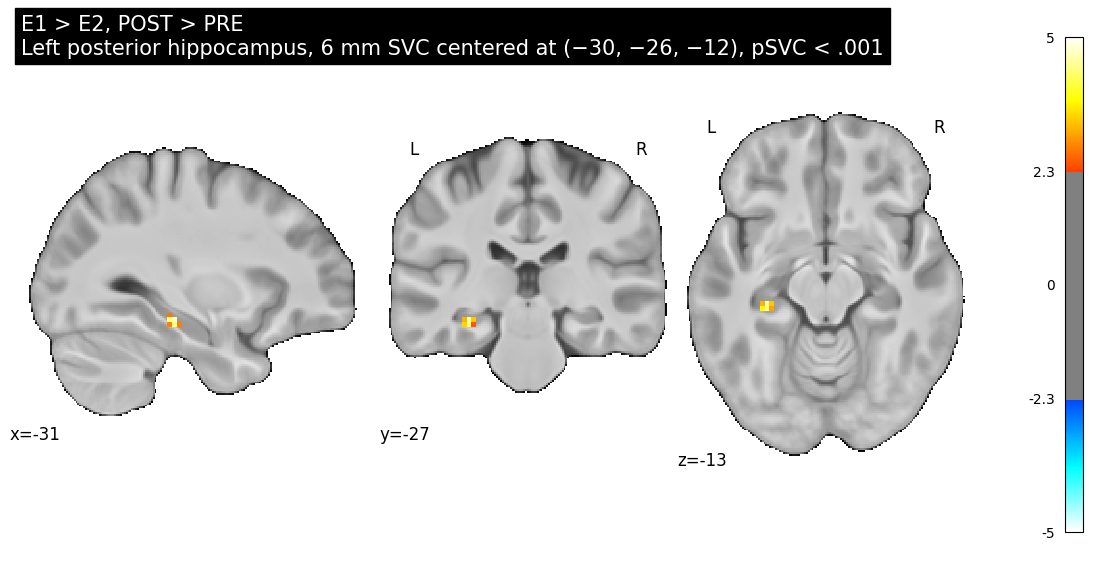

Saved figure WITHOUT red circle:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/figures/final_episode_time_result_polished/pre_post_episode_e1_e2_e3_control_glm_FINAL_E1_gt_E2_without_red_circle.png
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/figures/final_episode_time_result_polished/pre_post_episode_e1_e2_e3_control_glm_FINAL_E1_gt_E2_without_red_circle.pdf

Merged literature table:


,Contrast,Literature spheres,Sphere centers,Peak in spheres,z,pBonf sphere,qFDR sphere,Interpretation
0,E1 > E2,Viard + Montagrin posterior HPC,"Viard (-30, -26, -12); Montagrin (-30, -31, -14)","(-31, -27, -13)",4.55,< .001,< .001,Main effect
1,E1 > E3,Viard + Montagrin posterior HPC,"Viard (-30, -26, -12); Montagrin (-30, -31, -14)","(-31, -27, -13)",3.51,.013,.013,Supportive same-region effect
2,E1 > new,Viard + Montagrin posterior HPC,"Viard (-30, -26, -12); Montagrin (-30, -31, -14)","(-31, -30, -13)",3.21,.037,.019,Supportive Island-context effect


Saved merged table CSV:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/tables/final_episode_time_result_polished/pre_post_episode_e1_e2_e3_control_glm_FINAL_merged_literature_sphere_table.csv


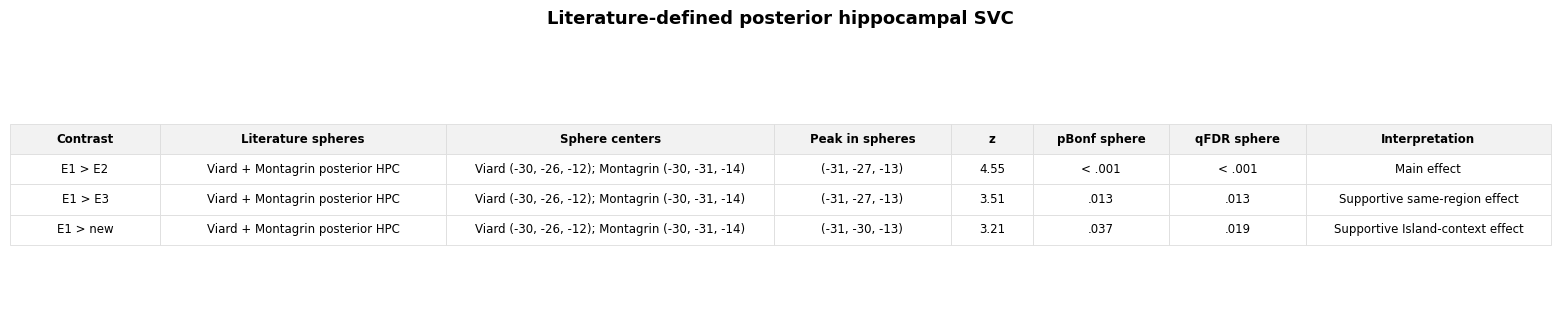

Saved table PNG:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/figures/final_episode_time_result_polished/pre_post_episode_e1_e2_e3_control_glm_FINAL_merged_literature_sphere_table.png


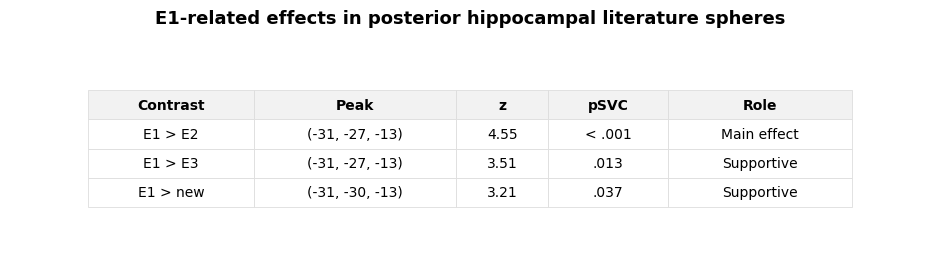

Saved table PNG:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/figures/final_episode_time_result_polished/pre_post_episode_e1_e2_e3_control_glm_FINAL_compact_slide_table.png

Recommended slide outputs:
1. Brain with red circle: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/figures/final_episode_time_result_polished/pre_post_episode_e1_e2_e3_control_glm_FINAL_E1_gt_E2_with_red_circle.png
2. Brain without red circle: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/figures/final_episode_time_result_polished/pre_post_episode_e1_e2_e3_control_glm_FINAL_E1_gt_E2_without_red_circle.png
3. Merged table: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_episode_e1_e2_e3_control_glm/figures/final_episode_time_result_polished/pr

In [28]:
# ============================================================
# FINAL polished outputs:
# 1) Figure with red visual circle
# 2) Figure without red visual circle
# 3) Merged Viard + Montagrin summary table
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from nilearn import plotting
from IPython.display import display

# ------------------------------------------------------------
# Output folders
# ------------------------------------------------------------

final_polished_fig_dir = dirs["figures"] / "final_episode_time_result_polished"
final_polished_table_dir = dirs["tables"] / "final_episode_time_result_polished"

final_polished_fig_dir.mkdir(parents=True, exist_ok=True)
final_polished_table_dir.mkdir(parents=True, exist_ok=True)

print("Saving polished figures to:", final_polished_fig_dir)
print("Saving polished tables to:", final_polished_table_dir)

# ------------------------------------------------------------
# Required objects from previous cell
# ------------------------------------------------------------
# Expected:
# masked_z_img
# visual_ring_resampled
# mean_t1w_img
# OBSERVED_PEAK
# ANALYSIS_NAME
# literature_svc_all_table
# fmt_p
# save_clean_table_png

assert "masked_z_img" in globals(), "masked_z_img not found. Run the previous SVC plotting cell first."
assert "visual_ring_resampled" in globals(), "visual_ring_resampled not found. Run the previous SVC plotting cell first."
assert "literature_svc_all_table" in globals(), "literature_svc_all_table not found."
assert "OBSERVED_PEAK" in globals(), "OBSERVED_PEAK not found."

# ------------------------------------------------------------
# p-value labels
# ------------------------------------------------------------

# Get Viard E1 > E2 row as primary p-value source
viard_main = literature_svc_all_table.query(
    "literature_roi == 'Viard_left_posterior_HPC_autobiographical_period' "
    "and contrast == 'e1_gt_e2_post_gt_pre'"
).iloc[0]

p_svc_label = fmt_p(viard_main["peak_p_bonferroni_within_sphere"])
q_svc_label = fmt_p(viard_main["peak_q_fdr_within_sphere"])

TITLE_TEXT = (
    "E1 > E2, POST > PRE\n"
    f"Left posterior hippocampus, 6 mm SVC centered at (−30, −26, −12), pSVC {p_svc_label}"
)

# ============================================================
# Figure A: With red circle / visual guide
# ============================================================

fig_with_circle_png = (
    final_polished_fig_dir
    / f"{ANALYSIS_NAME}_FINAL_E1_gt_E2_with_red_circle.png"
)

fig_with_circle_pdf = (
    final_polished_fig_dir
    / f"{ANALYSIS_NAME}_FINAL_E1_gt_E2_with_red_circle.pdf"
)

fig = plt.figure(figsize=(10.8, 5.5), facecolor="white")

stat_display = plotting.plot_stat_map(
    masked_z_img,
    bg_img=mean_t1w_img if globals().get("USE_MEAN_T1W_BACKGROUND", True) else None,
    threshold=2.33,
    vmax=5.0,
    cmap="cold_hot",
    symmetric_cbar=True,
    display_mode="ortho",
    cut_coords=OBSERVED_PEAK,
    black_bg=False,
    colorbar=True,
    annotate=True,
    draw_cross=False,
    dim=-0.2,
    figure=fig,
    title=TITLE_TEXT,
)

# Red contour = visual guide only, not the statistical SVC mask
stat_display.add_contours(
    visual_ring_resampled,
    levels=[0.5],
    colors=["red"],
    linewidths=3.0,
)

fig.savefig(fig_with_circle_png, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(fig_with_circle_pdf, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved figure WITH red circle:")
print(fig_with_circle_png)
print(fig_with_circle_pdf)

# ============================================================
# Figure B: Without red circle
# ============================================================

fig_no_circle_png = (
    final_polished_fig_dir
    / f"{ANALYSIS_NAME}_FINAL_E1_gt_E2_without_red_circle.png"
)

fig_no_circle_pdf = (
    final_polished_fig_dir
    / f"{ANALYSIS_NAME}_FINAL_E1_gt_E2_without_red_circle.pdf"
)

fig = plt.figure(figsize=(10.8, 5.5), facecolor="white")

stat_display = plotting.plot_stat_map(
    masked_z_img,
    bg_img=mean_t1w_img if globals().get("USE_MEAN_T1W_BACKGROUND", True) else None,
    threshold=2.33,
    vmax=5.0,
    cmap="cold_hot",
    symmetric_cbar=True,
    display_mode="ortho",
    cut_coords=OBSERVED_PEAK,
    black_bg=False,
    colorbar=True,
    annotate=True,
    draw_cross=False,
    dim=-0.2,
    figure=fig,
    title=TITLE_TEXT,
)

fig.savefig(fig_no_circle_png, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(fig_no_circle_pdf, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved figure WITHOUT red circle:")
print(fig_no_circle_png)
print(fig_no_circle_pdf)

# ============================================================
# Merged Viard + Montagrin table
# ============================================================

posterior_lit_rois = [
    "Viard_left_posterior_HPC_autobiographical_period",
    "Montagrin_current_gt_remote_left_posterior_HPC",
]

support_contrasts = [
    "e1_gt_e2_post_gt_pre",
    "e1_gt_e3_post_gt_pre",
    "e1_gt_new_post_gt_pre",
]

support_df = literature_svc_all_table[
    literature_svc_all_table["literature_roi"].isin(posterior_lit_rois)
    & literature_svc_all_table["contrast"].isin(support_contrasts)
].copy()

contrast_order = {
    "e1_gt_e2_post_gt_pre": 0,
    "e1_gt_e3_post_gt_pre": 1,
    "e1_gt_new_post_gt_pre": 2,
}

support_df["contrast_order"] = support_df["contrast"].map(contrast_order)
support_df = support_df.sort_values(["contrast_order", "literature_roi"]).reset_index(drop=True)

# Merge rows by contrast because Viard and Montagrin give the same peak/statistics
merged_rows = []

for contrast, group in support_df.groupby("contrast", sort=False):

    group = group.copy()

    # Use first row because peak/stat values are identical in your output
    row = group.iloc[0]

    literature_spheres = "Viard + Montagrin posterior HPC"
    sphere_centers = "Viard (-30, -26, -12); Montagrin (-30, -31, -14)"

    if contrast == "e1_gt_e2_post_gt_pre":
        interpretation = "Main effect"
    elif contrast == "e1_gt_e3_post_gt_pre":
        interpretation = "Supportive same-region effect"
    elif contrast == "e1_gt_new_post_gt_pre":
        interpretation = "Supportive Island-context effect"
    else:
        interpretation = "Supportive effect"

    merged_rows.append({
        "Contrast": row["contrast_label"],
        "Literature spheres": literature_spheres,
        "Sphere centers": sphere_centers,
        "Peak in spheres": f"({row['peak_x']:.0f}, {row['peak_y']:.0f}, {row['peak_z_coord']:.0f})",
        "z": f"{row['peak_z_stat']:.2f}",
        "pBonf sphere": fmt_p(row["peak_p_bonferroni_within_sphere"]),
        "qFDR sphere": fmt_p(row["peak_q_fdr_within_sphere"]),
        "Interpretation": interpretation,
    })

merged_literature_table = pd.DataFrame(merged_rows)

merged_table_csv = (
    final_polished_table_dir
    / f"{ANALYSIS_NAME}_FINAL_merged_literature_sphere_table.csv"
)

merged_literature_table.to_csv(merged_table_csv, index=False)

print("\nMerged literature table:")
display(merged_literature_table)

print("Saved merged table CSV:")
print(merged_table_csv)

merged_table_png = (
    final_polished_fig_dir
    / f"{ANALYSIS_NAME}_FINAL_merged_literature_sphere_table.png"
)

save_clean_table_png(
    merged_literature_table,
    merged_table_png,
    title="Literature-defined posterior hippocampal SVC",
    fontsize=8.5,
    header_fontsize=8.5,
    scale_y=1.75,
    col_widths=[0.11, 0.21, 0.24, 0.13, 0.06, 0.10, 0.10, 0.18],
    figsize=(15.5, 3.4),
)

# ============================================================
# Compact slide table
# ============================================================

compact_rows = [
    {
        "Contrast": "E1 > E2",
        "Peak": "(-31, -27, -13)",
        "z": "4.55",
        "pSVC": "< .001",
        "Role": "Main effect",
    },
    {
        "Contrast": "E1 > E3",
        "Peak": "(-31, -27, -13)",
        "z": "3.51",
        "pSVC": ".013",
        "Role": "Supportive",
    },
    {
        "Contrast": "E1 > new",
        "Peak": "(-31, -30, -13)",
        "z": "3.21",
        "pSVC": ".037",
        "Role": "Supportive",
    },
]

compact_slide_table = pd.DataFrame(compact_rows)

compact_slide_table_png = (
    final_polished_fig_dir
    / f"{ANALYSIS_NAME}_FINAL_compact_slide_table.png"
)

save_clean_table_png(
    compact_slide_table,
    compact_slide_table_png,
    title="E1-related effects in posterior hippocampal literature spheres",
    fontsize=10,
    header_fontsize=10,
    scale_y=1.8,
    col_widths=[0.18, 0.22, 0.10, 0.13, 0.20],
    figsize=(9.5, 2.7),
)

print("\nRecommended slide outputs:")
print("1. Brain with red circle:", fig_with_circle_png)
print("2. Brain without red circle:", fig_no_circle_png)
print("3. Merged table:", merged_table_png)
print("4. Compact slide table:", compact_slide_table_png)